<a href="https://colab.research.google.com/github/ashivashankars/CMPE257/blob/main/Agentic_Ninjas_CMPE257_Final_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICLR 2025 — End-to-End Paper Acceptance Predictor & Improvement Suggester

**Single-notebook version** — runs all three phases top-to-bottom. Every expensive step is Drive-cached so re-runs are instant.

| Phase | What | Output |
|-------|------|--------|
| **1 — Data** | OpenReview scraping + Semantic Scholar | `raw/*.json` |
| **2 — NLP** | LDA topics, NER, POS, readability, rhetorical roles | `features/labeled_features.parquet` |
| **3 — KG** | Rule-based corpus KG + Gemini FCoT 3-iteration KG | `kg/*.json`, `figures/*_kg.png` |
| **4 — Trends** | Topic acceptance rates, trend score feature | `analysis/trend_scores.json` |
| **5 — Predictor** | XGBoost + Gemini Equitable Judge ensemble | `models/xgb.joblib` |
| **6 — Suggest** | KG-grounded improvement reports (Objective 2) | `predictions/*.json` |

**Objectives**
- **Obj 1** — Calibrated P(acceptance) via XGBoost + Gemini ensemble
- **Obj 2** — Grounded improvement suggestions tied to Gold Standard gaps

> **Hot-start tip:** If Drive already has cached artifacts, jump straight to any section — each cell checks Drive before recomputing.

In [1]:
!pip install spacy textstat pdfplumber requests pandas \
             scikit-learn matplotlib seaborn numpy tqdm \
             pyarrow joblib xgboost shap arxiv \
             google-generativeai -q
!python -m spacy download en_core_web_sm -q
print('All dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 108.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependen

In [2]:
import io, json, math, re, time, warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
warnings.filterwarnings('ignore')

import arxiv as _arxiv
import google.generativeai as genai
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pdfplumber
import requests
import seaborn as sns
import shap
import spacy
import textstat
import xgboost
from xgboost import XGBClassifier

from IPython.display import display, Markdown, HTML, Image
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    classification_report, roc_auc_score, average_precision_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_validate
from tqdm.auto import tqdm

print('All imports OK.')

All imports OK.


In [3]:
# ── Mount Shared Google Drive ─────────────────────────────────────
from google.colab import drive, userdata
import joblib
drive.mount('/content/drive')

# ── Shared folder — first runner creates; everyone else loads ─────
DRIVE_BASE     = Path('/content/drive/MyDrive/CMPE257_ICLR2025')
DRIVE_RAW      = DRIVE_BASE / 'raw'
DRIVE_MODELS   = DRIVE_BASE / 'models'
DRIVE_VECTORS  = DRIVE_BASE / 'vectors'
DRIVE_FEATURES = DRIVE_BASE / 'features'
DRIVE_ANALYSIS = DRIVE_BASE / 'analysis'
DRIVE_KG       = DRIVE_BASE / 'kg'
DRIVE_FIGURES  = DRIVE_BASE / 'figures'

for _d in [DRIVE_RAW, DRIVE_MODELS, DRIVE_VECTORS,
           DRIVE_FEATURES, DRIVE_ANALYSIS, DRIVE_KG, DRIVE_FIGURES]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Typed helpers (save + load for each artifact type) ────────────
def _mb(p): return f'{Path(p).stat().st_size/1e6:.1f} MB'

def save_json(obj, path):
    with open(path, 'w') as f: json.dump(obj, f, indent=2, ensure_ascii=False)
    print(f'  [Drive] saved  {Path(path).name}  ({_mb(path)})')

def load_json(path):
    with open(path) as f: return json.load(f)

def save_parquet(df, path):
    df.to_parquet(path, index=False)
    print(f'  [Drive] saved  {Path(path).name}  ({_mb(path)})')

def load_parquet(path): return pd.read_parquet(path)

def save_npz(path, **arrays):
    p = str(path)
    np.savez_compressed(p if p.endswith('.npz') else p + '.npz', **arrays)
    print(f'  [Drive] saved  {Path(p).stem}.npz')

def load_npz(path):
    p = str(path)
    return np.load(p if p.endswith('.npz') else p + '.npz')

def save_model(obj, path):
    joblib.dump(obj, path)
    print(f'  [Drive] saved  {Path(path).name}  ({_mb(path)})')

def load_model(path): return joblib.load(path)

def save_fig(fig, name):
    fig.savefig(DRIVE_FIGURES / name, dpi=150, bbox_inches='tight')
    print(f'  [Drive] figure {name}')

def drive_has(path): return Path(path).exists()

print(f'Drive ready.  Shared base → {DRIVE_BASE}')

Mounted at /content/drive
Drive ready.  Shared base → /content/drive/MyDrive/CMPE257_ICLR2025


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# GLOBAL CONFIG — edit here only
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CONFERENCE      = 'ICLR 2025'
VENUE_ID        = 'ICLR.cc/2025/Conference'
OPENREVIEW_BASE = 'https://api2.openreview.net'
S2_SEARCH_URL   = 'https://api.semanticscholar.org/graph/v1/paper/search'
BATCH_SIZE      = 200
MAX_PAPERS      = 800
POLITE_SLEEP    = 0.4
REQUEST_TIMEOUT = 30
HEADERS         = {'User-Agent': 'ICLR2025-Pipeline/1.0 (academic)',
                   'Accept': 'application/json'}
N_TOPICS        = 10
N_TOP_WORDS     = 15
LDA_MAX_ITER    = 20
LDA_SEED        = 42
CV_MAX_FEATURES = 4000
CV_MIN_DF       = 3
CV_MAX_DF       = 0.92
PDF_SAMPLE_SIZE = 5

# Gemini
GEMINI_MODEL = 'gemini-2.5-flash'
GEMINI_TEMP  = 0.15
CALL_DELAY   = 2.0

# Hot research trends (for TREND node alignment)
HOT_TRENDS = [
    'LLM Agents', 'Tool-Augmented Reasoning', 'Self-Improving Systems',
    'RLHF / Alignment', 'Multi-Agent Systems', 'Autonomous Planning',
    'Retrieval-Augmented Generation', 'Embodied AI', 'Code Generation Agents',
    'Multimodal Reasoning', 'Chain-of-Thought', 'Instruction Tuning',
]

# Drive artifact paths
ACC_CACHE    = DRIVE_RAW      / 'iclr2025_accepted_papers.json'
REJ_CACHE    = DRIVE_RAW      / 'iclr2025_rejected_papers.json'
ARX_CACHE    = DRIVE_RAW      / 'arxiv_papers.json'
LDA_PATH     = DRIVE_MODELS   / 'lda_model.joblib'
CV_PATH      = DRIVE_MODELS   / 'count_vectorizer.joblib'
TFIDF_PATH   = DRIVE_MODELS   / 'tfidf_vectorizer.joblib'
ACC_NPZ      = DRIVE_VECTORS  / 'accepted_topic_dists'
REJ_NPZ      = DRIVE_VECTORS  / 'rejected_topic_dists'
NLP_JSON     = DRIVE_FEATURES / 'iclr2025_nlp_features.json'
LABELED_PQ   = DRIVE_FEATURES / 'iclr2025_labeled_features.parquet'
GOLD_JSON    = DRIVE_ANALYSIS / 'gold_standard_ranges.json'
CURATED_PQ   = DRIVE_FEATURES / 'iclr2025_curated_papers.parquet'
CORPUS_KG    = DRIVE_ANALYSIS / 'corpus_kg_summary.json'
TREND_SCORES = DRIVE_ANALYSIS / 'trend_scores.json'
TREND_JSON   = TREND_SCORES                              # alias used in predictor section
FCOT_CACHE   = DRIVE_KG      / 'fcot_results_cache.json'
XGB_PATH     = DRIVE_MODELS  / 'acceptance_predictor_xgb.joblib'
DRIVE_PREDICT = DRIVE_BASE   / 'predictions'
DRIVE_PREDICT.mkdir(parents=True, exist_ok=True)
PRED_CACHE   = DRIVE_PREDICT / 'arxiv_predictions_cache.json'
RUBRIC_CACHE = DRIVE_PREDICT / 'judge_rubric_cache.json'

# XGBoost feature set (trend_score added at runtime if available)
FEATURE_COLS = [
    'rshow', 'noun_to_verb_ratio', 'adjective_density',
    'dominant_topic_weight', 'topic_entropy',
    'coverage_score', 'abstract_sentence_count', 'abstract_word_count',
    'total_entities', 'unique_entities',
    'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog',
    'type_token_ratio', 'technical_term_ratio', 'avg_sentence_length',
    'n_authors', 'n_keywords', 'agentic_score',
]

# Hardcoded borderline paper for Objective 2 demo
THIRD_PAPER_ID = '2501.10910'

AGENTIC_KEYWORDS = [
    'agent', 'agentic', 'agency', 'autonomous', 'autonomy',
    'multi-agent', 'multiagent', 'planning', 'plan',
    'self-improvement', 'self-refine', 'self-reflection',
    'tool use', 'tool-use', 'tool call', 'function call', 'toolformer',
    'decision making', 'decision-making', 'goal-directed', 'goal conditioned',
    'task decomposition', 'workflow', 'orchestration',
    'reinforcement learning', 'reward', 'policy gradient',
    'rl agent', 'llm agent', 'language agent', 'reasoning agent',
    'actor-critic', 'actor critic',
    'retrieval augmented generation', 'rag',
    'environment', 'simulation', 'embodied',
]
STOP_EXTRA = {
    'paper', 'propose', 'present', 'show', 'demonstrate', 'work', 'study',
    'approach', 'method', 'use', 'result', 'experiment', 'model', 'task',
    'dataset', 'base', 'learn', 'train', 'test', 'performance', 'high',
    'new', 'large', 'small', 'good', 'better', 'best', 'different', 'state',
}
NER_DESCRIPTIONS = {
    'PERSON': 'People', 'ORG': 'Organisations', 'GPE': 'Countries/Cities',
    'PRODUCT': 'Products (models, datasets)', 'WORK_OF_ART': 'Titles',
    'EVENT': 'Named events', 'NORP': 'Groups/Nationalities',
    'LOC': 'Locations', 'MONEY': 'Monetary values',
    'CARDINAL': 'Numbers', 'PERCENT': 'Percentages',
}
CONTENT_POS = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}

print(f'Config ready — {CONFERENCE}')

Config ready — ICLR 2025


In [5]:
_re = re  # alias for Gemini helper functions

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

# ── Model fallback chain ──────────────────────────────────────────
# Try from newest to most widely available on free tier.
# 'limit: 0' usually means the key is from Cloud Console (not AI Studio)
# or the per-minute quota is exhausted — the fallback chain handles both.
# Models ordered: most capable → fastest → lightest
# All confirmed available on this API key.
GEMINI_FALLBACK_MODELS = [
    'gemini-2.5-flash',          # primary — best JSON + reasoning
    'gemini-2.0-flash',          # fallback 1
    'gemini-2.0-flash-lite',     # fallback 2 — lower quota cost
    'gemini-2.5-flash-lite',     # fallback 3
    'gemini-2.0-flash-lite-001', # fallback 4 — explicit version pin
]

gemini = None
GEMINI_MODEL_ACTIVE = None


def _extract_wait(err_str: str, default: float = 30.0) -> float:
    """Pull the 'retry in Xs' seconds from a Gemini 429 error message."""
    m = _re.search(r'retry in (\d+\.?\d*)', err_str.lower())
    return float(m.group(1)) + 2 if m else default


def call_gemini(prompt: str, retries: int = 4) -> str:
    """Call Gemini with rate-limit-aware retry (reads wait time from error)."""
    for attempt in range(retries):
        try:
            resp = gemini.generate_content(
                prompt,
                generation_config=genai.GenerationConfig(temperature=GEMINI_TEMP)
            )
            return resp.text
        except Exception as exc:
            err = str(exc)
            if '429' in err:
                wait = _extract_wait(err)
                if attempt < retries - 1:
                    print(f'\n  429 — waiting {wait:.0f}s (attempt {attempt+1}/{retries}) ...',
                          end=' ', flush=True)
                    time.sleep(wait)
                    continue
            if attempt == retries - 1:
                raise
            time.sleep(10)
    raise RuntimeError('Gemini failed after all retries')


def parse_json(text: str) -> dict:
    """Strip markdown fences from Gemini response and parse JSON."""
    text = text.strip()
    text = _re.sub(r'^```[a-zA-Z]*\n?', '', text)
    text = _re.sub(r'\n?```$', '', text.strip())
    return json.loads(text.strip())


# ── Try each model until one responds ────────────────────────────
print('Testing Gemini API key ...')
for _model_name in GEMINI_FALLBACK_MODELS:
    try:
        gemini = genai.GenerativeModel(_model_name)
        _ping  = call_gemini('Reply with exactly: {"status": "ok"}')
        GEMINI_MODEL_ACTIVE = _model_name
        print(f'Connected: {_model_name}  |  response: {_ping[:50]}')
        break
    except Exception as _e:
        print(f'  {_model_name}: {str(_e)[:120]}')
        time.sleep(5)

if GEMINI_MODEL_ACTIVE is None:
    print()
    print('='*60)
    print('GEMINI UNAVAILABLE — check these:')
    print()
    print('1. Is your key from AI Studio (aistudio.google.com)?')
    print('   Keys from Google Cloud Console need billing enabled.')
    print('   Create a NEW key at: aistudio.google.com → Get API key')
    print()
    print('2. In Colab: Runtime → Manage secrets → GEMINI_API_KEY')
    print('   Make sure "Notebook access" toggle is ON.')
    print()
    print('3. Verify the key directly:')
    print('   import requests')
    print('   r = requests.get(')
    print('     "https://generativelanguage.googleapis.com/v1beta/models",')
    print('     params={"key": GEMINI_API_KEY})')
    print('   print(r.status_code, r.json())')
    print()
    print('The FCoT KG cells will be skipped. Steps 3/4a/4b still run.')
    print('='*60)
else:
    print(f'\nActive model: {GEMINI_MODEL_ACTIVE}')
    print('FCoT KG generation enabled.')


parse_gemini_json = parse_json  # alias used in predictor section

Testing Gemini API key ...
Connected: gemini-2.5-flash  |  response: {"status": "ok"}

Active model: gemini-2.5-flash
FCoT KG generation enabled.


---
## Part 1 — Scraping
Fetch accepted papers from the **OpenReview REST API v2**.  
Accepted papers carry `content.venueid.value == 'ICLR.cc/2025/Conference'` — we pass that as a server-side filter so no post-hoc rejection filtering is needed.  
A local cache is written after the first fetch; subsequent runs reload instantly.

In [6]:
# ── Helpers ───────────────────────────────────────────────────────

def _unwrap(v: Any) -> Any:
    """OpenReview API v2 wraps every content field as {'value': ...}."""
    return v.get('value', '') if isinstance(v, dict) else (v or '')


def _parse_note(note: Dict) -> Optional[Dict]:
    c = note.get('content', {})
    title    = str(_unwrap(c.get('title', ''))).strip()
    abstract = str(_unwrap(c.get('abstract', ''))).strip()
    if not title or len(abstract) < 60:
        return None
    raw_authors = _unwrap(c.get('authors', []))
    authors  = raw_authors if isinstance(raw_authors, list) else [raw_authors]
    kws_raw  = _unwrap(c.get('keywords', []))
    keywords = kws_raw if isinstance(kws_raw, list) else []
    forum_id = note.get('forum', note.get('id', ''))
    return {
        'id'       : forum_id,
        'title'    : title,
        'abstract' : abstract,
        'authors'  : [str(a) for a in authors],
        'venue'    : str(_unwrap(c.get('venue', ''))),
        'keywords' : [str(k) for k in keywords],
        'url'      : f'https://openreview.net/forum?id={forum_id}',
        'pdf_url'  : f'https://openreview.net/pdf?id={forum_id}',
        'source'   : 'openreview',
    }


def _fetch_openreview(max_papers: int) -> List[Dict]:
    papers, offset, total = [], 0, None
    print(f'Querying OpenReview API v2  →  venue: {VENUE_ID}')
    with tqdm(total=max_papers, unit='papers') as pbar:
        while True:
            try:
                r = requests.get(
                    f'{OPENREVIEW_BASE}/notes',
                    params={'content.venueid': VENUE_ID, 'limit': BATCH_SIZE,
                            'offset': offset, 'sort': 'cdate:desc'},
                    headers=HEADERS, timeout=REQUEST_TIMEOUT)
                r.raise_for_status()
                data = r.json()
            except requests.RequestException as exc:
                print(f'\n  Request error at offset {offset}: {exc}')
                break
            if total is None:
                total = data.get('count', 0)
                pbar.total = min(max_papers, total)
                print(f'  API reports {total} accepted {CONFERENCE} papers.')
            raw = data.get('notes', [])
            for note in raw:
                p = _parse_note(note)
                if p:
                    papers.append(p)
                    pbar.update(1)
            offset += BATCH_SIZE
            if not raw or offset >= (total or 0) or len(papers) >= max_papers:
                break
            time.sleep(POLITE_SLEEP)
    return papers[:max_papers]


def _fetch_semantic_scholar(query: str, limit: int = 200) -> List[Dict]:
    """Fallback: search Semantic Scholar for ICLR 2025 papers."""
    try:
        r = requests.get(
            S2_SEARCH_URL,
            params={'query': query,
                    'fields': 'title,abstract,authors,year,venue,paperId',
                    'year': '2025', 'limit': min(limit, 100)},
            timeout=REQUEST_TIMEOUT)
        r.raise_for_status()
    except requests.RequestException as exc:
        print(f'  Semantic Scholar error: {exc}')
        return []
    papers = []
    for rec in r.json().get('data', []):
        title    = (rec.get('title') or '').strip()
        abstract = (rec.get('abstract') or '').strip()
        if not title or len(abstract) < 60:
            continue
        pid = rec.get('paperId', '')
        papers.append({
            'id'       : pid,
            'title'    : title,
            'abstract' : abstract,
            'authors'  : [a.get('name', '') for a in rec.get('authors', [])],
            'venue'    : rec.get('venue', CONFERENCE),
            'keywords' : [],
            'url'      : f'https://www.semanticscholar.org/paper/{pid}',
            'pdf_url'  : '',
            'source'   : 'semanticscholar',
        })
    return papers


print('Fetch helpers defined.')

Fetch helpers defined.


In [7]:
if drive_has(ACC_CACHE):
    papers = load_json(ACC_CACHE)
    print(f'[Drive] Loaded {len(papers)} accepted papers — skipping fetch.')
else:
    papers = _fetch_openreview(MAX_PAPERS)
    if len(papers) < 20:
        print('OpenReview too few — Semantic Scholar fallback.')
        papers  = _fetch_semantic_scholar('autonomous LLM agent planning 2025', 150)
        papers += _fetch_semantic_scholar('image generation diffusion 2025', 50)
    save_json(papers, ACC_CACHE)

print(f'Corpus: {len(papers)} accepted papers')
pd.DataFrame(papers[:3])[['title','venue','url']].T

[Drive] Loaded 800 accepted papers — skipping fetch.
Corpus: 800 accepted papers


,0,1,2
title,Beyond Random Masking: When Dropout meets Grap...,Self-supervised contrastive learning performs ...,DarkBench: Benchmarking Dark Patterns in Large...
venue,ICLR 2025 Poster,ICLR 2025 Poster,ICLR 2025 Oral
url,https://openreview.net/forum?id=PwxYoMvmvy,https://openreview.net/forum?id=ONfWFluZBI,https://openreview.net/forum?id=odjMSBSWRt


---
## Part 1b — Fetch Rejected ICLR 2025 Papers (Pedestrian Dataset)

Rejected submissions carry `content.venueid == 'ICLR.cc/2025/Conference/Rejected'`.  
We fetch the same volume as accepted papers to get a **balanced binary dataset** (label 1 = accepted, label 0 = rejected).  
A separate cache avoids re-fetching on rerun.  

> Per the professor's framework (Ch. 9): the **Gold Standard** is the accepted corpus; the **Pedestrian** dataset is the rejected corpus.  
> All NLP models are fitted on Gold Standard only — rejected papers are *transformed through* them to measure thematic distance.

In [8]:
# ── Pedestrian Dataset — robust multi-source fetch ───────────────
# Source 1 : OpenReview (ICLR / NeurIPS 2023-2024 rejected)
# Source 2 : Semantic Scholar  —  Session + 20 s delay + retry

MAX_REJECTED = MAX_PAPERS
TOP_VENUES   = {'iclr','neurips','nips','icml','cvpr','iccv','eccv',
                'acl','emnlp','naacl','aaai','ijcai','kdd','www'}

# ── Shared HTTP session (connection reuse, header defaults) ───────
_sess = requests.Session()
_sess.headers.update({'User-Agent': 'ICLR2025-Research/1.0 (academic)',
                       'Accept': 'application/json'})


# ── Source 1: OpenReview past conferences ─────────────────────────
def _or_fetch(venue_id, need):
    out, offset, total = [], 0, None
    while len(out) < need:
        try:
            r = _sess.get(f'{OPENREVIEW_BASE}/notes',
                          params={'content.venueid': venue_id,
                                  'limit': BATCH_SIZE, 'offset': offset,
                                  'sort': 'cdate:desc'},
                          timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            data = r.json()
        except requests.RequestException as exc:
            print(f'    [OR] error: {exc}'); break
        if total is None:
            total = data.get('count', 0)
            print(f'    {venue_id}  →  {total} papers')
        for note in data.get('notes', []):
            p = _parse_note(note)
            if p: out.append(p)
        offset += BATCH_SIZE
        if not data.get('notes') or offset >= (total or 0): break
        time.sleep(POLITE_SLEEP)
    return out[:need]


# ── Source 2: Semantic Scholar ────────────────────────────────────
S2_URL    = 'https://api.semanticscholar.org/graph/v1/paper/search'
S2_FIELDS = 'title,abstract,authors,year,venue,paperId'
S2_DELAY  = 20    # seconds — conservative for shared Colab IPs

# Broad queries — fewer total requests, larger batches
S2_QUERIES = [
    ('machine learning optimization generalization', '2023-2024'),
    ('deep learning representation features', '2023-2024'),
    ('natural language understanding generation', '2023-2024'),
    ('computer vision detection segmentation', '2023-2024'),
    ('reinforcement learning exploration reward', '2023-2024'),
]

def _s2_get(query, year, limit=200):
    """One S2 request with a single 60-second retry on 429."""
    params = {'query': query, 'fields': S2_FIELDS,
              'year': year, 'limit': limit}
    for attempt in range(3):
        try:
            r = _sess.get(S2_URL, params=params, timeout=40)
        except requests.RequestException as exc:
            print(f'  connection error: {exc} — waiting 30s')
            time.sleep(30)
            continue
        if r.status_code == 429:
            wait = 60 * (attempt + 1)          # 60 → 120 → 180 s
            print(f'  429 — waiting {wait}s ', end='', flush=True)
            time.sleep(wait)
            continue
        if r.ok:
            return r.json().get('data', [])
        print(f'  HTTP {r.status_code} — skipping')
        return []
    return []


def _s2_pedestrian(need, acc_titles):
    out, seen = [], set()
    for q, yr in S2_QUERIES:
        if len(out) >= need: break
        print(f'  S2: "{q[:52]}" ...', end=' ', flush=True)
        records = _s2_get(q, yr)
        batch = 0
        for rec in records:
            if len(out) >= need: break
            pid   = rec.get('paperId', '')
            title = (rec.get('title') or '').strip()
            abstr = (rec.get('abstract') or '').strip()
            venue = (rec.get('venue') or '').lower()
            if pid in seen or not title or len(abstr) < 80: continue
            if any(v in venue for v in TOP_VENUES): continue
            if title.lower()[:60] in acc_titles: continue
            seen.add(pid)
            out.append({'id': pid, 'title': title, 'abstract': abstr,
                        'authors': [a.get('name','') for a in rec.get('authors',[])],
                        'venue': rec.get('venue','') or f'non-top-venue {yr}',
                        'keywords': [],
                        'url': f'https://www.semanticscholar.org/paper/{pid}',
                        'pdf_url': '', 'source': 's2_pedestrian'})
            batch += 1
        print(f'{batch} added  (total {len(out)})')
        if len(out) < need:                # only sleep if we need more
            print(f'  waiting {S2_DELAY}s before next S2 request ...', flush=True)
            time.sleep(S2_DELAY)
    return out


# ── Load cache OR fetch ───────────────────────────────────────────
if drive_has(REJ_CACHE):
    rejected_papers = load_json(REJ_CACHE)
    if not rejected_papers:
        print('[Drive] Cache empty — clearing.')
        REJ_CACHE.unlink(missing_ok=True)
    else:
        print(f'[Drive] Loaded {len(rejected_papers)} Pedestrian papers — done.')
else:
    rejected_papers = []

if not rejected_papers:
    acc_titles = {p['title'].lower()[:60] for p in papers}

    # Source 1 — OpenReview ──────────────────────────────────────
    print('\n[Source 1] OpenReview past conferences ...')
    for vid in [
        'ICLR.cc/2024/Conference/Rejected',
        'ICLR.cc/2023/Conference/Rejected',
        'NeurIPS.cc/2024/Conference/Rejected',
        'NeurIPS.cc/2023/Conference/Rejected',
        'ICLR.cc/2024/Conference/Withdrawn_Submission',
        'ICLR.cc/2023/Conference/Withdrawn_Submission',
    ]:
        if len(rejected_papers) >= MAX_REJECTED: break
        batch = _or_fetch(vid, MAX_REJECTED - len(rejected_papers))
        rejected_papers.extend(batch)
        if batch: print(f'  running total: {len(rejected_papers)}')

    print(f'[Source 1] done — {len(rejected_papers)} papers')

    # Source 2 — Semantic Scholar ────────────────────────────────
    if len(rejected_papers) < MAX_REJECTED:
        need = MAX_REJECTED - len(rejected_papers)
        print(f'\n[Source 2] Semantic Scholar (need {need} more, '
              f'{S2_DELAY}s between requests) ...')
        extra = _s2_pedestrian(need, acc_titles)
        rejected_papers.extend(extra)

    # Save whatever we collected
    save_json(rejected_papers, REJ_CACHE)
    print(f'\nSaved {len(rejected_papers)} Pedestrian papers to Drive.')

print(f'\n{"="*50}')
print(f'Gold Standard (accepted ICLR 2025) : {len(papers):>5}')
print(f'Pedestrian   (rejected / non-top)   : {len(rejected_papers):>5}')
if not rejected_papers:
    print('\nWARNING: still empty.')
    print('Run this one-liner to check if S2 is reachable from Colab:')
    print('  import requests; print(requests.get("https://api.semanticscholar.org/graph/v1/paper/search?query=deep+learning&fields=title&limit=1").json())')


[Drive] Loaded 800 Pedestrian papers — done.

Gold Standard (accepted ICLR 2025) :   800
Pedestrian   (rejected / non-top)   :   800


---
## Part 2 — Agentic AI Curation (4 selected papers)
Score every paper for Agentic AI keyword overlap; select 4 with deliberately varying degrees:  
`P1` (high), `P2` (high, most dissimilar to P1), `P3` (medium), `P4` (low / different domain).  
Compute pairwise TF-IDF cosine similarity and export a curated CSV.

In [9]:
def _score(p: Dict) -> Dict:
    corpus = ' '.join([p['title'], p['abstract'], ' '.join(p['keywords'])]).lower()
    matched, total = [], 0
    for kw in AGENTIC_KEYWORDS:
        cnt = corpus.count(kw)
        if cnt:
            matched.append(kw)
            total += cnt
    p['agentic_score']    = float(total)
    p['matched_keywords'] = matched
    return p

for p in papers:
    _score(p)
papers.sort(key=lambda p: p['agentic_score'], reverse=True)

scores = [p['agentic_score'] for p in papers]
p85 = float(np.percentile(scores, 85))
p15 = float(np.percentile(scores, 15))

print(f'Scored {len(papers)} papers.')
print(f'  Max={max(scores):.0f}  Median={np.median(scores):.1f}  Min={min(scores):.0f}')
print(f'  High threshold (≥85th pct): {p85:.1f}')
print(f'  Low threshold  (<15th pct): {p15:.1f}')

Scored 800 papers.
  Max=39  Median=1.0  Min=0
  High threshold (≥85th pct): 5.0
  Low threshold  (<15th pct): 0.0


In [10]:
# ── Build full-corpus TF-IDF for diversity selection ──────────────
_all_texts = [p['title'] + ' ' + p['abstract'] for p in papers]
_vec_full  = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
_X_full    = _vec_full.fit_transform(_all_texts)
_sim_full  = cosine_similarity(_X_full)

high_pool = [p for p in papers if p['agentic_score'] >= p85]
mid_pool  = [p for p in papers if p15 <= p['agentic_score'] < p85]
low_pool  = [p for p in papers if p['agentic_score'] < p15]

# P1: highest scorer
P1 = high_pool[0] if high_pool else papers[0]
idx_P1 = papers.index(P1)

# P2: most dissimilar high-scorer to P1 (avoids near-duplicate pair)
if len(high_pool) > 1:
    P2 = min(high_pool[1:], key=lambda p: _sim_full[idx_P1][papers.index(p)])
else:
    P2 = mid_pool[0] if mid_pool else papers[1]

# P3: median of mid pool
P3 = mid_pool[len(mid_pool) // 2] if mid_pool else papers[len(papers) // 2]

# P4: lowest agentic score
P4 = low_pool[-1] if low_pool else papers[-1]

selected = [P1, P2, P3, P4]
categories = ['high', 'high', 'medium', 'low']
for p, cat in zip(selected, categories):
    p['overlap_category'] = cat

print('Selected papers:\n')
for i, p in enumerate(selected, 1):
    print(f'  P{i} [{p["overlap_category"].upper():6s}] score={p["agentic_score"]:5.0f}')
    print(f'       {p["title"][:80]}')
    print(f'       {p["url"]}')
    print()

Selected papers:

  P1 [HIGH  ] score=   39
       Agent-Oriented Planning in Multi-Agent Systems
       https://openreview.net/forum?id=EqcLAU6gyU

  P2 [HIGH  ] score=    9
       Constraint-Conditioned Actor-Critic for Offline Safe Reinforcement Learning
       https://openreview.net/forum?id=nrRkAAAufl

  P3 [MEDIUM] score=    0
       Improving the Sparse Structure Learning of Spiking Neural Networks from the View
       https://openreview.net/forum?id=gcouwCx7dG

  P4 [LOW   ] score=    0
       Sensitivity-Constrained Fourier Neural Operators for Forward and Inverse Problem
       https://openreview.net/forum?id=DPzQ5n3mNm



In [11]:
for i, p in enumerate(selected, 1):
    icon = {'high': '🟢', 'medium': '🟡', 'low': '🔴'}[p['overlap_category']]
    print(f"{'='*80}")
    print(f"P{i}  {icon}  [{p['overlap_category'].upper()}]  Agentic score: {p['agentic_score']:.0f}")
    print(f"Title  : {p['title']}")
    print(f"Authors: {', '.join(p['authors'][:4])}{'...' if len(p['authors'])>4 else ''}")
    print(f"Venue  : {p['venue']}")
    print(f"URL    : {p['url']}")
    print(f"Matched: {', '.join(p['matched_keywords'][:8]) or '(none)'}")
    print(f"Abstract (truncated):\n  {p['abstract'][:400]}...\n")

P1  🟢  [HIGH]  Agentic score: 39
Title  : Agent-Oriented Planning in Multi-Agent Systems
Authors: Ao Li, Yuexiang Xie, Songze Li, Fugee Tsung...
Venue  : ICLR 2025 Poster
URL    : https://openreview.net/forum?id=EqcLAU6gyU
Matched: agent, multi-agent, planning, plan, task decomposition, reward, rag
Abstract (truncated):
  Through the collaboration of multiple LLM-empowered agents possessing diverse expertise and tools, multi-agent systems achieve impressive progress in solving real-world problems. Given the user queries, the meta-agents, serving as the brain within multi-agent systems, are required to decompose the queries into multiple sub-tasks that can be allocated to suitable agents capable of solving them, so-...

P2  🟢  [HIGH]  Agentic score: 9
Title  : Constraint-Conditioned Actor-Critic for Offline Safe Reinforcement Learning
Authors: Zijian Guo, Weichao Zhou, Shengao Wang, Wenchao Li
Venue  : ICLR 2025 Poster
URL    : https://openreview.net/forum?id=nrRkAAAufl
Matched: reinfor

In [12]:
# ── Pairwise similarity between the 4 curated papers ─────────────
sel_texts  = [p['title'] + ' ' + p['abstract'] for p in selected]
sel_labels = [f'P{i+1} ({selected[i]["overlap_category"][0].upper()})' for i in range(4)]

_vec4 = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
_X4   = _vec4.fit_transform(sel_texts)
sim_4x4 = cosine_similarity(_X4)

sim_df = pd.DataFrame(sim_4x4, index=sel_labels, columns=sel_labels)
print('TF-IDF cosine similarity (4×4):')
display(sim_df.round(4))

TF-IDF cosine similarity (4×4):


,P1 (H),P2 (H),P3 (M),P4 (L)
P1 (H),1.0000,0.0058,0.0121,0.0244
P2 (H),0.0058,1.0000,0.0213,0.0206
P3 (M),0.0121,0.0213,1.0000,0.0524
P4 (L),0.0244,0.0206,0.0524,1.0000


  [Drive] figure iclr2025_curated_analysis.png


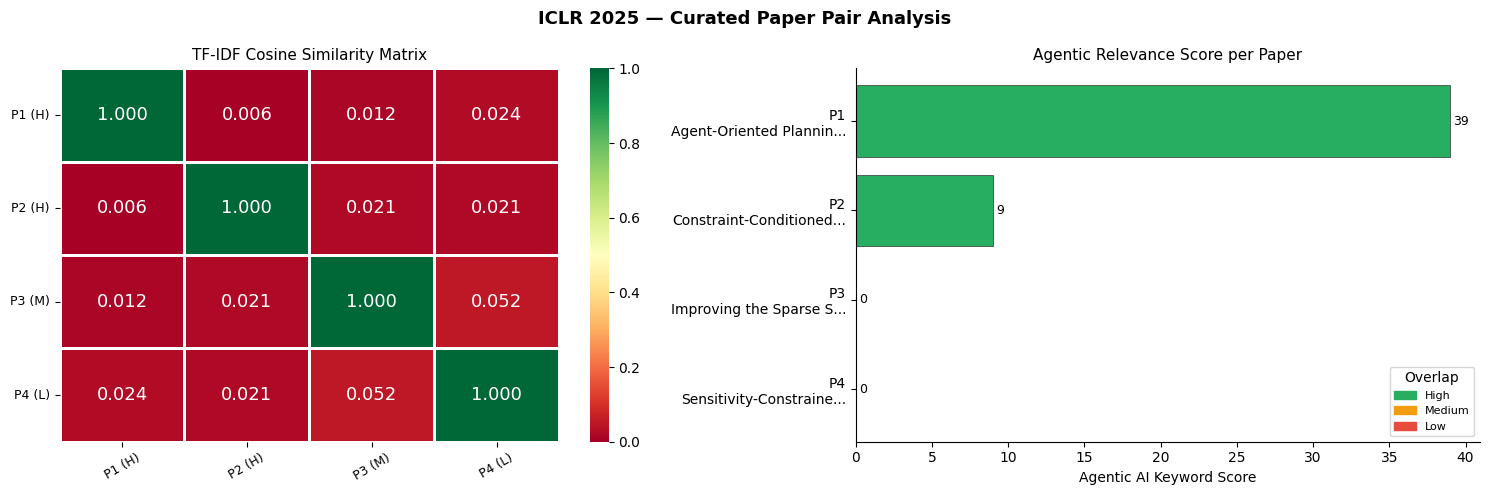

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'{CONFERENCE} — Curated Paper Pair Analysis', fontsize=13, fontweight='bold')

# Similarity heatmap
sns.heatmap(sim_4x4, annot=True, fmt='.3f', xticklabels=sel_labels,
            yticklabels=sel_labels, cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.8, annot_kws={'size': 13}, ax=axes[0])
axes[0].set_title('TF-IDF Cosine Similarity Matrix', fontsize=11)
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Agentic score bar chart
cmap = {'high': '#27ae60', 'medium': '#f39c12', 'low': '#e74c3c'}
bar_colors = [cmap[p['overlap_category']] for p in selected]
short = [f'P{i+1}\n{selected[i]["title"][:22]}...' for i in range(4)]
bars = axes[1].barh(short, [p['agentic_score'] for p in selected],
                    color=bar_colors, edgecolor='#333', linewidth=0.5)
for bar, p in zip(bars, selected):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{p["agentic_score"]:.0f}', va='center', fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Agentic AI Keyword Score')
axes[1].set_title('Agentic Relevance Score per Paper', fontsize=11)
axes[1].spines[['top','right']].set_visible(False)
legend = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in cmap.items()]
axes[1].legend(handles=legend, title='Overlap', loc='lower right', fontsize=8)

plt.tight_layout()
save_fig(fig, 'iclr2025_curated_analysis.png')
plt.show()

In [14]:
curated_rows = []
for i, p in enumerate(selected):
    row = {'paper': f'P{i+1}', 'overlap_category': p['overlap_category'],
           'agentic_score': p['agentic_score'], 'title': p['title'],
           'authors': '; '.join(p['authors']), 'venue': p['venue'],
           'url': p['url'], 'abstract': p['abstract'],
           'matched_keywords': '; '.join(p['matched_keywords'])}
    for j in range(4):
        row[f'sim_to_P{j+1}'] = round(float(sim_4x4[i][j]), 4)
    curated_rows.append(row)

pd.DataFrame(curated_rows).to_csv('iclr2025_curated_papers.csv', index=False)
with open('iclr2025_curated_papers.json', 'w') as fh:
    json.dump({'conference': CONFERENCE, 'papers': curated_rows,
               'similarity_matrix': sim_4x4.tolist()}, fh, indent=2)
print('Exported: iclr2025_curated_papers.csv  +  iclr2025_curated_papers.json')
display(pd.DataFrame(curated_rows)[['paper','overlap_category','agentic_score',
                                     'sim_to_P1','sim_to_P2','sim_to_P3','sim_to_P4','title']])

Exported: iclr2025_curated_papers.csv  +  iclr2025_curated_papers.json


,paper,overlap_category,agentic_score,sim_to_P1,sim_to_P2,sim_to_P3,sim_to_P4,title
0,P1,high,39.0,1.0000,0.0058,0.0121,0.0244,Agent-Oriented Planning in Multi-Agent Systems
1,P2,high,9.0,0.0058,1.0000,0.0213,0.0206,Constraint-Conditioned Actor-Critic for Offlin...
2,P3,medium,0.0,0.0121,0.0213,1.0000,0.0524,Improving the Sparse Structure Learning of Spi...
3,P4,low,0.0,0.0244,0.0206,0.0524,1.0000,Sensitivity-Constrained Fourier Neural Operato...


---
## Part 3 — NLP Feature Extraction (full corpus)

All `{len(papers)}` fetched papers go through four analysis layers:

| Layer | Tool | Output |
|-------|------|--------|
| Topic Modelling | sklearn LDA | 10 topics, per-paper distribution + entropy |
| NER | spaCy `en_core_web_sm` | Entity spans, type counts |
| POS | spaCy | POS distribution, noun chunks, key verbs |
| Section ID | Rule-based Argumentative Zoning | Per-sentence rhetorical roles, coverage score |

In [15]:
# ── Short-circuit: load NLP features from Drive if available ─────
# Skips lemmatisation + LDA fit + spaCy (~10 min) on warm runs.
NLP_LOADED = False
if drive_has(NLP_JSON) and drive_has(str(ACC_NPZ)+'.npz') and drive_has(LDA_PATH):
    print('[Drive] NLP features found — loading ...')
    _nlp_data   = load_json(NLP_JSON)
    _id_map     = {p['id']: p for p in papers}
    _id_map_rej = {p['id']: p for p in rejected_papers} if 'rejected_papers' in dir() else {}
    for rec in _nlp_data.get('papers', []):
        pid = rec['id']
        target = _id_map.get(pid) or _id_map_rej.get(pid)
        if target:
            target['lemmatised_text'] = rec.get('raw_text',{}).get('abstract','')
            target['full_text']       = rec.get('raw_text',{}).get('title','') + ' ' + target['lemmatised_text']
            target['_topic_dist']     = rec.get('topic_modeling',{}).get('topic_distribution',[])
            target['_dom_topic']      = rec.get('topic_modeling',{}).get('dominant_topic_id',0)
            target['_ner']            = rec.get('ner',{})
            target['_pos']            = rec.get('pos',{})
            target['_sections']       = rec.get('sections',{}).get('abstract_rhetorical_zones',{})
            target['_readability']    = rec.get('readability',{})
            target['_rshow']          = rec.get('ml_features',{}).get('rshow',0.0)
            target['_pdf_sections']   = []
    cv          = load_model(CV_PATH)
    lda         = load_model(LDA_PATH)
    vocab       = cv.get_feature_names_out()
    topic_dists = load_npz(ACC_NPZ)['dists']
    _twords     = lambda t,n=N_TOP_WORDS: [vocab[i] for i in lda.components_[t].argsort()[::-1][:n]]
    _top_words  = _twords
    topics_meta = [{'id':t,'top_words':_twords(t),
                    'paper_count':int((topic_dists.argmax(axis=1)==t).sum())}
                   for t in range(N_TOPICS)]
    NLP_LOADED  = True
    print(f'[Drive] Loaded NLP features for {len(_nlp_data["papers"])} papers. '
          f'All spaCy/LDA cells will be skipped.')
else:
    print('No Drive cache found — will compute from scratch.')
# ── Always ensure _nlp_tok + _lemmatise are available ───────────────────────
import spacy as _spacy_module
if '_nlp_tok' not in dir():
    _nlp_tok = _spacy_module.load('en_core_web_sm', disable=['ner','parser'])
    print('[Setup] spaCy tokeniser loaded.')

def _lemmatise(text: str) -> str:
    doc = _nlp_tok(text[:2000])
    return ' '.join(
        t.lemma_.lower() for t in doc
        if not t.is_stop and not t.is_punct and t.is_alpha
        and len(t.text) > 2 and t.lemma_.lower() not in STOP_EXTRA
    )

if '_nlp_full' not in dir():
    _nlp_full = spacy.load('en_core_web_sm')
    _nlp_full.max_length = 1_000_000


[Drive] NLP features found — loading ...
[Drive] Loaded NLP features for 800 papers. All spaCy/LDA cells will be skipped.
[Setup] spaCy tokeniser loaded.


In [16]:
if not NLP_LOADED:
    # ── Lightweight lemmatiser for LDA vocab ──────────────────────────
    _nlp_tok = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

    def _lemmatise(text: str) -> str:
        doc = _nlp_tok(text[:2000])
        return ' '.join(
            t.lemma_.lower() for t in doc
            if not t.is_stop and not t.is_punct and t.is_alpha
            and len(t.text) > 2 and t.lemma_.lower() not in STOP_EXTRA
        )

    print('Lemmatising corpus …')
    for p in tqdm(papers):
        p['full_text']       = p['title'] + '. ' + p['abstract']
        p['lemmatised_text'] = _lemmatise(p['full_text'])

    print(f'Done. Example lemmas: {papers[0]["lemmatised_text"][:160]} …')
else:
    print('[Drive] NLP already loaded — skipping this step.')


[Drive] NLP already loaded — skipping this step.


In [17]:
if not NLP_LOADED:
    corpus_texts = [p['lemmatised_text'] for p in papers]

    if drive_has(LDA_PATH) and drive_has(CV_PATH):
        print('[Drive] Loading fitted LDA + CountVectorizer ...')
        cv  = load_model(CV_PATH)
        lda = load_model(LDA_PATH)
        vocab = cv.get_feature_names_out()
        dtm   = cv.transform(corpus_texts)
        if drive_has(str(ACC_NPZ) + '.npz'):
            topic_dists = load_npz(ACC_NPZ)['dists']
            print('[Drive] Loaded topic distributions.')
        else:
            topic_dists = lda.transform(dtm)
            save_npz(ACC_NPZ, dists=topic_dists)
    else:
        cv = CountVectorizer(max_features=CV_MAX_FEATURES, min_df=CV_MIN_DF,
                             max_df=CV_MAX_DF, ngram_range=(1,2), stop_words='english')
        dtm   = cv.fit_transform(corpus_texts)
        vocab = cv.get_feature_names_out()
        print(f'Vocabulary: {len(vocab):,} terms  DTM: {dtm.shape}')
        lda = LatentDirichletAllocation(n_components=N_TOPICS, max_iter=LDA_MAX_ITER,
            learning_method='online', learning_offset=50.0,
            random_state=LDA_SEED, n_jobs=-1)
        print('Fitting LDA ...')
        topic_dists = lda.fit_transform(dtm)
        save_model(cv,  CV_PATH)
        save_model(lda, LDA_PATH)
        save_npz(ACC_NPZ, dists=topic_dists)

    def _top_words(t, n=N_TOP_WORDS):
        return [vocab[i] for i in lda.components_[t].argsort()[::-1][:n]]

    topics_meta = []
    print(f'Top 8 words per topic:')
    for t in range(N_TOPICS):
        words = _top_words(t)
        count = int((topic_dists.argmax(axis=1)==t).sum())
        topics_meta.append({'id':t,'top_words':words,'paper_count':count})
        print(f'  T{t:02d} ({count:4d} papers): {" | ".join(words[:8])}')

    for i,p in enumerate(papers):
        dist = topic_dists[i].tolist()
        p['_topic_dist'] = dist
        p['_dom_topic']  = int(np.argmax(dist))
else:
    print('[Drive] NLP already loaded — skipping this step.')


[Drive] NLP already loaded — skipping this step.


In [18]:
if not NLP_LOADED:
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle(f'{CONFERENCE} — LDA Topic Word Distributions', fontsize=14, fontweight='bold')
    cmap_tab = plt.cm.get_cmap('tab10', N_TOPICS)
    for t, ax in enumerate(axes.flatten()):
        words  = topics_meta[t]['top_words'][:10]
        w_idx  = [i for i, w in enumerate(vocab) if w in words]
        scores = lda.components_[t][w_idx]
        scores_n = scores / (scores.sum() or 1)
        ax.barh(words[::-1], scores_n[::-1], color=cmap_tab(t), edgecolor='white', linewidth=0.3)
        ax.set_title(f'T{t} ({topics_meta[t]["paper_count"]} papers)', fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    save_fig(fig, 'iclr2025_lda_topics.png')
    plt.show()
    print('Saved → iclr2025_lda_topics.png')
else:
    print('[Drive] NLP already loaded — skipping this step.')


[Drive] NLP already loaded — skipping this step.


In [19]:
if not NLP_LOADED:
    # ── Full spaCy pipeline (NER + parser for noun chunks) ────────────
    _nlp_full = spacy.load('en_core_web_sm')
    _nlp_full.max_length = 1_000_000

    NER_DESCRIPTIONS = {
        'PERSON': 'People', 'ORG': 'Organisations', 'GPE': 'Countries/Cities',
        'PRODUCT': 'Products (models, datasets)', 'WORK_OF_ART': 'Titles',
        'EVENT': 'Named events', 'NORP': 'Groups/Nationalities',
        'LOC': 'Locations', 'MONEY': 'Monetary values',
        'CARDINAL': 'Numbers', 'PERCENT': 'Percentages',
    }
    CONTENT_POS = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}

    full_texts = [p['full_text'][:1500] for p in papers]
    print(f'Running spaCy on {len(full_texts)} documents …')
    spacy_docs = list(tqdm(
        _nlp_full.pipe(full_texts, batch_size=64), total=len(full_texts)))
    print('Done.')
else:
    print('[Drive] NLP already loaded — skipping this step.')


[Drive] NLP already loaded — skipping this step.


In [20]:
# ── Named Entity Recognition ──────────────────────────────────────
def _extract_ner(doc) -> Dict:
    entities = [{'text': e.text, 'label': e.label_,
                  'description': NER_DESCRIPTIONS.get(e.label_, e.label_),
                  'start_char': e.start_char, 'end_char': e.end_char}
                for e in doc.ents]
    type_counts = Counter(e['label'] for e in entities)
    return {'entities': entities, 'entity_type_counts': dict(type_counts),
            'total_entities': len(entities),
            'unique_entities': len({e['text'].lower() for e in entities})}

if not NLP_LOADED:
    for p, doc in zip(papers, spacy_docs):
        p['_ner'] = _extract_ner(doc)

    all_ner_labels = Counter()
    for p in papers:
        all_ner_labels.update(p['_ner']['entity_type_counts'])

    ner_df = pd.DataFrame(all_ner_labels.most_common(), columns=['Entity Type', 'Count'])
    display(ner_df)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(ner_df['Entity Type'], ner_df['Count'], color='steelblue', edgecolor='white')
    ax.set_title(f'{CONFERENCE} — NER Entity Type Frequency', fontsize=12)
    ax.set_ylabel('Total count across corpus')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    save_fig(fig, 'iclr2025_ner.png')
    plt.show()
else:
    print('[Drive] NLP already loaded — skipping NER step.')

[Drive] NLP already loaded — skipping NER step.


In [21]:
# ── Part-of-Speech Analysis ───────────────────────────────────────
def _extract_pos(doc) -> Dict:
    pos_ctr = Counter()
    nouns, verbs, adjs = [], [], []
    noun_chunks = [c.text.lower() for c in doc.noun_chunks if len(c.text.split()) > 1]
    for t in doc:
        if t.is_stop or t.is_punct or not t.is_alpha or len(t.text) < 2:
            continue
        pos_ctr[t.pos_] += 1
        lm = t.lemma_.lower()
        if t.pos_ in ('NOUN', 'PROPN') and lm not in STOP_EXTRA:
            nouns.append(lm)
        elif t.pos_ == 'VERB' and lm not in STOP_EXTRA:
            verbs.append(lm)
        elif t.pos_ == 'ADJ':
            adjs.append(t.text.lower())
    content_total = sum(pos_ctr.get(p, 0) for p in CONTENT_POS)
    n_nouns = pos_ctr.get('NOUN', 0) + pos_ctr.get('PROPN', 0)
    return {
        'distribution'         : dict(pos_ctr),
        'noun_chunks'          : [w for w, _ in Counter(noun_chunks).most_common(10)],
        'key_verbs_lemmatised' : [w for w, _ in Counter(verbs).most_common(10)],
        'key_adjectives'       : [w for w, _ in Counter(adjs).most_common(10)],
        'noun_to_verb_ratio'   : round(n_nouns / max(pos_ctr.get('VERB', 1), 1), 3),
        'adjective_density'    : round(pos_ctr.get('ADJ', 0) / max(content_total, 1), 4),
        'content_token_count'  : content_total,
    }

if not NLP_LOADED:
    for p, doc in zip(papers, spacy_docs):
        p['_pos'] = _extract_pos(doc)

    agg_pos = Counter()
    for p in papers:
        agg_pos.update(p['_pos']['distribution'])

    pos_order = ['NOUN','VERB','ADJ','ADV','PROPN','DET','ADP','CCONJ','SCONJ','NUM','PART']
    labels = [l for l in pos_order if l in agg_pos]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(labels, [agg_pos[l] for l in labels], color='coral', edgecolor='white')
    ax.set_title(f'{CONFERENCE} — Corpus-wide POS Distribution', fontsize=12)
    ax.set_ylabel('Total tokens')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    save_fig(fig, 'iclr2025_pos.png')
    plt.show()

    print('\nTop noun chunks across corpus:')
    all_chunks = Counter()
    for p in papers:
        all_chunks.update(p['_pos']['noun_chunks'])
    for phrase, cnt in all_chunks.most_common(15):
        print(f'  {cnt:4d}×  {phrase}')
else:
    print('[Drive] NLP already loaded — skipping POS step.')

[Drive] NLP already loaded — skipping POS step.


In [22]:
# ── Rhetorical Role / Section Identifier ───────────────────────────
#
# Each abstract sentence is classified into one of 6 IMRaD-inspired
# rhetorical roles using weighted keyword patterns + Gaussian
# positional prior (Background expected early, Conclusion late).

_RHETORICAL_RULES: Dict[str, List[Tuple[str, float]]] = {
    'Background':  [
        (r'\brecent(ly)?\b',1.0),(r'\bprevious\b',1.0),(r'\bexisting\b',1.0),
        (r'\btraditional(ly)?\b',1.0),(r'\bhave been\b',0.8),(r'\bhas been\b',0.8),
        (r'\bwidely (used|studied)\b',1.2),(r'\bprior work\b',1.5),
        (r'\bin recent years\b',1.5),(r'\bstate.of.the.art\b',1.0),
    ],
    'Problem':     [
        (r'\bhowever\b',1.5),(r'\bunfortunately\b',1.5),(r'\black(s|ing)?\b',1.2),
        (r'\blimit(ed|ation)?\b',1.0),(r'\bchallenge(s|d)?\b',1.2),
        (r'\bfail(s|ed)?\b',1.2),(r'\bcannot\b',1.2),(r'\bgap\b',1.5),
        (r'\bshortcoming\b',1.5),(r'\bsuffer(s|ing)?\b',1.0),
    ],
    'Objective':   [
        (r'\bwe propose\b',2.0),(r'\bwe present\b',2.0),(r'\bwe introduce\b',2.0),
        (r'\bthis paper (presents?|proposes?|introduces?)\b',2.5),
        (r'\bour goal\b',2.0),(r'\bwe aim\b',1.8),(r'\bin this (paper|work)\b',1.5),
        (r'\bour contribution\b',2.0),(r'\bnovel\b',0.8),
    ],
    'Methodology': [
        (r'\bwe use\b',1.0),(r'\bwe employ\b',1.2),(r'\bour (model|architecture)\b',1.5),
        (r'\bframework\b',1.0),(r'\balgorithm\b',1.2),(r'\bconsists? of\b',1.2),
        (r'\bbased on\b',1.0),(r'\bfine.tun\b',1.0),(r'\bloss function\b',1.2),
        (r'\barchitecture\b',1.0),(r'\boptimiz\b',0.8),
    ],
    'Results':     [
        (r'\bexperiment(s|al)?\b',1.0),(r'\bevaluat(e|ion)\b',1.0),
        (r'\bachiev(e|es|ed|ing)\b',1.2),(r'\boutperform(s|ed)?\b',1.5),
        (r'\bimprove(ment|s|d)?\b',1.0),(r'\baccuracy\b',1.2),
        (r'\bbenchmark(s)?\b',1.2),(r'\bsurpass(es|ed)?\b',1.5),
        (r'\bsignificant(ly)?\b',0.8),(r'\bstate.of.the.art\b',1.0),
    ],
    'Conclusion':  [
        (r'\bconclu(de|sion)\b',2.0),(r'\bin summary\b',2.0),(r'\boverall\b',1.0),
        (r'\bfuture (work|direction)\b',2.0),(r'\bwe (hope|believe|expect)\b',1.5),
        (r'\bpave the way\b',2.0),(r'\bbroader impact\b',2.0),
        (r'\bopen (question|problem)\b',1.5),(r'\blimitation(s)?\b',1.0),
    ],
}
_COMPILED = {role: [(re.compile(p, re.IGNORECASE), w) for p, w in rules]
             for role, rules in _RHETORICAL_RULES.items()}
_ROLE_CENTRES = {'Background':0.10,'Problem':0.30,'Objective':0.45,
                  'Methodology':0.60,'Results':0.75,'Conclusion':0.90}


def _classify_sent(text: str, pos: float) -> Tuple[str, float]:
    kw = {r: sum(w for pat, w in rules if pat.search(text))
          for r, rules in _COMPILED.items()}
    pb = {r: math.exp(-0.5*((pos-mu)/0.25)**2) for r, mu in _ROLE_CENTRES.items()}
    combined = {r: kw[r] + 0.5*pb[r] for r in _COMPILED}
    best = max(combined, key=combined.get)
    total = sum(combined.values()) or 1.0
    return best, round(combined[best]/total, 4)


def _split_sents(text: str) -> List[str]:
    return [s.strip() for s in re.split(r'(?<=[a-z0-9])\. +(?=[A-Z])', text)
            if len(s.strip()) > 15]


def _identify_sections(abstract: str) -> Dict:
    sents = _split_sents(abstract)
    n     = len(sents)
    annotated, roles_seen = [], set()
    for idx, s in enumerate(sents):
        pos  = idx / max(n-1, 1)
        role, conf = _classify_sent(s, pos)
        roles_seen.add(role)
        annotated.append({'index': idx, 'position_ratio': round(pos,3),
                          'text': s, 'rhetorical_role': role, 'confidence': conf})
    all_roles  = list(_RHETORICAL_RULES.keys())
    coverage   = {r: (r in roles_seen) for r in all_roles}
    return {'source': 'abstract_rhetorical_zoning', 'sentence_count': n,
            'sentences': annotated, 'role_coverage': coverage,
            'coverage_score': round(sum(coverage.values())/len(all_roles), 4),
            'roles_present': sorted(roles_seen)}


if not NLP_LOADED:
    print('Classifying abstract sentences …')
    for p in tqdm(papers):
        p['_sections'] = _identify_sections(p['abstract'])

    # Sanity check on first paper
    ex = papers[0]
    print(f"\nExample: {ex['title'][:60]}")
    print(f"Coverage: {ex['_sections']['coverage_score']}  roles: {ex['_sections']['roles_present']}")
    for s in ex['_sections']['sentences']:
        print(f"  [{s['rhetorical_role']:12s} {s['confidence']:.2f}] {s['text'][:75]}")
else:
    print('[Drive] NLP already loaded — skipping this step.')


[Drive] NLP already loaded — skipping this step.


In [23]:
if not NLP_LOADED:
    role_order = ['Background','Problem','Objective','Methodology','Results','Conclusion']
    role_pres  = {r: sum(1 for p in papers if r in p['_sections']['roles_present']) for r in role_order}
    cov_scores = [p['_sections']['coverage_score'] for p in papers]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{CONFERENCE} — Abstract Rhetorical Role Analysis', fontsize=13, fontweight='bold')

    pcts  = [role_pres[r]/len(papers)*100 for r in role_order]
    rcolors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12','#1abc9c']
    axes[0].barh(role_order[::-1], pcts[::-1], color=rcolors[::-1], edgecolor='white')
    axes[0].set_xlabel('% of papers containing this role')
    axes[0].set_title('Role Presence Rate', fontsize=11)
    axes[0].set_xlim(0, 108)
    for i,(r,pct) in enumerate(zip(role_order[::-1], pcts[::-1])):
        axes[0].text(pct+0.5, i, f'{pct:.0f}%', va='center', fontsize=9)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].hist(cov_scores, bins=7, color='#2c3e50', edgecolor='white', rwidth=0.85)
    axes[1].axvline(np.mean(cov_scores), color='#e74c3c', linestyle='--',
                    label=f'Mean={np.mean(cov_scores):.2f}')
    axes[1].set_xlabel('Coverage score (fraction of 6 roles present)')
    axes[1].set_ylabel('Papers')
    axes[1].set_title('Abstract Coverage Score Distribution', fontsize=11)
    axes[1].legend()
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    save_fig(fig, 'iclr2025_sections.png')
    plt.show()
else:
    print('[Drive] NLP already loaded — skipping this step.')


[Drive] NLP already loaded — skipping this step.


In [24]:
# ── Optional: full-paper section headers from PDF ─────────────────
# Set PDF_SAMPLE_SIZE > 0 in the config cell to enable.

_SEC_RE = re.compile(
    r'^(\d+\.?\s+)?(abstract|introduction|related work|background|preliminary|'
    r'preliminaries|method(ology)?|approach|model|framework|architecture|'
    r'experiment(s|al setup)?|result(s)?|evaluation|analysis|discussion|'
    r'conclusion|future work|limitation(s)?|appendix|reference(s)?)\s*$',
    re.IGNORECASE)


def _extract_pdf_sections(pdf_url: str) -> List[str]:
    try:
        r = requests.get(pdf_url, timeout=30, stream=True)
        r.raise_for_status()
        headers_found = []
        with pdfplumber.open(io.BytesIO(r.content)) as pdf:
            for page in pdf.pages[:14]:
                for line in (page.extract_text() or '').split('\n'):
                    line = line.strip()
                    if line and len(line) <= 70 and _SEC_RE.match(line):
                        headers_found.append(line)
        seen, unique = set(), []
        for h in headers_found:
            if h.lower() not in seen:
                seen.add(h.lower())
                unique.append(h)
        return unique
    except Exception as exc:
        return [f'ERROR: {exc}']


for p in papers:
    p.setdefault('_pdf_sections', [])

if PDF_SAMPLE_SIZE > 0:
    sample = [p for p in papers if p.get('pdf_url')][:PDF_SAMPLE_SIZE]
    print(f'Downloading PDFs for {len(sample)} papers …')
    for p in tqdm(sample):
        p['_pdf_sections'] = _extract_pdf_sections(p['pdf_url'])
        time.sleep(1.5)
    for p in sample:
        print(f"  {p['title'][:55]:55s}  →  {p['_pdf_sections']}")
else:
    print(f'PDF extraction skipped (PDF_SAMPLE_SIZE={PDF_SAMPLE_SIZE}). '
          'Change in config cell to enable.')

  0%|          | 0/5 [00:00<?, ?it/s]

  Agent-Oriented Planning in Multi-Agent Systems           →  ['ABSTRACT', '1 INTRODUCTION', '2 RELATED WORK', '3 PRELIMINARIES', '5 EXPERIMENTS', '6 CONCLUSION', 'REFERENCES']
  Interpreting Emergent Planning in Model-Free Reinforcem  →  ['ABSTRACT', '1 INTRODUCTION', '2 BACKGROUND', '3 METHODOLOGY', '8 RELATED WORK', '9 FUTURE WORK', 'REFERENCES']
  AgentOccam: A Simple Yet Strong Baseline for LLM-Based   →  ['ABSTRACT', '1 INTRODUCTION', '2 RELATED WORK', '4 METHOD', '6 CONCLUSION', 'REFERENCES']
  Robotouille: An Asynchronous Planning Benchmark for LLM  →  ['ABSTRACT', '1 INTRODUCTION', '4 EXPERIMENTS', '5 DISCUSSION', 'REFERENCES']
  DataEnvGym: Data Generation Agents in Teacher Environme  →  ['ABSTRACT', '1 INTRODUCTION', '3 EXPERIMENTS', '4 RELATED WORK', '5 CONCLUSION', 'REFERENCES']


Readability:   0%|          | 0/800 [00:00<?, ?it/s]

Readability stats:


,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,avg_sentence_length,type_token_ratio,technical_term_ratio
count,800.00,800.00,800.00,800.00,800.00,800.00
mean,13.52,17.04,20.25,24.97,0.65,0.30
std,11.87,2.19,2.61,4.27,0.05,0.05
min,-29.62,10.41,12.64,15.00,0.46,0.15
25%,5.85,15.48,18.43,22.22,0.61,0.27
50%,13.26,17.06,20.38,24.39,0.65,0.31
75%,21.98,18.45,22.02,27.15,0.68,0.34
max,44.18,28.32,33.74,48.50,0.83,0.48


  [Drive] figure iclr2025_readability.png


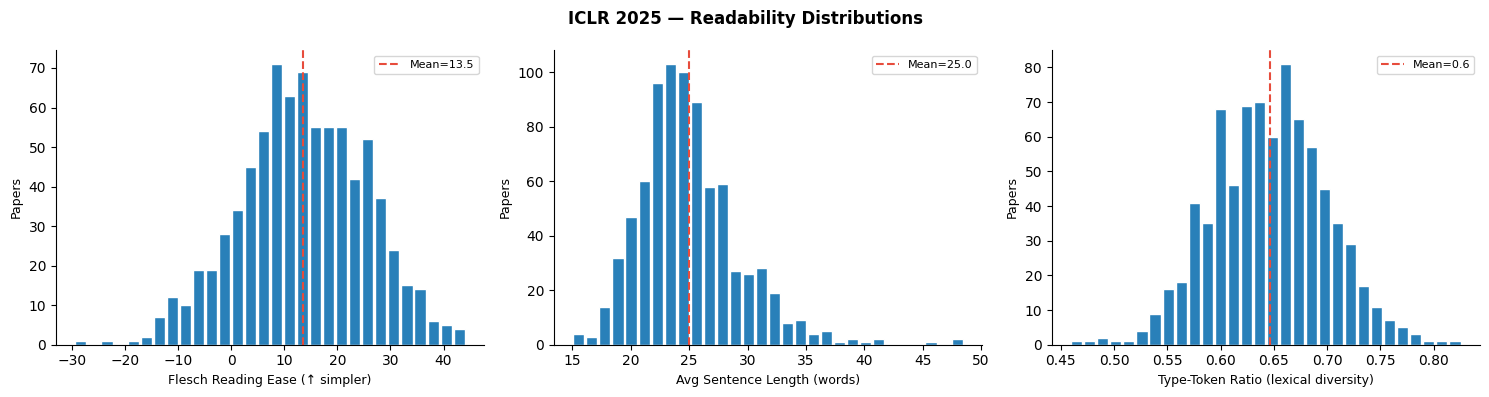

In [25]:
# ── Readability metrics ───────────────────────────────────────────
def _readability(text: str) -> Dict:
    sents = [s for s in re.split(r'(?<=[.!?])\s+', text) if len(s) > 5]
    words = re.findall(r"\b[a-zA-Z']+\b", text)
    if not sents or not words:
        return {}
    sample = words[:200]
    ttr    = round(len({w.lower() for w in sample}) / max(len(sample),1), 4)
    return {
        'flesch_reading_ease'  : round(textstat.flesch_reading_ease(text), 2),
        'flesch_kincaid_grade' : round(textstat.flesch_kincaid_grade(text), 2),
        'gunning_fog'          : round(textstat.gunning_fog(text), 2),
        'smog_index'           : round(textstat.smog_index(text), 2),
        'automated_readability': round(textstat.automated_readability_index(text), 2),
        'avg_sentence_length'  : round(len(words)/max(len(sents),1), 2),
        'avg_word_length_chars': round(sum(len(w) for w in words)/max(len(words),1), 2),
        'total_sentences'      : len(sents),
        'total_words'          : len(words),
        'total_chars'          : len(text),
        'type_token_ratio'     : ttr,
        'technical_term_ratio' : round(sum(1 for w in words if len(w)>=8)/max(len(words),1), 4),
    }

for p in tqdm(papers, desc='Readability'):
    p['_readability'] = _readability(p['abstract'])

read_df = pd.DataFrame([p['_readability'] for p in papers if p['_readability']])
print('Readability stats:')
display(read_df[['flesch_reading_ease','flesch_kincaid_grade','gunning_fog',
                  'avg_sentence_length','type_token_ratio','technical_term_ratio']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, lbl in zip(axes,
    ['flesch_reading_ease','avg_sentence_length','type_token_ratio'],
    ['Flesch Reading Ease (↑ simpler)','Avg Sentence Length (words)','Type-Token Ratio (lexical diversity)']):
    ax.hist(read_df[col].dropna(), bins=30, color='#2980b9', edgecolor='white', rwidth=0.85)
    ax.axvline(read_df[col].mean(), color='#e74c3c', linestyle='--',
               label=f'Mean={read_df[col].mean():.1f}')
    ax.set_xlabel(lbl, fontsize=9); ax.set_ylabel('Papers', fontsize=9)
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
fig.suptitle(f'{CONFERENCE} — Readability Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'iclr2025_readability.png')
plt.show()

---
## Part 3b — Run NLP Pipeline on Rejected Papers

We apply the **same fitted models** to rejected papers — no refitting.  
This means the LDA topic space is defined by the Gold Standard (accepted papers).  
Each rejected paper gets a `topic_distribution` that measures *how close it is to Gold Standard topics* — a direct thematic probability signal for the FCoT judge.

We also compute the **R_show ratio** (Ch. 9, §2.2) for every paper:

$$R_{show} = \\frac{\\text{Adjectives} + \\text{Verbs}}{\\text{Nouns} + \\text{Adverbs}}$$

In [26]:
# Initialise so it's always defined (even if rejected_papers is empty)
rej_topic_dists = np.empty((0, N_TOPICS))

In [27]:
# ── Guard: skip entirely if no rejected papers ───────────────────
if not rejected_papers:
    print('WARNING: rejected_papers is empty — skipping NLP on rejected corpus.')
    print('Re-run p1b-fetch-rejected or check the OpenReview API.')
else:
    print(f'Processing {len(rejected_papers)} rejected papers ...')

    # ── Lemmatise ─────────────────────────────────────────────────
    print('  Lemmatising ...')
    for p in tqdm(rejected_papers):
        p['full_text']       = p['title'] + '. ' + p['abstract']
        p['lemmatised_text'] = _lemmatise(p['full_text'])
        _score(p)

    # Filter out any papers where lemmatisation returned empty string
    valid_rej = [p for p in rejected_papers if p.get('lemmatised_text','').strip()]
    if len(valid_rej) < len(rejected_papers):
        print(f'  Dropped {len(rejected_papers)-len(valid_rej)} papers with empty lemmatised text')

    if not valid_rej:
        print('WARNING: all rejected papers produced empty lemmatised text. '
              'Check _nlp_tok and _lemmatise function.')
    else:
        # ── Topic distributions ───────────────────────────────────
        if drive_has(str(REJ_NPZ)+'.npz'):
            print('  [Drive] Loading rejected topic distributions ...')
            rej_topic_dists = load_npz(REJ_NPZ)['dists']
        else:
            print(f'  Transforming {len(valid_rej)} papers through Gold Standard LDA ...')
            rej_dtm         = cv.transform([p['lemmatised_text'] for p in valid_rej])
            rej_topic_dists = lda.transform(rej_dtm)
            save_npz(REJ_NPZ, dists=rej_topic_dists)

        for i, p in enumerate(valid_rej):
            if i < len(rej_topic_dists):
                dist = rej_topic_dists[i].tolist()
                p['_topic_dist'] = dist
                p['_dom_topic']  = int(np.argmax(dist))

        # ── spaCy NER + POS ───────────────────────────────────────
        rej_texts = [p['full_text'][:1500] for p in valid_rej]
        print(f'  Running spaCy on {len(rej_texts)} rejected papers ...')
        rej_docs = list(tqdm(_nlp_full.pipe(rej_texts, batch_size=64),
                             total=len(rej_texts)))
        for p, doc in zip(valid_rej, rej_docs):
            p['_ner'] = _extract_ner(doc)
            p['_pos'] = _extract_pos(doc)

        # ── Section + readability ─────────────────────────────────
        for p in tqdm(valid_rej, desc='Sections'):
            p['_sections']     = _identify_sections(p['abstract'])
            p['_pdf_sections'] = []
        for p in tqdm(valid_rej, desc='Readability'):
            p['_readability']     = _readability(p['abstract'])
            p['overlap_category'] = 'rejected'

        # Update rejected_papers to only the valid ones
        rejected_papers = valid_rej
        print(f'  Done. {len(rejected_papers)} rejected papers fully processed.')


Processing 800 rejected papers ...
  Lemmatising ...


  0%|          | 0/800 [00:00<?, ?it/s]

  [Drive] Loading rejected topic distributions ...
  Running spaCy on 800 rejected papers ...


  0%|          | 0/800 [00:00<?, ?it/s]

Sections:   0%|          | 0/800 [00:00<?, ?it/s]

Readability:   0%|          | 0/800 [00:00<?, ?it/s]

  Done. 800 rejected papers fully processed.


In [28]:
def compute_rshow(p):
    d    = p.get('_pos', {}).get('distribution', {})
    adj  = d.get('ADJ', 0)
    verb = d.get('VERB', 0)
    noun = d.get('NOUN', 0) + d.get('PROPN', 0)
    adv  = d.get('ADV', 0)
    return round((adj + verb) / max(noun + adv, 1), 4)

for p in papers:          p['_rshow'] = compute_rshow(p)
for p in rejected_papers: p['_rshow'] = compute_rshow(p)

acc_rshow = [p['_rshow'] for p in papers if '_rshow' in p]
rej_rshow = [p['_rshow'] for p in rejected_papers if '_rshow' in p]

if acc_rshow:
    print(f'R_show (accepted): mean={np.mean(acc_rshow):.3f}  '
          f'[p10={np.percentile(acc_rshow,10):.3f}, '
          f'p50={np.percentile(acc_rshow,50):.3f}, '
          f'p90={np.percentile(acc_rshow,90):.3f}]')
if rej_rshow:
    print(f'R_show (rejected): mean={np.mean(rej_rshow):.3f}  '
          f'[p10={np.percentile(rej_rshow,10):.3f}, '
          f'p50={np.percentile(rej_rshow,50):.3f}, '
          f'p90={np.percentile(rej_rshow,90):.3f}]')
else:
    print('No rejected papers with R_show (rejected_papers may be empty).')


R_show (accepted): mean=0.633  [p10=0.484, p50=0.626, p90=0.792]
R_show (rejected): mean=0.631  [p10=0.476, p50=0.619, p90=0.789]


In [29]:
# ── Label and combine into one flat feature table ─────────────────
for p in papers:          p['label'], p['label_text'] = 1, 'accepted'
for p in rejected_papers: p['label'], p['label_text'] = 0, 'rejected'

if not rejected_papers:
    print('WARNING: rejected_papers is empty. '
          'Labeled dataset will only contain accepted papers (label=1).')
    print('The model will not be trainable without a negative class.')
    print('Re-run Step 1b (p1b-fetch-rejected) with an active internet connection.')


def _ml_row(p: dict) -> dict:
    read = p.get('_readability', {})
    sec  = p.get('_sections',   {})
    ner  = p.get('_ner',        {})
    pos  = p.get('_pos',        {})
    dist = p.get('_topic_dist', [0] * N_TOPICS)
    entropy = round(-sum(x * math.log(x + 1e-12) for x in dist), 4)
    return {
        'label'                  : p['label'],
        'label_text'             : p['label_text'],
        'title'                  : p['title'],
        'venue'                  : p['venue'],
        # ── POS / Show ratio ──────────────────────────────────────
        'rshow'                  : p.get('_rshow', 0.0),
        'noun_to_verb_ratio'     : pos.get('noun_to_verb_ratio', 0.0),
        'adjective_density'      : pos.get('adjective_density', 0.0),
        # ── Topic ─────────────────────────────────────────────────
        'dominant_topic_id'      : int(np.argmax(dist)),
        'dominant_topic_weight'  : round(max(dist), 5),
        'topic_entropy'          : entropy,
        # ── Structure / Sections ──────────────────────────────────
        'coverage_score'         : sec.get('coverage_score', 0.0),
        'abstract_sentence_count': read.get('total_sentences', 0),
        'abstract_word_count'    : read.get('total_words', 0),
        # ── NER ───────────────────────────────────────────────────
        'total_entities'         : ner.get('total_entities', 0),
        'unique_entities'        : ner.get('unique_entities', 0),
        # ── Readability ───────────────────────────────────────────
        'flesch_reading_ease'    : read.get('flesch_reading_ease', 0.0),
        'flesch_kincaid_grade'   : read.get('flesch_kincaid_grade', 0.0),
        'gunning_fog'            : read.get('gunning_fog', 0.0),
        'type_token_ratio'       : read.get('type_token_ratio', 0.0),
        'technical_term_ratio'   : read.get('technical_term_ratio', 0.0),
        'avg_sentence_length'    : read.get('avg_sentence_length', 0.0),
        # ── Author / meta ─────────────────────────────────────────
        'n_authors'              : len(p.get('authors', [])),
        'n_keywords'             : len(p.get('keywords', [])),
        'agentic_score'          : p.get('agentic_score', 0.0),
    }


labeled_df = pd.DataFrame([_ml_row(p) for p in papers + rejected_papers])
save_parquet(labeled_df, LABELED_PQ)

print(f'Combined labeled dataset: {dict(labeled_df["label_text"].value_counts())}')
print(f'Features: {len(labeled_df.columns) - 3} ML columns + label + title + venue')
print()
print('Mean values by class:')
num_cols = labeled_df.select_dtypes(include='number').columns.tolist()
display(labeled_df.groupby('label_text')[num_cols].mean().round(3))

  [Drive] saved  iclr2025_labeled_features.parquet  (0.2 MB)
Combined labeled dataset: {'accepted': np.int64(800), 'rejected': np.int64(800)}
Features: 21 ML columns + label + title + venue

Mean values by class:


,label,rshow,noun_to_verb_ratio,adjective_density,dominant_topic_id,dominant_topic_weight,topic_entropy,coverage_score,abstract_sentence_count,abstract_word_count,...,unique_entities,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,type_token_ratio,technical_term_ratio,avg_sentence_length,n_authors,n_keywords,agentic_score
label_text,,,,,,,,,,,,,,,,,,,,,
accepted,1.0,0.633,2.971,0.182,6.369,0.815,0.445,0.723,8.201,201.444,...,5.684,13.519,17.040,20.246,0.646,0.305,24.967,5.646,4.080,2.664
rejected,0.0,0.631,3.019,0.182,6.349,0.744,0.604,0.733,8.209,193.650,...,5.196,15.168,16.686,19.789,0.638,0.299,24.314,4.660,3.579,1.798


  [Drive] figure iclr2025_accepted_vs_rejected.png


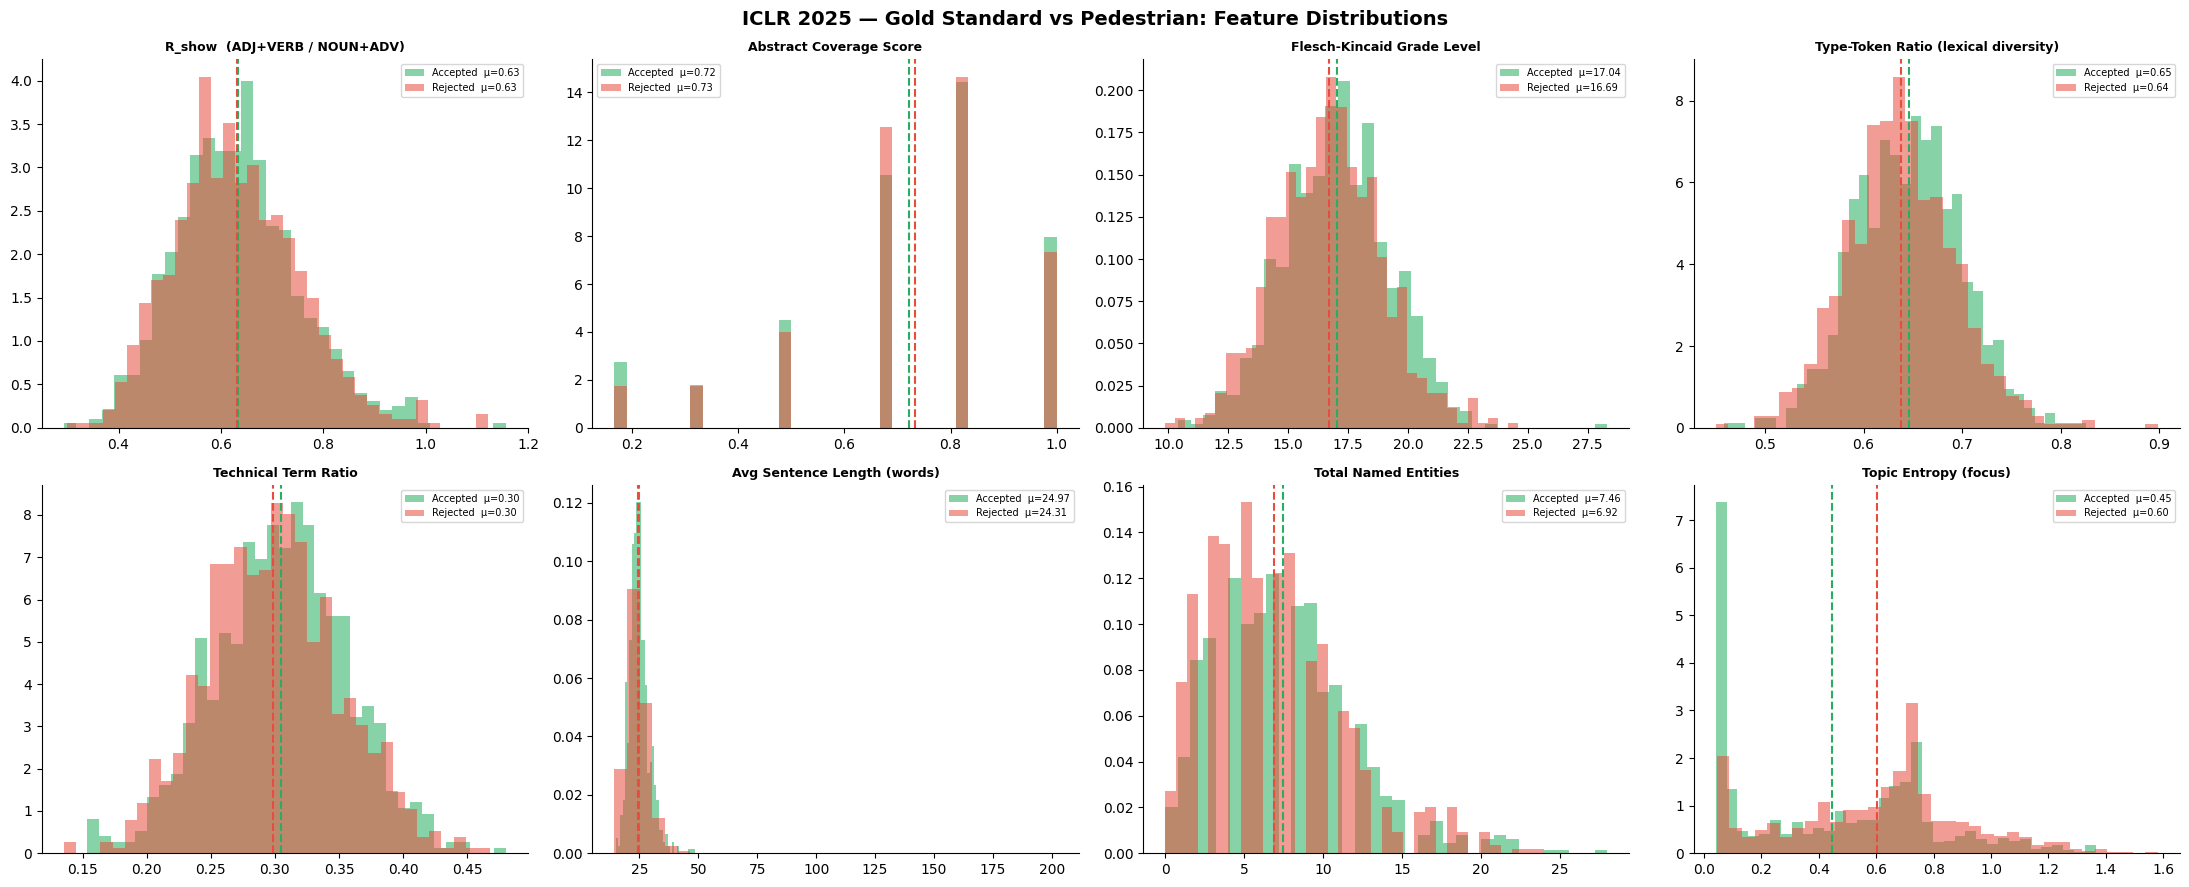

Saved → iclr2025_accepted_vs_rejected.png


In [30]:
# ── Accepted vs Rejected distribution comparison ──────────────────
plot_features = [
    ('rshow',                'R_show  (ADJ+VERB / NOUN+ADV)'),
    ('coverage_score',       'Abstract Coverage Score'),
    ('flesch_kincaid_grade', 'Flesch-Kincaid Grade Level'),
    ('type_token_ratio',     'Type-Token Ratio (lexical diversity)'),
    ('technical_term_ratio', 'Technical Term Ratio'),
    ('avg_sentence_length',  'Avg Sentence Length (words)'),
    ('total_entities',       'Total Named Entities'),
    ('topic_entropy',        'Topic Entropy (focus)'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle(
    f'{CONFERENCE} — Gold Standard vs Pedestrian: Feature Distributions',
    fontsize=14, fontweight='bold'
)
axes = axes.flatten()

acc_data = labeled_df[labeled_df['label'] == 1]
rej_data = labeled_df[labeled_df['label'] == 0]

for ax, (feat, label) in zip(axes, plot_features):
    av = acc_data[feat].dropna()
    rv = rej_data[feat].dropna()
    ax.hist(av, bins=35, alpha=0.55, color='#27ae60', density=True,
            label=f'Accepted  μ={av.mean():.2f}')
    ax.hist(rv, bins=35, alpha=0.55, color='#e74c3c', density=True,
            label=f'Rejected  μ={rv.mean():.2f}')
    ax.axvline(av.mean(), color='#27ae60', linewidth=1.5, linestyle='--')
    ax.axvline(rv.mean(), color='#e74c3c', linewidth=1.5, linestyle='--')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_fig(fig, 'iclr2025_accepted_vs_rejected.png')
plt.show()
print('Saved → iclr2025_accepted_vs_rejected.png')

In [31]:
# ── Gold Standard Ranges (input to FCoT prompting in next notebook) ─
#
# For each feature we store the accepted-paper distribution percentiles.
# The FCoT judge uses these ranges as guardrails:
#   'given that accepted papers have R_show in [p25, p75],
#    this paper at R_show=0.21 falls below the Gold Standard threshold.'

num_features = [c for c in labeled_df.select_dtypes(include='number').columns
                if c != 'label']

gold_ranges = {}
for feat in num_features:
    av = labeled_df[labeled_df['label'] == 1][feat].dropna()
    rv = labeled_df[labeled_df['label'] == 0][feat].dropna()
    gold_ranges[feat] = {
        'gold_standard': {
            'mean': round(av.mean(), 4), 'std': round(av.std(), 4),
            'p10' : round(av.quantile(.10), 4),
            'p25' : round(av.quantile(.25), 4),
            'p50' : round(av.quantile(.50), 4),
            'p75' : round(av.quantile(.75), 4),
            'p90' : round(av.quantile(.90), 4),
        },
        'pedestrian': {
            'mean': round(rv.mean(), 4),
            'p25' : round(rv.quantile(.25), 4),
            'p50' : round(rv.quantile(.50), 4),
            'p75' : round(rv.quantile(.75), 4),
        },
        'separation': round(abs(av.mean() - rv.mean()) /
                            max((av.std() + rv.std()) / 2, 1e-6), 4),  # Cohen's d proxy
    }

# save_json handles Drive path
_gold_payload = {
        'conference': CONFERENCE,
        'n_gold_standard': int((labeled_df['label'] == 1).sum()),
        'n_pedestrian':    int((labeled_df['label'] == 0).sum()),
        'features': gold_ranges,
    }
save_json(_gold_payload, GOLD_JSON)

print('Exported → iclr2025_gold_standard_ranges.json')
print()
print('Top features by Gold vs Pedestrian separation (Cohen\'s d proxy):')
sep_df = pd.DataFrame([
    {'feature': k, 'separation': v['separation'],
     'gold_mean': v['gold_standard']['mean'],
     'ped_mean': v['pedestrian']['mean']}
    for k, v in gold_ranges.items()
]).sort_values('separation', ascending=False)
display(sep_df.head(12).reset_index(drop=True))

  [Drive] saved  gold_standard_ranges.json  (0.0 MB)
Exported → iclr2025_gold_standard_ranges.json

Top features by Gold vs Pedestrian separation (Cohen's d proxy):


,feature,separation,gold_mean,ped_mean
0,topic_entropy,0.4872,0.4455,0.6041
1,dominant_topic_weight,0.4082,0.8153,0.7440
2,n_authors,0.2902,5.6462,4.6600
3,n_keywords,0.2636,4.0800,3.5788
4,agentic_score,0.1950,2.6638,1.7975
5,gunning_fog,0.1758,20.2464,19.7888
6,abstract_word_count,0.1708,201.4438,193.6500
7,flesch_kincaid_grade,0.1606,17.0399,16.6862
8,type_token_ratio,0.1512,0.6459,0.6377
9,unique_entities,0.1500,5.6838,5.1962


---
## Part 4 — Assemble Master JSON + Export

In [32]:
def _build_record(p: Dict) -> Dict:
    dist     = p['_topic_dist']
    dom      = int(np.argmax(dist))
    read     = p.get('_readability', {})
    sec      = p.get('_sections', {})
    ner      = p.get('_ner', {})
    pos      = p.get('_pos', {})
    entropy  = round(-sum(x*math.log(x+1e-12) for x in dist), 4)
    return {
        # ── Identity ──────────────────────────────────────────────
        'id': p['id'], 'title': p['title'], 'authors': p['authors'],
        'venue': p['venue'], 'url': p['url'], 'pdf_url': p.get('pdf_url',''),
        'conference': CONFERENCE, 'source': p.get('source','openreview'),
        'overlap_category': p.get('overlap_category', 'unclassified'),
        'agentic_score': p.get('agentic_score', 0.0),

        # ── Raw text ──────────────────────────────────────────────
        'raw_text': {'title': p['title'], 'abstract': p['abstract'],
                     'keywords': p.get('keywords',[])},

        # ── Topic Modelling ───────────────────────────────────────
        'topic_modeling': {
            'dominant_topic_id'      : dom,
            'dominant_topic_keywords': topics_meta[dom]['top_words'][:10],
            'topic_distribution'     : [round(x,5) for x in dist],
            'topic_entropy'          : entropy,
        },

        # ── NER ───────────────────────────────────────────────────
        'ner': ner,

        # ── POS ───────────────────────────────────────────────────
        'pos': pos,

        # ── Sections ──────────────────────────────────────────────
        'sections': {
            'abstract_rhetorical_zones' : sec,
            'full_paper_section_headers': p.get('_pdf_sections', []),
        },

        # ── Readability ───────────────────────────────────────────
        'readability': read,

        # ── Flat ML feature row ───────────────────────────────────
        'ml_features': {
            'n_authors'               : len(p['authors']),
            'n_keywords'              : len(p.get('keywords',[])),
            'abstract_word_count'     : read.get('total_words', 0),
            'abstract_sentence_count' : read.get('total_sentences', 0),
            'coverage_score'          : sec.get('coverage_score', 0.0),
            'total_entities'          : ner.get('total_entities', 0),
            'unique_entities'         : ner.get('unique_entities', 0),
            'noun_to_verb_ratio'      : pos.get('noun_to_verb_ratio', 0.0),
            'adjective_density'       : pos.get('adjective_density', 0.0),
            'flesch_reading_ease'     : read.get('flesch_reading_ease', 0.0),
            'flesch_kincaid_grade'    : read.get('flesch_kincaid_grade', 0.0),
            'gunning_fog'             : read.get('gunning_fog', 0.0),
            'type_token_ratio'        : read.get('type_token_ratio', 0.0),
            'technical_term_ratio'    : read.get('technical_term_ratio', 0.0),
            'avg_sentence_length'     : read.get('avg_sentence_length', 0.0),
            'topic_entropy'           : entropy,
            'dominant_topic_id'       : dom,
            'dominant_topic_weight'   : round(max(dist), 5),
            'agentic_score'           : p.get('agentic_score', 0.0),
        },
    }

print('Assembling master records …')
paper_records = [_build_record(p) for p in tqdm(papers)]
print(f'Built {len(paper_records)} records.')

print('\nSample ml_features for first paper:')
for k, v in paper_records[0]['ml_features'].items():
    print(f'  {k:30s}: {v}')

Assembling master records …


  0%|          | 0/800 [00:00<?, ?it/s]

Built 800 records.

Sample ml_features for first paper:
  n_authors                     : 6
  n_keywords                    : 1
  abstract_word_count           : 220
  abstract_sentence_count       : 8
  coverage_score                : 0.8333
  total_entities                : 4
  unique_entities               : 2
  noun_to_verb_ratio            : 2.303
  adjective_density             : 0.2183
  flesch_reading_ease           : 4.65
  flesch_kincaid_grade          : 18.67
  gunning_fog                   : 21.24
  type_token_ratio              : 0.605
  technical_term_ratio          : 0.2909
  avg_sentence_length           : 27.5
  topic_entropy                 : 0.3266
  dominant_topic_id             : 7
  dominant_topic_weight         : 0.91355
  agentic_score                 : 39.0


In [33]:
# ── Curated 4-paper export  (uses 'selected' from p2, NOT paper_records) ──
export_rows = []
for i, p in enumerate(selected):          # selected = [P1, P2, P3, P4]
    row = {
        'paper_index'              : i + 1,
        'paper_label'              : f'P{i+1}',
        'overlap_category'         : p.get('overlap_category', ''),
        'agentic_score'            : round(p.get('agentic_score', 0.0), 4),
        'title'                    : p['title'],
        'authors'                  : '; '.join(p.get('authors', [])),
        'venue'                    : p.get('venue', ''),
        'url'                      : p.get('url', ''),
        'abstract'                 : p['abstract'],          # direct field on paper dict
        'paper_keywords'           : '; '.join(p.get('keywords', [])),
        'matched_agentic_keywords' : '; '.join(p.get('matched_keywords', [])),
    }
    for j in range(4):   # sim_4x4 is always 4×4
        row[f'cosine_sim_to_P{j+1}'] = round(float(sim_4x4[i][j]), 4)
    export_rows.append(row)

export_df = pd.DataFrame(export_rows)

# ── Save curated 4-paper table ────────────────────────────────────
save_parquet(export_df, CURATED_PQ)
save_json({
    'conference'       : CONFERENCE,
    'papers'           : export_rows,
    'similarity_matrix': sim_4x4.tolist(),
}, DRIVE_FEATURES / 'iclr2025_curated_papers.json')

# ── Full NLP features JSON  (uses paper_records — all 800 papers) ─
save_json({
    'metadata'          : {'conference': CONFERENCE,
                           'total_papers': len(paper_records)},
    'corpus_statistics' : {'topics': topics_meta},
    'papers'            : paper_records,
}, NLP_JSON)

# ── Labeled features parquet  (accepted + rejected rows) ─────────
if 'labeled_df' in dir() and len(labeled_df):
    save_parquet(labeled_df, LABELED_PQ)
else:
    print('labeled_df not available — re-run p3d-combine after fetching rejected papers.')

print(f'\nAll outputs saved to {DRIVE_BASE}')
display(export_df[['paper_label', 'overlap_category', 'agentic_score',
                    'cosine_sim_to_P1', 'cosine_sim_to_P2',
                    'cosine_sim_to_P3', 'cosine_sim_to_P4', 'title']])


  [Drive] saved  iclr2025_curated_papers.parquet  (0.0 MB)
  [Drive] saved  iclr2025_curated_papers.json  (0.0 MB)
  [Drive] saved  iclr2025_nlp_features.json  (8.2 MB)
  [Drive] saved  iclr2025_labeled_features.parquet  (0.2 MB)

All outputs saved to /content/drive/MyDrive/CMPE257_ICLR2025


,paper_label,overlap_category,agentic_score,cosine_sim_to_P1,cosine_sim_to_P2,cosine_sim_to_P3,cosine_sim_to_P4,title
0,P1,high,39.0,1.0000,0.0058,0.0121,0.0244,Agent-Oriented Planning in Multi-Agent Systems
1,P2,high,9.0,0.0058,1.0000,0.0213,0.0206,Constraint-Conditioned Actor-Critic for Offlin...
2,P3,medium,0.0,0.0121,0.0213,1.0000,0.0524,Improving the Sparse Structure Learning of Spi...
3,P4,low,0.0,0.0244,0.0206,0.0524,1.0000,Sensitivity-Constrained Fourier Neural Operato...


  [Drive] figure iclr2025_feature_correlation.png


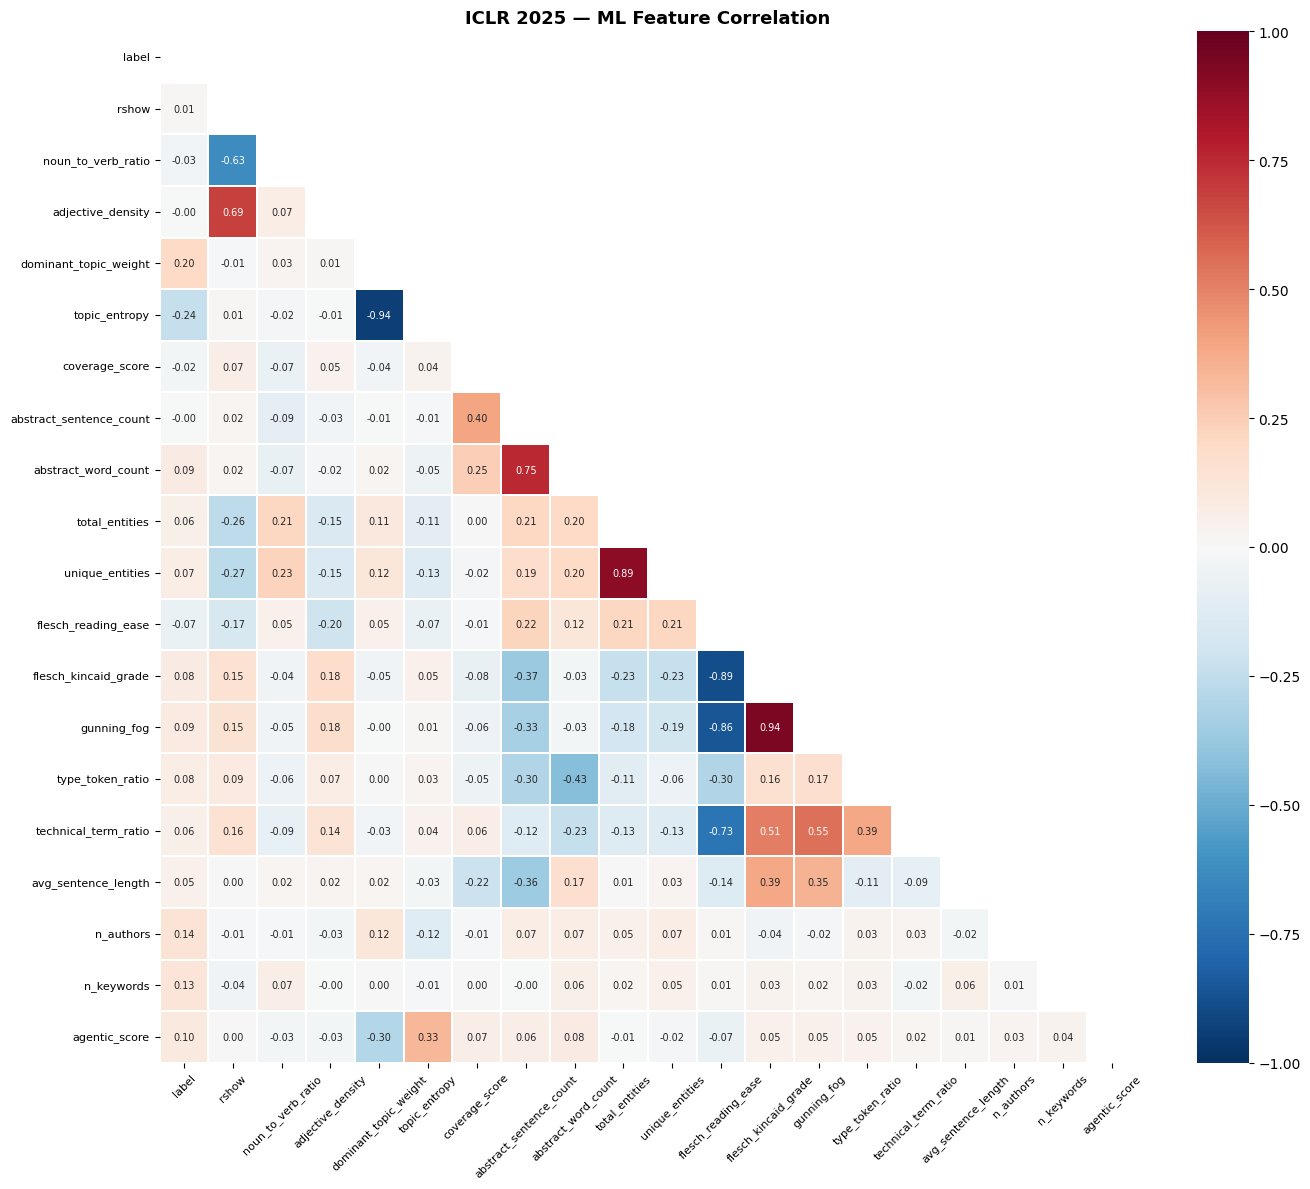

Saved → iclr2025_feature_correlation.png


In [34]:
# ── Feature correlation heatmap ───────────────────────────────────
num_cols = [c for c in labeled_df.select_dtypes(include='number').columns
            if c != 'dominant_topic_id']
corr = labeled_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size': 7}, ax=ax)
ax.set_title(f'{CONFERENCE} — ML Feature Correlation', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
save_fig(fig, 'iclr2025_feature_correlation.png')
plt.show()
print('Saved → iclr2025_feature_correlation.png')

---
## Summary

### Files produced

| File | Description |
|------|-------------|
| `iclr2025_rejected_cache.json` | Raw rejected paper metadata — reload to skip re-fetch |
| `iclr2025_labeled_features.csv` | **Primary ML input** — accepted=1 / rejected=0 labels + all features |
| `iclr2025_gold_standard_ranges.json` | Per-feature Gold Standard percentile ranges — FCoT guardrails |
| `iclr2025_accepted_vs_rejected.png` | Distribution comparison: Gold Standard vs Pedestrian |
| `iclr2025_corpus_cache.json` | Raw paper metadata — reload to skip re-fetch |
| `iclr2025_curated_papers.csv / .json` | 4 selected papers with similarity matrix |
| `iclr2025_nlp_features.json` | **Master feature store** — full NLP analysis per paper |
| `iclr2025_ml_features.csv` | Flat 18-column feature table — direct sklearn input |
| `iclr2025_curated_analysis.png` | Similarity heatmap + agentic score bar chart |
| `iclr2025_lda_topics.png` | LDA topic word distributions |
| `iclr2025_ner.png` | NER entity frequency chart |
| `iclr2025_pos.png` | POS distribution chart |
| `iclr2025_sections.png` | Rhetorical role coverage analysis |
| `iclr2025_readability.png` | Readability score distributions |
| `iclr2025_feature_correlation.png` | ML feature correlation heatmap |

### How features feed the two project objectives

| Feature | → Obj 1: Acceptance prob | → Obj 2: Improvement suggestion |
|---------|--------------------------|----------------------------------|
| `coverage_score` | Structural completeness | _"Your abstract missing Results sentence"_ |
| `flesch_kincaid_grade` | Clarity vs accepted baseline | _"Reads at grade 21; accepted median = 17"_ |
| `dominant_topic_id` | Topic cluster membership | _"This cluster has 9% acceptance rate"_ |
| `topic_entropy` | Focus vs scatter | _"Spans 3 topics — sharpen the framing"_ |
| `total_entities` | Empirical grounding | _"Accepted papers cite 4+ datasets; yours cites 1"_ |
| `noun_to_verb_ratio` | Writing density | _"Ratio 4.8; corpus median 2.9 — consider fewer nominals"_ |
| `type_token_ratio` | Vocabulary diversity | _"Low TTR suggests repetitive phrasing"_ |

**Next notebook:** `ICLR2025_Acceptance_Predictor.ipynb`  
Input: `iclr2025_ml_features.csv`  
Output: per-paper acceptance probability + LLM-generated improvement report.

---
# Phase 3 — Knowledge Graph Construction & Trend Analysis

Uses artifacts produced above (in memory). No Drive reload needed.

---
## Step 3 — Knowledge Graph Construction

### Strategy
| Scope | Method | Cost |
|-------|--------|------|
| Full corpus (1,600 papers) | Rule-based: NER entity co-occurrence graph | Free, instant (uses cached NER) |
| 4 curated papers | Gemini FCoT 3-iteration | ~12 API calls |

The **corpus KG** gives us aggregate entity/relationship statistics for trend analysis.  
The **Gemini FCoT KG** gives rich, typed (Subject, Predicate, Object) triples for individual paper assessment.

In [35]:
# ── Rule-based KG extraction from NER + noun chunks ───────────────
# Uses NER entities as nodes; entity pairs in the same abstract
# that are within a proximity window become edges.

def entity_graph(paper: dict) -> dict:
    """Build entity co-occurrence KG from cached NER output."""
    raw_ents = paper.get('_ner', {}).get('entities', [])
    # Deduplicate by (text.lower(), label)
    seen, nodes = set(), []
    for e in raw_ents:
        key = (e['text'].lower(), e['label'])
        if key not in seen:
            seen.add(key)
            nodes.append({'id': f'n{len(nodes)}',
                          'label': e['text'],
                          'type': e['label']})

    # Edges: pairs within proximity window (ordered by char offset)
    sorted_ents = sorted(raw_ents, key=lambda e: e.get('start_char', 0))
    edges, seen_e = [], set()
    WINDOW = 3  # connect entities within 3 positions
    id_map = {e['text'].lower(): f'n{i}' for i, e in
              enumerate({(e['text'].lower(), e['label']): e for e in raw_ents}.values())}
    for i in range(len(sorted_ents)):
        for j in range(i+1, min(i+1+WINDOW, len(sorted_ents))):
            a = sorted_ents[i]['text'].lower()
            b = sorted_ents[j]['text'].lower()
            if a == b: continue
            key = tuple(sorted([a, b]))
            if key not in seen_e and a in id_map and b in id_map:
                seen_e.add(key)
                edges.append({'source': id_map[a], 'target': id_map[b],
                              'relationship': 'CO_OCCURS_WITH'})
    n, e = len(nodes), len(edges)
    return {
        'paper_id'          : paper.get('id', ''),
        'title'             : paper.get('title', ''),
        'label'             : paper.get('label', -1),
        'nodes'             : nodes,
        'edges'             : edges,
        'semantic_richness' : round(e / max(n, 1), 3),
        'node_count'        : n,
        'edge_count'        : e,
    }

print('Rule-based KG helper defined.')

Rule-based KG helper defined.


In [36]:
# ── Build entity KG for the full corpus ──────────────────────────
all_papers = papers + rejected_papers
for p, lbl in zip(papers, [1]*len(papers)):         p['label'] = lbl
for p, lbl in zip(rejected_papers, [0]*len(rejected_papers)): p['label'] = lbl

print('Building rule-based entity KGs ...')
corpus_kgs = [entity_graph(p) for p in tqdm(all_papers)]
acc_kgs    = [kg for kg in corpus_kgs if kg['label'] == 1]
rej_kgs    = [kg for kg in corpus_kgs if kg['label'] == 0]

print(f'Built {len(corpus_kgs)} KGs — ')
print(f'  Accepted avg nodes: {np.mean([k["node_count"] for k in acc_kgs]):.1f}  '
      f'avg edges: {np.mean([k["edge_count"] for k in acc_kgs]):.1f}  '
      f'avg richness: {np.mean([k["semantic_richness"] for k in acc_kgs]):.2f}')
print(f'  Rejected avg nodes: {np.mean([k["node_count"] for k in rej_kgs]):.1f}  '
      f'avg edges: {np.mean([k["edge_count"] for k in rej_kgs]):.1f}  '
      f'avg richness: {np.mean([k["semantic_richness"] for k in rej_kgs]):.2f}')

Building rule-based entity KGs ...


  0%|          | 0/1600 [00:00<?, ?it/s]

Built 1600 KGs — 
  Accepted avg nodes: 5.8  avg edges: 11.2  avg richness: 1.54
  Rejected avg nodes: 5.3  avg edges: 9.8  avg richness: 1.45


In [37]:
# ── Gold Standard KG Fingerprint ─────────────────────────────────
# Aggregated entity/relationship statistics across ALL accepted papers.
# This is the 'what accepted papers look like' profile.

def build_fingerprint(kgs: list, label: str) -> dict:
    type_counter    = Counter()
    entity_counter  = Counter()
    richness_values = []
    for kg in kgs:
        for node in kg['nodes']:
            type_counter[node['type']] += 1
            entity_counter[node['label'].lower()] += 1
        richness_values.append(kg['semantic_richness'])
    return {
        'label'                   : label,
        'n_papers'                : len(kgs),
        'entity_type_frequency'   : dict(type_counter.most_common(15)),
        'top_entities'            : dict(entity_counter.most_common(30)),
        'avg_node_count'          : round(np.mean([k['node_count'] for k in kgs]), 2),
        'avg_edge_count'          : round(np.mean([k['edge_count'] for k in kgs]), 2),
        'avg_semantic_richness'   : round(np.mean(richness_values), 3),
        'p50_semantic_richness'   : round(float(np.percentile(richness_values, 50)), 3),
    }

gold_fingerprint = build_fingerprint(acc_kgs, 'Gold Standard (Accepted)')
ped_fingerprint  = build_fingerprint(rej_kgs, 'Pedestrian (Rejected)')

print('Gold Standard KG Fingerprint:')
for k, v in gold_fingerprint.items():
    if k not in ('top_entities', 'entity_type_frequency'): print(f'  {k}: {v}')
print(f'  Top entity types: {list(gold_fingerprint["entity_type_frequency"].keys())[:8]}')
print(f'  Top entities    : {list(gold_fingerprint["top_entities"].keys())[:10]}')

Gold Standard KG Fingerprint:
  label: Gold Standard (Accepted)
  n_papers: 800
  avg_node_count: 5.84
  avg_edge_count: 11.19
  avg_semantic_richness: 1.544
  p50_semantic_richness: 1.714
  Top entity types: ['ORG', 'CARDINAL', 'PERSON', 'ORDINAL', 'GPE', 'PERCENT', 'MONEY', 'NORP']
  Top entities    : ['first', 'two', 'llm', 'three', '2', '1', 'rl', 'one', 'second', 'ai']


  [Drive] figure iclr2025_kg_fingerprint.png


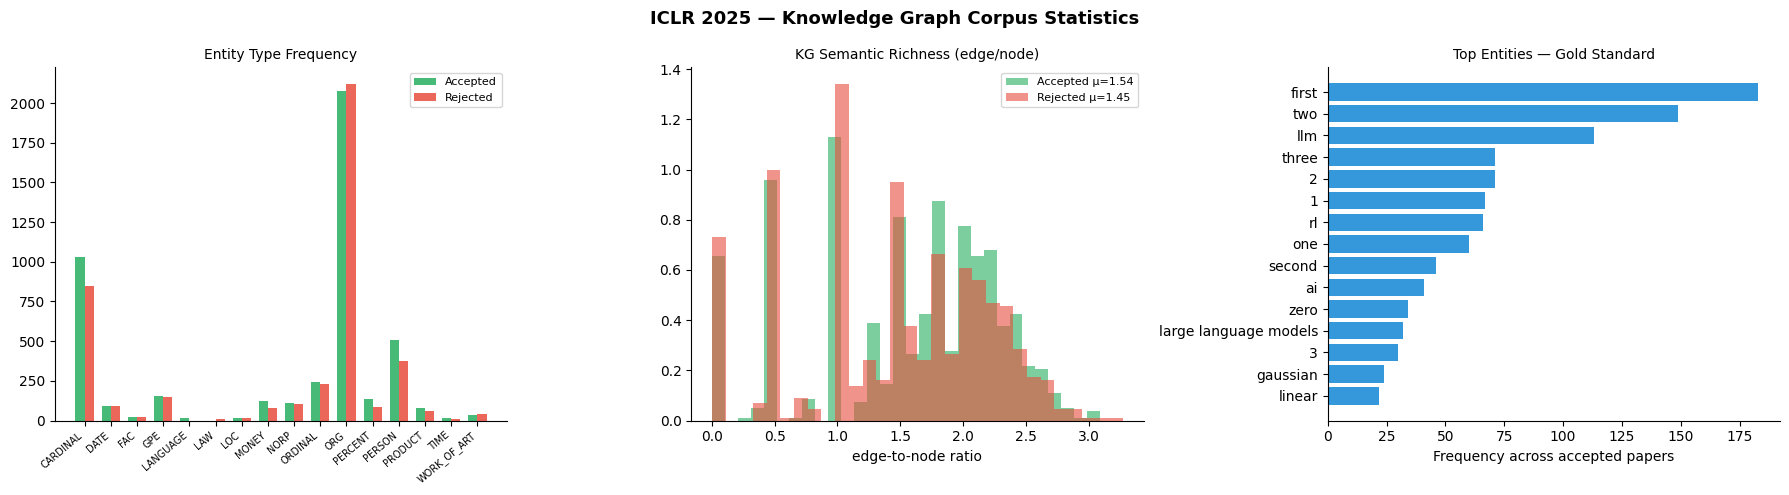

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{CONFERENCE} — Knowledge Graph Corpus Statistics', fontsize=13, fontweight='bold')

# Entity type comparison
all_types = sorted(set(gold_fingerprint['entity_type_frequency']) |
                   set(ped_fingerprint['entity_type_frequency']))
g_vals = [gold_fingerprint['entity_type_frequency'].get(t, 0) for t in all_types]
p_vals = [ped_fingerprint['entity_type_frequency'].get(t, 0)  for t in all_types]
x = np.arange(len(all_types)); w = 0.35
axes[0].bar(x-w/2, g_vals, w, label='Accepted', color='#27ae60', alpha=0.85)
axes[0].bar(x+w/2, p_vals, w, label='Rejected',  color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(all_types, rotation=40, ha='right', fontsize=7)
axes[0].set_title('Entity Type Frequency', fontsize=10); axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Semantic richness distribution
acc_rich = [k['semantic_richness'] for k in acc_kgs]
rej_rich = [k['semantic_richness'] for k in rej_kgs]
axes[1].hist(acc_rich, bins=30, alpha=0.6, color='#27ae60', density=True, label=f'Accepted μ={np.mean(acc_rich):.2f}')
axes[1].hist(rej_rich, bins=30, alpha=0.6, color='#e74c3c', density=True, label=f'Rejected μ={np.mean(rej_rich):.2f}')
axes[1].set_title('KG Semantic Richness (edge/node)', fontsize=10)
axes[1].set_xlabel('edge-to-node ratio'); axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Top entities in Gold Standard
top_ents = list(gold_fingerprint['top_entities'].items())[:15]
axes[2].barh([e[0][:25] for e in top_ents[::-1]], [e[1] for e in top_ents[::-1]], color='#3498db')
axes[2].set_title('Top Entities — Gold Standard', fontsize=10)
axes[2].set_xlabel('Frequency across accepted papers')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig(fig, 'iclr2025_kg_fingerprint.png')
plt.show()

In [39]:
corpus_kg_summary = {
    'conference'       : CONFERENCE,
    'timestamp'        : datetime.utcnow().isoformat() + 'Z',
    'gold_fingerprint' : gold_fingerprint,
    'ped_fingerprint'  : ped_fingerprint,
    'per_paper_stats'  : [
        {'id': kg['paper_id'], 'title': kg['title'], 'label': kg['label'],
         'node_count': kg['node_count'], 'edge_count': kg['edge_count'],
         'semantic_richness': kg['semantic_richness']}
        for kg in corpus_kgs
    ],
}
save_json(corpus_kg_summary, CORPUS_KG)
print(f'Corpus KG summary saved → {CORPUS_KG.name}')

  [Drive] saved  corpus_kg_summary.json  (0.4 MB)
Corpus KG summary saved → corpus_kg_summary.json


---
## Step 4a — Key Trend Identification

Two lenses:
1. **Topic lens** — which LDA topics have the highest acceptance rate in the Gold Standard?
2. **Entity lens** — which NER entities appear significantly more in accepted vs rejected papers?

Together these define the *current research hot zones* at ICLR 2025.

In [40]:
# ── LDA Topic Acceptance Rates ────────────────────────────────────
# For each topic: what fraction of papers with that dominant topic got accepted?

topic_stats = {}
for t in range(N_TOPICS):
    mask_acc = (labeled_df['label'] == 1) & (labeled_df['dominant_topic_id'] == t)
    mask_rej = (labeled_df['label'] == 0) & (labeled_df['dominant_topic_id'] == t)
    n_acc, n_rej = int(mask_acc.sum()), int(mask_rej.sum())
    n_tot = n_acc + n_rej
    topic_stats[t] = {
        'topic_id'        : t,
        'n_accepted'      : n_acc,
        'n_rejected'      : n_rej,
        'n_total'         : n_tot,
        'acceptance_rate' : round(n_acc / max(n_tot, 1), 4),
        'top_words'       : _top_words(t, 8),
    }

topic_df = pd.DataFrame(list(topic_stats.values())).sort_values('acceptance_rate', ascending=False)
print('Topic acceptance rates (sorted):')
display(topic_df[['topic_id','acceptance_rate','n_accepted','n_rejected','top_words']])

HOT_TOPIC_THRESHOLD = topic_df['acceptance_rate'].quantile(0.60)
hot_topics = set(topic_df[topic_df['acceptance_rate'] >= HOT_TOPIC_THRESHOLD]['topic_id'])
print(f'\nHot topics (≥ {HOT_TOPIC_THRESHOLD:.2f} acceptance rate): {sorted(hot_topics)}')

Topic acceptance rates (sorted):


,topic_id,acceptance_rate,n_accepted,n_rejected,top_words
5,5,1.0000,1,0,"[reward, rlhf, human feedback, learning human,..."
6,6,0.9000,9,1,"[policy, offline, datum, reward, feedback, lea..."
9,9,0.7500,6,2,"[attack, jailbreak, backdoor, safety, defense,..."
7,7,0.6452,20,11,"[agent, environment, action, multi, planning, ..."
8,8,0.4932,510,524,"[language, datum, llm, training, llms, reasoni..."
3,3,0.4922,254,262,"[learning, neural, algorithm, network, problem..."
1,1,0.0000,0,0,"[turn, multi turn, conversation, dialogue, mul..."
0,0,0.0000,0,0,"[climate, imbalance, company, dominant, reward..."
4,4,0.0000,0,0,"[sql, database, column, real datum, generate m..."
2,2,0.0000,0,0,"[budget, feasibility, strict, consumption, cum..."



Hot topics (≥ 0.55 acceptance rate): [5, 6, 7, 9]


In [41]:
# ── Entity Trend Analysis ─────────────────────────────────────────
# Which entities appear significantly more in accepted vs rejected?

acc_entity_freq = Counter()
rej_entity_freq = Counter()

for p in papers:
    for ent in p.get('_ner', {}).get('entities', []):
        if ent['label'] in ('PRODUCT', 'ORG', 'WORK_OF_ART'):
            acc_entity_freq[ent['text'].lower()] += 1

for p in rejected_papers:
    for ent in p.get('_ner', {}).get('entities', []):
        if ent['label'] in ('PRODUCT', 'ORG', 'WORK_OF_ART'):
            rej_entity_freq[ent['text'].lower()] += 1

# Trend lift = freq_accepted / max(freq_rejected, 1) — normalised by corpus size
n_acc_papers = len(papers)
n_rej_papers = len(rejected_papers)

entity_trend = []
all_ents = set(acc_entity_freq) | set(rej_entity_freq)
for ent in all_ents:
    a_rate = acc_entity_freq.get(ent, 0) / max(n_acc_papers, 1)
    r_rate = rej_entity_freq.get(ent, 0) / max(n_rej_papers, 1)
    lift   = round(a_rate / max(r_rate, 1e-6), 3)
    if acc_entity_freq.get(ent, 0) >= 5:   # min frequency filter
        entity_trend.append({'entity': ent, 'acc_count': acc_entity_freq.get(ent,0),
                              'rej_count': rej_entity_freq.get(ent,0), 'trend_lift': lift})

entity_trend_df = (pd.DataFrame(entity_trend)
                   .sort_values('trend_lift', ascending=False)
                   .reset_index(drop=True))

print('Top 20 trending entities (higher lift = more associated with accepted papers):')
display(entity_trend_df.head(20))

Top 20 trending entities (higher lift = more associated with accepted papers):


,entity,acc_count,rej_count,trend_lift
0,vlm,14,0,17500.0
1,mamba,13,0,16250.0
2,moe,11,0,13750.0
3,gp,10,0,12500.0
4,snr,7,0,8750.0
5,matexpert,7,0,8750.0
6,cs,7,0,8750.0
7,shampoo,7,0,8750.0
8,cka,7,0,8750.0
9,wildbench,7,0,8750.0


  [Drive] figure iclr2025_trend_analysis.png


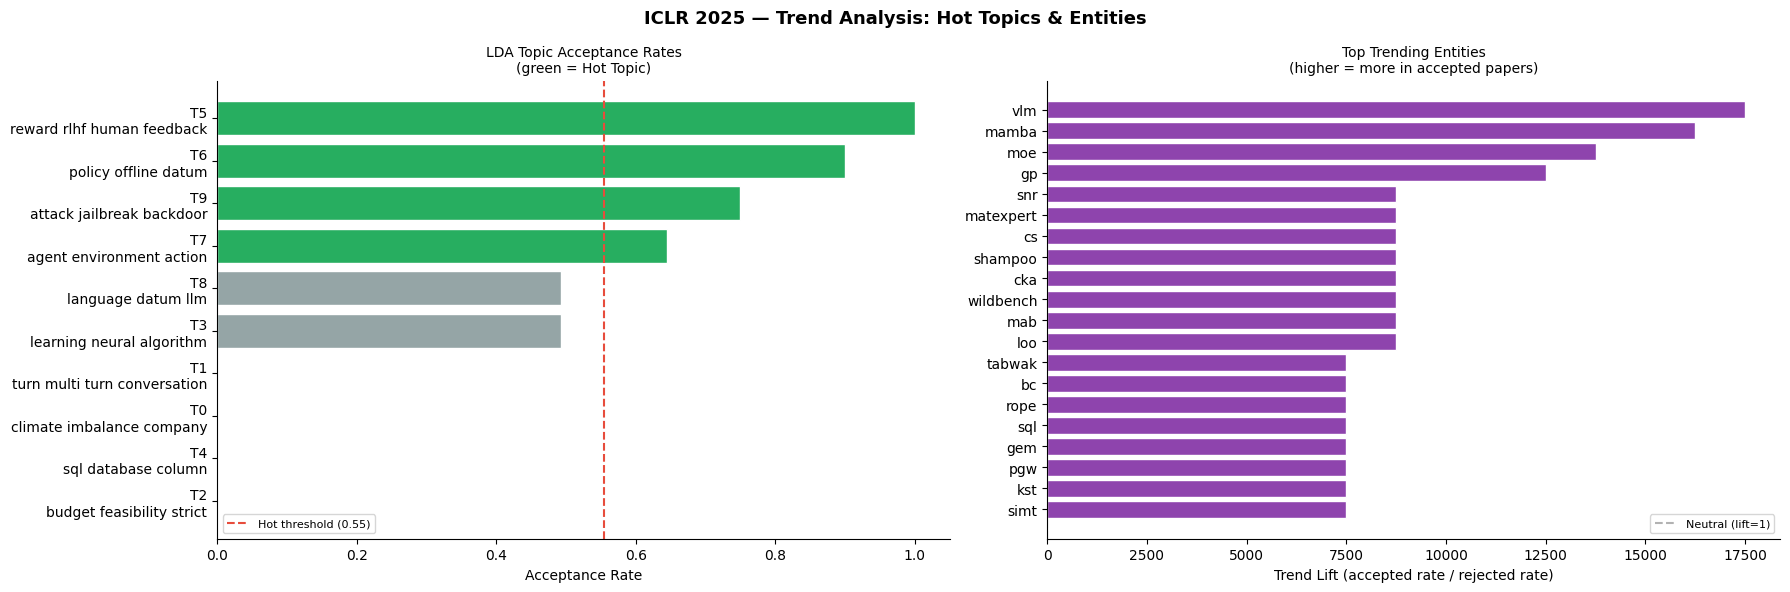

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{CONFERENCE} — Trend Analysis: Hot Topics & Entities', fontsize=13, fontweight='bold')

# Topic acceptance rates
t_labels = [f'T{row.topic_id}\n{" ".join(row.top_words[:3])}' for _, row in topic_df.iterrows()]
bar_colors = ['#27ae60' if row.topic_id in hot_topics else '#95a5a6'
              for _, row in topic_df.iterrows()]
axes[0].barh(t_labels[::-1], topic_df['acceptance_rate'].tolist()[::-1],
             color=bar_colors[::-1], edgecolor='white')
axes[0].axvline(HOT_TOPIC_THRESHOLD, color='#e74c3c', linestyle='--',
                label=f'Hot threshold ({HOT_TOPIC_THRESHOLD:.2f})')
axes[0].set_xlabel('Acceptance Rate')
axes[0].set_title('LDA Topic Acceptance Rates\n(green = Hot Topic)', fontsize=10)
axes[0].legend(fontsize=8); axes[0].spines[['top','right']].set_visible(False)

# Top trending entities
top20 = entity_trend_df.head(20)
axes[1].barh(top20['entity'].tolist()[::-1], top20['trend_lift'].tolist()[::-1],
             color='#8e44ad', edgecolor='white')
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.6, label='Neutral (lift=1)')
axes[1].set_xlabel('Trend Lift (accepted rate / rejected rate)')
axes[1].set_title('Top Trending Entities\n(higher = more in accepted papers)', fontsize=10)
axes[1].legend(fontsize=8); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig(fig, 'iclr2025_trend_analysis.png')
plt.show()

---
## Step 4b — Topic Importance Score per Paper

**Formula:**
$$\text{trend\_score}_i = \sum_{t=0}^{T} p_{i,t} \cdot \text{acceptance\_rate}_t$$

Where $p_{i,t}$ is paper $i$'s weight on LDA topic $t$.  
A high trend score means the paper is concentrated on topics where accepted papers cluster.  
This becomes a new feature column in `iclr2025_labeled_features.parquet`.

In [43]:
# ── Trend score: topic-acceptance-rate weighted topic distribution ─
acc_rates = np.array([topic_stats[t]['acceptance_rate'] for t in range(N_TOPICS)])

# Combine accepted + rejected topic distributions in labeled_df order
# labeled_df order is papers (accepted) first, then rejected_papers
all_dists   = np.vstack([topic_dists, rej_topic_dists])  # (n_acc + n_rej, N_TOPICS)
trend_scores = (all_dists * acc_rates).sum(axis=1)  # dot product per paper
trend_scores = np.round(trend_scores, 5)

# Attach to labeled_df (order must match: accepted first, then rejected)
if len(trend_scores) == len(labeled_df):
    labeled_df['trend_score'] = trend_scores
else:
    print(f'WARNING: length mismatch ({len(trend_scores)} vs {len(labeled_df)}). '
          'Truncating to min.')
    n = min(len(trend_scores), len(labeled_df))
    labeled_df.loc[:n-1, 'trend_score'] = trend_scores[:n]

# Also compute hot_topic_flag (boolean: dominant topic is hot?)
labeled_df['hot_topic_flag'] = labeled_df['dominant_topic_id'].apply(
    lambda t: int(t in hot_topics))

acc_ts = labeled_df[labeled_df['label']==1]['trend_score']
rej_ts = labeled_df[labeled_df['label']==0]['trend_score']
print(f'Trend score — Accepted: mean={acc_ts.mean():.4f}  Rejected: mean={rej_ts.mean():.4f}')
print(f'Hot topic flag — Accepted: {labeled_df[labeled_df["label"]==1]["hot_topic_flag"].mean():.2%} '
      f'Rejected: {labeled_df[labeled_df["label"]==0]["hot_topic_flag"].mean():.2%}')

Trend score — Accepted: mean=0.5141  Rejected: mean=0.5064
Hot topic flag — Accepted: 4.50% Rejected: 1.75%


  [Drive] figure iclr2025_trend_scores.png


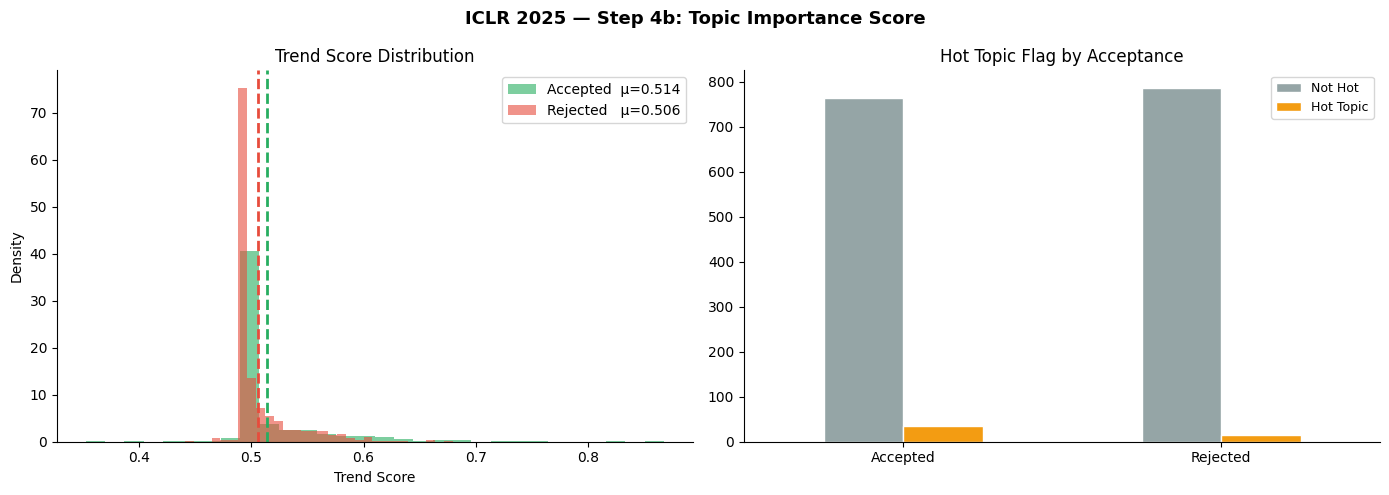

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{CONFERENCE} — Step 4b: Topic Importance Score', fontsize=13, fontweight='bold')

axes[0].hist(acc_ts, bins=30, alpha=0.6, color='#27ae60', density=True,
             label=f'Accepted  μ={acc_ts.mean():.3f}')
axes[0].hist(rej_ts, bins=30, alpha=0.6, color='#e74c3c', density=True,
             label=f'Rejected   μ={rej_ts.mean():.3f}')
axes[0].axvline(acc_ts.mean(), color='#27ae60', linewidth=2, linestyle='--')
axes[0].axvline(rej_ts.mean(), color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_xlabel('Trend Score'); axes[0].set_ylabel('Density')
axes[0].set_title('Trend Score Distribution'); axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

hot_data = labeled_df.groupby(['label_text','hot_topic_flag']).size().unstack(fill_value=0)
hot_data.plot(kind='bar', ax=axes[1], color=['#95a5a6','#f39c12'], edgecolor='white')
axes[1].set_title('Hot Topic Flag by Acceptance'); axes[1].set_xlabel('')
axes[1].set_xticklabels(['Accepted','Rejected'], rotation=0)
axes[1].legend(['Not Hot','Hot Topic'], fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig(fig, 'iclr2025_trend_scores.png')
plt.show()

In [45]:
# ── Save updated labeled features (now includes trend_score) ──────
save_parquet(labeled_df, LABELED_PQ)

# Save trend analysis JSON for FCoT guardrails
trend_analysis = {
    'conference'          : CONFERENCE,
    'topic_stats'         : list(topic_stats.values()),
    'hot_topics'          : sorted(list(hot_topics)),
    'hot_topic_threshold' : round(float(HOT_TOPIC_THRESHOLD), 4),
    'top_trending_entities': entity_trend_df.head(30).to_dict('records'),
    'trend_score_stats'   : {
        'accepted': {'mean': round(acc_ts.mean(),4), 'p50': round(acc_ts.median(),4),
                     'p25': round(acc_ts.quantile(.25),4), 'p75': round(acc_ts.quantile(.75),4)},
        'rejected': {'mean': round(rej_ts.mean(),4), 'p50': round(rej_ts.median(),4)},
    }
}
save_json(trend_analysis, TREND_SCORES)
print('Step 4a/4b complete. Labeled features + trend analysis saved to Drive.')

  [Drive] saved  iclr2025_labeled_features.parquet  (0.2 MB)
  [Drive] saved  trend_scores.json  (0.0 MB)
Step 4a/4b complete. Labeled features + trend analysis saved to Drive.


---
## Gemini FCoT — 3-Iteration Knowledge Graph

Uses `gemini-2.0-flash` with the **Fractal Chain of Thought** prompting strategy (Ch. 9/10).  
Each iteration improves the graph based on Max/Min objective functions and a reflection step.

**You need a `GEMINI_API_KEY` secret in Colab:**  
Runtime → Secrets → Add `GEMINI_API_KEY` (free key from [aistudio.google.com](https://aistudio.google.com))

In [46]:
# ── FCoT Prompt Templates (adapted for research papers) ───────────

SCHEMA_BLOCK = """ALLOWED NODE TYPES:
  FRAMEWORK, PROBLEM, METHOD, DATASET, METRIC, RESULT,
  BASELINE, CLAIM, CONCEPT, TREND, LIMITATION
ALLOWED EDGE TYPES:
  ADDRESSES, PROPOSES, USES, BUILDS_ON, EVALUATED_ON,
  ACHIEVES, OUTPERFORMS, ENABLES, REQUIRES, SUPPORTS,
  CONTRASTS_WITH, GENERALIZES_TO, IMPROVES_BY,
  ALIGNS_WITH, LIMITS, REFLECTS_TREND"""

HOT_TRENDS_STR = ', '.join(HOT_TRENDS)

PROMPT_ITER1 = """You are a Recursive Research Paper Knowledge Architect.

PAPER:
  Title    : {title}
  Abstract : {abstract}
  Keywords : {keywords}

CONFERENCE CONTEXT: {conference}

ITERATION 1 — MACRO-SCALE (The Skeleton)
Focus   : Identify 5-7 core semantic anchors.
          Cover: PROBLEM → FRAMEWORK → METHOD → EVALUATION → RESULT → CLAIM
Action  : Map the primary research arc.
Maximize: Specific edge relationship types (OUTPERFORMS, ACHIEVES not RELATES_TO)
Minimize: Orphan nodes (every node must connect to at least one other)

{schema}

Output ONLY valid JSON with this exact structure (no markdown, no explanation):
{{
  "iteration": 1,
  "nodes": [{{"id": "n0", "label": "...", "type": "FRAMEWORK"}}],
  "edges": [{{"source": "n0", "target": "n1", "relationship": "ADDRESSES"}}],
  "reflection": "What did I miss at this macro level?",
  "semantic_richness": 0.0,
  "entropy_score": 0
}}"""

PROMPT_ITER2 = """ITERATION 2 — MESO-SCALE (The Flesh)

Previous iteration graph:
{prev_json}

Reflection from Iteration 1: {reflection}

HILL CLIMB: Fix what was missed. Improve the graph by:
1. Decomposing each anchor into 3-5 sub-nodes
   (add specific DATASET names, METRIC names, BASELINE names)
2. Adding cross-anchor bridges (hidden relationships between nodes)
3. Connecting any orphan nodes
4. Making relationship types more specific

Maximize: edge-to-node ratio ≥ 1.5, ≥ 3 cross-anchor bridges
Minimize: redundant nodes, orphan nodes = 0

{schema}

Output ONLY valid JSON (no markdown, no explanation) with same structure
plus an \"improvements_made\" field listing what you fixed."""

PROMPT_ITER3 = """ITERATION 3 — MICRO-SCALE (The Atomic) — FINAL

Previous iteration graph:
{prev_json}

Reflection from Iteration 2: {reflection}

HILL CLIMB: Final refinement:
1. Add quantitative values to all RESULT nodes (e.g. \"+23.4%\")
2. Add ≥ 2 TREND nodes from this list, connected via ALIGNS_WITH:
   {hot_trends}
3. Add LIMITATION nodes if the abstract mentions any scope restriction
4. Validate ALL triples: source + target must exist as nodes
5. Remove any node with 0 connections
6. Compute trend_alignment_score = TREND_nodes_present / {n_hot_trends}

Final Objective Functions:
  Maximize Semantic Richness: edge_count / node_count ≥ 1.8
  Minimize Entropy           : orphan_nodes = 0
  Trend Coverage             : ≥ 2 TREND nodes present

{schema}

Output ONLY valid JSON (no markdown) with:
{{
  "iteration": 3,
  "nodes": [...],
  "edges": [...],
  "reflection": "...",
  "semantic_richness": 0.0,
  "entropy_score": 0,
  "trend_alignment_score": 0.0,
  "improvements_made": [...]
}}"""

PROMPT_MERMAID = """Convert this Knowledge Graph JSON to a professional Mermaid flowchart that uses subgraph clusters and varied node shapes — similar to an academic concept map.

STRUCTURE RULES:
1. Use graph TD (top-down layout)
2. Group nodes into labelled subgraph clusters by semantic role:
   - subgraph "Problem Space" — PROBLEM and LIMITATION nodes
   - subgraph "Proposed Approach" — FRAMEWORK and METHOD nodes
   - subgraph "Empirical Evaluation" — DATASET, BASELINE, METRIC, RESULT nodes
   - subgraph "Claims & Insights" — CLAIM, TREND, CONCEPT nodes
   Only include a subgraph if it has ≥ 1 node. Edges between subgraphs are fine.

NODE SHAPE RULES (use EXACTLY these shapes — shape conveys type, so do NOT append the type name to the label):
   FRAMEWORK  → (["Label"])          pill/stadium — the main anchor of the paper
   PROBLEM    → {{"Label"}}            hexagon     — challenge to be solved
   METHOD     → [["Label"]]           subroutine  — process or algorithm
   DATASET    → [/"Label"/]           parallelogram — data input
   RESULT     → (("Label"))           circle      — quantitative outcome
   BASELINE   → ["Label"]             rectangle   — comparison system
   CLAIM      → (["Label"])           pill        — assertion / contribution
   TREND      → {{"Label"}}            hexagon     — research trend
   LIMITATION → ["Label"\]           inv-parallelogram — scope restriction
   CONCEPT    → ("Label")             rounded rect — abstract idea
   METRIC     → [/"Label"/]           parallelogram — evaluation metric

EDGE RULES:
3. Label every edge with its relationship type in UPPER_SNAKE_CASE: A -->|RELATIONSHIP| B
4. Keep edge labels concise (≤ 20 chars)

COLOUR RULES:
5. Add these classDef lines (copy exactly):
    classDef framework fill:#AED6F1,stroke:#2980b9,color:#000
    classDef problem    fill:#F1948A,stroke:#c0392b,color:#000
    classDef method     fill:#C39BD3,stroke:#8e44ad,color:#000
    classDef dataset    fill:#FAD7A0,stroke:#e67e22,color:#000
    classDef result     fill:#A9DFBF,stroke:#27ae60,color:#000
    classDef baseline   fill:#D5D8DC,stroke:#7f8c8d,color:#000
    classDef claim      fill:#A2D9CE,stroke:#1abc9c,color:#000
    classDef trend      fill:#D2B4DE,stroke:#8e44ad,color:#000
    classDef limitation fill:#F5CBA7,stroke:#e67e22,color:#000
    classDef concept    fill:#D5F5E3,stroke:#16a085,color:#000
    classDef metric     fill:#FDEBD0,stroke:#e67e22,color:#000
6. Apply class to EVERY node using :::className (no space before :::)

KG JSON:
{kg_json}

Output ONLY valid Mermaid code — no markdown fences, no explanation."""

print('FCoT prompt templates ready.')

FCoT prompt templates ready.


In [47]:
def fcot_kg(title: str, abstract: str, keywords: str = '') -> dict:
    """
    3-iteration Fractal Chain of Thought KG extraction via Gemini.
    Returns dict with iter1, iter2, iter3 JSON graphs + mermaid markup.
    """
    results = {'title': title, 'iterations': [], 'mermaid': '', 'final_kg': {}}

    # ── Iteration 1: Macro ────────────────────────────────────────
    print('  Iter 1 (Macro)  ...', end=' ')
    p1 = PROMPT_ITER1.format(title=title, abstract=abstract[:1200],
                              keywords=keywords, conference=CONFERENCE,
                              schema=SCHEMA_BLOCK)
    r1_raw = call_gemini(p1)
    try:
        r1 = parse_json(r1_raw)
        n1, e1 = len(r1.get('nodes',[])), len(r1.get('edges',[]))
        r1['semantic_richness'] = round(e1/max(n1,1), 3)
        print(f'nodes={n1} edges={e1} richness={r1["semantic_richness"]}')
    except json.JSONDecodeError as exc:
        print(f'JSON parse error: {exc}'); r1 = {'nodes':[],'edges':[],'reflection':'parse error'}
    results['iterations'].append(r1)
    time.sleep(CALL_DELAY)

    # ── Iteration 2: Meso ─────────────────────────────────────────
    print('  Iter 2 (Meso)   ...', end=' ')
    p2 = PROMPT_ITER2.format(prev_json=json.dumps(r1, indent=2)[:3000],
                              reflection=r1.get('reflection',''),
                              schema=SCHEMA_BLOCK)
    r2_raw = call_gemini(p2)
    try:
        r2 = parse_json(r2_raw)
        n2, e2 = len(r2.get('nodes',[])), len(r2.get('edges',[]))
        r2['semantic_richness'] = round(e2/max(n2,1), 3)
        print(f'nodes={n2} edges={e2} richness={r2["semantic_richness"]}')
    except json.JSONDecodeError as exc:
        print(f'JSON parse error: {exc}'); r2 = r1
    results['iterations'].append(r2)
    time.sleep(CALL_DELAY)

    # ── Iteration 3: Micro ────────────────────────────────────────
    print('  Iter 3 (Micro)  ...', end=' ')
    p3 = PROMPT_ITER3.format(prev_json=json.dumps(r2, indent=2)[:3000],
                              reflection=r2.get('reflection',''),
                              hot_trends=HOT_TRENDS_STR,
                              n_hot_trends=len(HOT_TRENDS),
                              schema=SCHEMA_BLOCK)
    r3_raw = call_gemini(p3)
    try:
        r3 = parse_json(r3_raw)
        n3, e3 = len(r3.get('nodes',[])), len(r3.get('edges',[]))
        r3['semantic_richness'] = round(e3/max(n3,1), 3)
        # Recompute trend_alignment_score in Python (don't trust Gemini self-report)
        trend_labels = {n['label'].lower() for n in r3.get('nodes',[]) if n.get('type')=='TREND'}
        hot_set      = {t.lower() for t in HOT_TRENDS}
        r3['trend_alignment_score'] = round(len(trend_labels & hot_set)/max(len(HOT_TRENDS),1), 4)
        r3['matched_trends']        = sorted(trend_labels & hot_set)
        r3['n_limitations']         = sum(1 for n in r3.get('nodes',[]) if n.get('type')=='LIMITATION')
        r3['n_baselines']           = sum(1 for n in r3.get('nodes',[]) if n.get('type')=='BASELINE')
        r3['n_results']             = sum(1 for n in r3.get('nodes',[]) if n.get('type')=='RESULT')
        print(f'nodes={n3} edges={e3} richness={r3["semantic_richness"]} '
              f'trend_align={r3["trend_alignment_score"]} '
              f'limits={r3["n_limitations"]} baselines={r3["n_baselines"]}')
    except json.JSONDecodeError as exc:
        print(f'JSON parse error: {exc}'); r3 = r2
    results['iterations'].append(r3)
    results['final_kg'] = r3
    time.sleep(CALL_DELAY)

    # ── Mermaid ───────────────────────────────────────────────────
    print('  Mermaid         ...', end=' ')
    pm = PROMPT_MERMAID.format(kg_json=json.dumps(r3, indent=2)[:3000])
    mmd_raw = call_gemini(pm)
    mmd = re.sub(r'^```[a-zA-Z]*\n?','',mmd_raw.strip())
    mmd = re.sub(r'\n?```$','',mmd.strip())
    results['mermaid'] = mmd
    print('done.')
    time.sleep(CALL_DELAY)

    return results

print('fcot_kg() function ready.')

fcot_kg() function ready.


In [48]:
# ── Drive-first: load FCoT results if already cached ─────────────
# First run  → calls Gemini (~12 API calls), saves to Drive
# Warm runs  → loads JSON from Drive, zero Gemini calls

if drive_has(FCOT_CACHE):
    print(f'[Drive] FCoT cache found — loading (no Gemini calls needed).')
    _cached     = load_json(FCOT_CACHE)
    fcot_results = _cached.get('results', [])
    print(f'  Loaded {len(fcot_results)} FCoT KG results from Drive.')
    # Recompute KG quality scores from cached node data (no Gemini call)
    hot_set = {t.lower() for t in HOT_TRENDS}
    for i, r in enumerate(fcot_results):
        fkg = r.get('final_kg', {})
        nodes = fkg.get('nodes', [])
        trend_labels = {n['label'].lower() for n in nodes if n.get('type')=='TREND'}
        fkg['trend_alignment_score'] = round(len(trend_labels & hot_set)/max(len(HOT_TRENDS),1), 4)
        fkg['matched_trends']        = sorted(trend_labels & hot_set)
        fkg['n_limitations']         = sum(1 for n in nodes if n.get('type')=='LIMITATION')
        fkg['n_baselines']           = sum(1 for n in nodes if n.get('type')=='BASELINE')
        fkg['n_results']             = sum(1 for n in nodes if n.get('type')=='RESULT')
        print(f'  P{i+1} [{r["overlap_category"].upper():6s}] '
              f'nodes={len(nodes)}  '
              f'edges={len(fkg.get("edges",[]))}  '
              f'richness={fkg.get("semantic_richness",0)}  '
              f'trend_align={fkg["trend_alignment_score"]}  '
              f'limits={fkg["n_limitations"]} baselines={fkg["n_baselines"]}')

elif GEMINI_MODEL_ACTIVE is None:
    print('Gemini unavailable and no Drive cache found.')
    print('Fix the API key (re-run kg-gemini-setup) and retry this cell.')
    fcot_results = []

else:
    # ── Select curated papers ─────────────────────────────────────
    curated_pq = DRIVE_FEATURES / 'iclr2025_curated_papers.parquet'
    if drive_has(curated_pq):
        curated_df   = load_parquet(curated_pq)
        sample_papers = curated_df[['title','abstract','paper_keywords',
                                     'overlap_category']].to_dict('records')
        print(f'Loaded {len(sample_papers)} curated papers for FCoT.')
    else:
        sample_papers = [
            {**p, 'overlap_category': 'high',
             'paper_keywords': ', '.join(p.get('keywords',[]))}
            for p in papers[:2]
        ] + [
            {**p, 'overlap_category': 'medium',
             'paper_keywords': ', '.join(p.get('keywords',[]))}
            for p in papers[len(papers)//2:len(papers)//2+1]
        ] + [
            {**p, 'overlap_category': 'low',
             'paper_keywords': ', '.join(p.get('keywords',[]))}
            for p in papers[-1:]
        ]

    # ── Run FCoT (Gemini API calls happen here) ───────────────────
    print(f'Running FCoT via {GEMINI_MODEL_ACTIVE} '
          f'({len(sample_papers)} papers × ~3 calls each) ...')
    fcot_results = []
    for i, sp in enumerate(sample_papers):
        print(f'\n[{i+1}/{len(sample_papers)}] '
              f'{sp["overlap_category"].upper()} — {sp["title"][:60]}')
        result = fcot_kg(
            title    = sp['title'],
            abstract = sp['abstract'],
            keywords = sp.get('paper_keywords', '')
        )
        result['overlap_category'] = sp['overlap_category']
        fcot_results.append(result)
        fkg = result['final_kg']
        print(f'  nodes={len(fkg.get("nodes",[]))}  '
              f'edges={len(fkg.get("edges",[]))}  '
              f'richness={fkg.get("semantic_richness",0)}')

    # ── Save consolidated cache immediately ───────────────────────
    save_json({'model': GEMINI_MODEL_ACTIVE,
               'n_papers': len(fcot_results),
               'results': fcot_results}, FCOT_CACHE)
    print(f'\nFCoT complete. Cache saved → {FCOT_CACHE.name}')
    print('Future runs will load from Drive — no Gemini calls needed.')


[Drive] FCoT cache found — loading (no Gemini calls needed).
  Loaded 4 FCoT KG results from Drive.
  P1 [HIGH  ] nodes=35  edges=103  richness=2.943  trend_align=0.25  limits=3 baselines=1
  P2 [HIGH  ] nodes=26  edges=49  richness=1.885  trend_align=0.1667  limits=0 baselines=3
  P3 [MEDIUM] nodes=35  edges=76  richness=2.171  trend_align=0.1667  limits=4 baselines=1
  P4 [LOW   ] nodes=32  edges=77  richness=2.406  trend_align=0.1667  limits=2 baselines=2


In [49]:
# ── Display KG summary + Mermaid for each paper ──────────────────
for i, res in enumerate(fcot_results):
    fkg = res['final_kg']
    n_nodes     = len(fkg.get('nodes', []))
    n_edges     = len(fkg.get('edges', []))
    richness    = fkg.get('semantic_richness', round(n_edges/max(n_nodes,1), 3))
    trend_align = fkg.get('trend_alignment_score', 0)
    entropy     = fkg.get('entropy_score', 0)

    print(f"{'='*72}")
    print(f"Paper {i+1} [{res['overlap_category'].upper()}]")
    print(f"Title     : {res['title'][:70]}")
    print(f"Nodes     : {n_nodes}   Edges: {n_edges}   "
          f"Semantic Richness: {richness}   Entropy: {entropy}")
    print(f"Trend Alignment: {trend_align:.2f}   "
          f"({'HOT' if trend_align >= 0.3 else 'MODERATE' if trend_align >= 0.15 else 'COLD'})")

    trend_nodes = [n['label'] for n in fkg.get('nodes', []) if n.get('type') == 'TREND']
    print(f"TREND nodes: {trend_nodes}")

    print(f"\n── Mermaid Markup (paste at mermaid.live) ──")
    print(res['mermaid'][:1500])
    if len(res['mermaid']) > 1500:
        print(f'  ... ({len(res["mermaid"])} chars total, truncated for display)')
    print()

Paper 1 [HIGH]
Title     : Agent-Oriented Planning in Multi-Agent Systems
Nodes     : 35   Edges: 103   Semantic Richness: 2.943   Entropy: 0
Trend Alignment: 0.25   (MODERATE)
TREND nodes: ['Multi-Agent Systems', 'Autonomous Planning', 'Self-Improving Systems']

── Mermaid Markup (paste at mermaid.live) ──
graph TD
    classDef framework fill:#AED6F1,stroke:#2980b9,color:#000
    classDef problem    fill:#F1948A,stroke:#c0392b,color:#000
    classDef method     fill:#C39BD3,stroke:#8e44ad,color:#000
    classDef dataset    fill:#FAD7A0,stroke:#e67e22,color:#000
    classDef result     fill:#A9DFBF,stroke:#27ae60,color:#000
    classDef baseline   fill:#D5D8DC,stroke:#7f8c8d,color:#000
    classDef claim      fill:#A2D9CE,stroke:#1abc9c,color:#000
    classDef trend      fill:#D2B4DE,stroke:#8e44ad,color:#000
    classDef limitation fill:#F5CBA7,stroke:#e67e22,color:#000
    classDef concept    fill:#D5F5E3,stroke:#16a085,color:#000
    classDef metric     fill:#FDEBD0,stroke:#e67e22,c

---
## Knowledge Graph Visualisations (Mermaid)

Renders all FCoT Knowledge Graphs inline. On a **warm run** (cache exists on Drive) this loads instantly — no Gemini API calls needed.

> If a diagram does not render (Colab sometimes blocks CDN scripts), copy the printed Mermaid source and paste it at **mermaid.live**.

In [50]:
# ── Re-generate Mermaid with updated prompt (style refresh) ─────
# Run this once after changing PROMPT_MERMAID to regenerate diagrams
# without re-running the full 3-iteration FCoT (no Gemini cost for iter 1-3).

_regen_mermaid = True   # set False to skip

if _regen_mermaid:
    if 'fcot_results' not in dir() or not fcot_results:
        if drive_has(FCOT_CACHE):
            _c = load_json(FCOT_CACHE)
            fcot_results = _c.get('results', [])
            print(f"[Drive] Loaded {len(fcot_results)} cached FCoT results.")
        else:
            fcot_results = []
            print("No cached results — run kg-fcot-run first.")

    for res in fcot_results:
        r3 = res.get('final_kg', {})
        if not r3:
            continue
        print(f"  Re-rendering Mermaid for: {res['title'][:60]}")
        pm = PROMPT_MERMAID.format(kg_json=json.dumps(r3, indent=2)[:3000])
        mmd_raw = call_gemini(pm)
        mmd = re.sub(r'^```[a-zA-Z]*\n?', '', mmd_raw.strip())
        mmd = re.sub(r'\n?```$', '', mmd.strip())
        res['mermaid'] = mmd
        time.sleep(CALL_DELAY)

    # Persist updated cache to Drive
    if fcot_results:
        existing = load_json(FCOT_CACHE) if drive_has(FCOT_CACHE) else {}
        existing['results'] = fcot_results
        save_json(existing, FCOT_CACHE)
        print(f"[Drive] Updated cache saved with new Mermaid diagrams.")
else:
    print("Mermaid re-generation skipped (_regen_mermaid=False).")

  Re-rendering Mermaid for: Agent-Oriented Planning in Multi-Agent Systems
  Re-rendering Mermaid for: Constraint-Conditioned Actor-Critic for Offline Safe Reinfor
  Re-rendering Mermaid for: Improving the Sparse Structure Learning of Spiking Neural Ne
  Re-rendering Mermaid for: Sensitivity-Constrained Fourier Neural Operators for Forward
  [Drive] saved  fcot_results_cache.json  (0.2 MB)
[Drive] Updated cache saved with new Mermaid diagrams.


In [51]:
# ── Render FCoT KGs inline + save PNGs to Drive ─────────────────
# Uses mermaid.ink API (free, no auth, no npm) to generate PNGs.

import base64
import re as _re
from IPython.display import HTML, Image, display as _display


def mermaid_to_png_bytes(mermaid_code: str) -> bytes:
    """Convert Mermaid markup to PNG via mermaid.ink (free public API)."""
    # mermaid.ink expects base64url-encoded Mermaid source
    encoded = base64.urlsafe_b64encode(mermaid_code.encode('utf-8')).decode()
    url     = f'https://mermaid.ink/img/{encoded}?type=png&width=1200'
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.content


def render_mermaid_html(mermaid_code: str, title: str = '',
                        category: str = '', height: int = 620) -> HTML:
    """Render Mermaid inline in Colab using mermaid.js v10."""
    icon  = {'high': '🟢', 'medium': '🟡', 'low': '🔴'}.get(category, '⚪')
    label = f'{icon} [{category.upper()}] — {title[:70]}' if title else ''
    html  = f"""
    <div style="margin:12px 0; font-family:sans-serif">
      <h4 style="margin:0 0 8px 0; font-size:13px; color:#2c3e50">{label}</h4>
      <div style="border:1px solid #ddd; border-radius:8px; padding:16px;
                  background:#fafafa; min-height:{height}px; overflow:auto">
        <pre class="mermaid" style="font-size:11px">{mermaid_code}</pre>
      </div>
    </div>
    <script type="module">
      import mermaid from
        'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
      mermaid.initialize({{
        startOnLoad : true,
        theme       : 'default',
        flowchart   : {{ curve: 'basis', padding: 20, nodeSpacing: 40 }}
      }});
    </script>
    """
    return HTML(html)



# ── Sanitize Mermaid: inject missing classDef entries ────────────
_FALLBACK_COLORS = {
    'concept': '#16a085', 'metric': '#e67e22', 'trend': '#8e44ad',
    'limitation': '#c0392b', 'claim': '#1abc9c',
}

def sanitize_mermaid(mmd: str) -> str:
    """Inject missing classDef entries for any :::class used but not defined."""
    import re as _re2
    _FALLBACK = {
        'concept': '#16a085', 'metric': '#e67e22', 'trend': '#8e44ad',
        'limitation': '#c0392b', 'claim': '#1abc9c',
    }
    used    = set(_re2.findall(r':::\s*(\w+)', mmd))
    defined = set(_re2.findall(r'classDef\s+(\w+)', mmd))
    missing = used - defined
    if not missing:
        return mmd
    extras = '\n'.join(
        f'    classDef {cls} fill:{_FALLBACK.get(cls, "#95a5a6")}'
        for cls in sorted(missing)
    )
    return mmd.rstrip() + '\n' + extras


# ── Load source ───────────────────────────────────────────────────
if 'fcot_results' in dir() and fcot_results:
    _source = fcot_results
    print(f'Rendering {len(_source)} KGs from this session.')
elif drive_has(FCOT_CACHE):
    _cache  = load_json(FCOT_CACHE)
    _source = _cache.get('results', [])
    print(f'[Drive] Rendering {len(_source)} KGs from cache '
          f'(model: {_cache.get("model","?")}). No Gemini calls needed.')
else:
    _source = []
    print('No FCoT results found — run kg-fcot-run first.')

# ── Render + save each paper ──────────────────────────────────────
saved_pngs = []

for i, res in enumerate(_source, 1):
    title    = res.get('title', f'Paper {i}')
    category = res.get('overlap_category', '?')
    mmd      = res.get('mermaid', '').strip()
    fkg      = res.get('final_kg', {})
    n_nodes  = len(fkg.get('nodes', []))
    n_edges  = len(fkg.get('edges', []))
    richness = fkg.get('semantic_richness', round(n_edges/max(n_nodes,1), 3))
    trend_al = fkg.get('trend_alignment_score', '—')
    icon     = {'high':'🟢','medium':'🟡','low':'🔴'}.get(category,'⚪')

    print(f'\n{"-"*68}')
    print(f'Paper {i}  {icon}  [{category.upper()}]')
    print(f'Title    : {title[:70]}')
    print(f'KG stats : nodes={n_nodes}  edges={n_edges}  '
          f'richness={richness}  trend_align={trend_al}')

    if not mmd:
        print('  ⚠ No Mermaid markup — skipping.')
        continue

    # ── 1. Render inline (HTML/JS) ────────────────────────────────
    _display(render_mermaid_html(sanitize_mermaid(mmd), title=title, category=category))

    # ── 2. Save PNG to Drive via mermaid.ink ─────────────────────
    slug     = _re.sub(r'[^a-z0-9]+', '_', title[:35].lower()).strip('_')
    png_name = f'paper_{i}_{category}_{slug}_kg.png'
    png_path = DRIVE_FIGURES / png_name

    if drive_has(png_path):
        print(f'  [Drive] PNG already exists → {png_name}')
        saved_pngs.append(str(png_path))
    else:
        try:
            print(f'  Saving PNG via mermaid.ink ...', end=' ', flush=True)
            png_bytes = mermaid_to_png_bytes(sanitize_mermaid(mmd))
            with open(png_path, 'wb') as fh:
                fh.write(png_bytes)
            size_kb = len(png_bytes) / 1024
            print(f'saved ({size_kb:.0f} KB) → {png_name}')
            saved_pngs.append(str(png_path))
            # Also display the saved PNG (confirms it rendered correctly)
            _display(Image(png_bytes, width=900))
        except Exception as exc:
            print(f'FAILED: {exc}')
            print(f'  Mermaid source below — paste at mermaid.live to export manually:')
            print(mmd[:800])

print(f'\n{"-"*68}')
print(f'Done. {len(saved_pngs)}/{len(_source)} PNGs saved to Drive/figures/')
for p in saved_pngs:
    print(f'  {Path(p).name}')


Rendering 4 KGs from this session.

--------------------------------------------------------------------
Paper 1  🟢  [HIGH]
Title    : Agent-Oriented Planning in Multi-Agent Systems
KG stats : nodes=35  edges=103  richness=2.943  trend_align=0.25


  [Drive] PNG already exists → paper_1_high_agent_oriented_planning_in_multi_ag_kg.png

--------------------------------------------------------------------
Paper 2  🟢  [HIGH]
Title    : Constraint-Conditioned Actor-Critic for Offline Safe Reinforcement Lea
KG stats : nodes=26  edges=49  richness=1.885  trend_align=0.1667


  [Drive] PNG already exists → paper_2_high_constraint_conditioned_actor_critic_kg.png

--------------------------------------------------------------------
Paper 3  🟡  [MEDIUM]
Title    : Improving the Sparse Structure Learning of Spiking Neural Networks fro
KG stats : nodes=35  edges=76  richness=2.171  trend_align=0.1667


  [Drive] PNG already exists → paper_3_medium_improving_the_sparse_structure_lear_kg.png

--------------------------------------------------------------------
Paper 4  🔴  [LOW]
Title    : Sensitivity-Constrained Fourier Neural Operators for Forward and Inver
KG stats : nodes=32  edges=77  richness=2.406  trend_align=0.1667


  [Drive] PNG already exists → paper_4_low_sensitivity_constrained_fourier_neu_kg.png

--------------------------------------------------------------------
Done. 4/4 PNGs saved to Drive/figures/
  paper_1_high_agent_oriented_planning_in_multi_ag_kg.png
  paper_2_high_constraint_conditioned_actor_critic_kg.png
  paper_3_medium_improving_the_sparse_structure_lear_kg.png
  paper_4_low_sensitivity_constrained_fourier_neu_kg.png


  [Drive] figure iclr2025_fcot_hill_climb.png


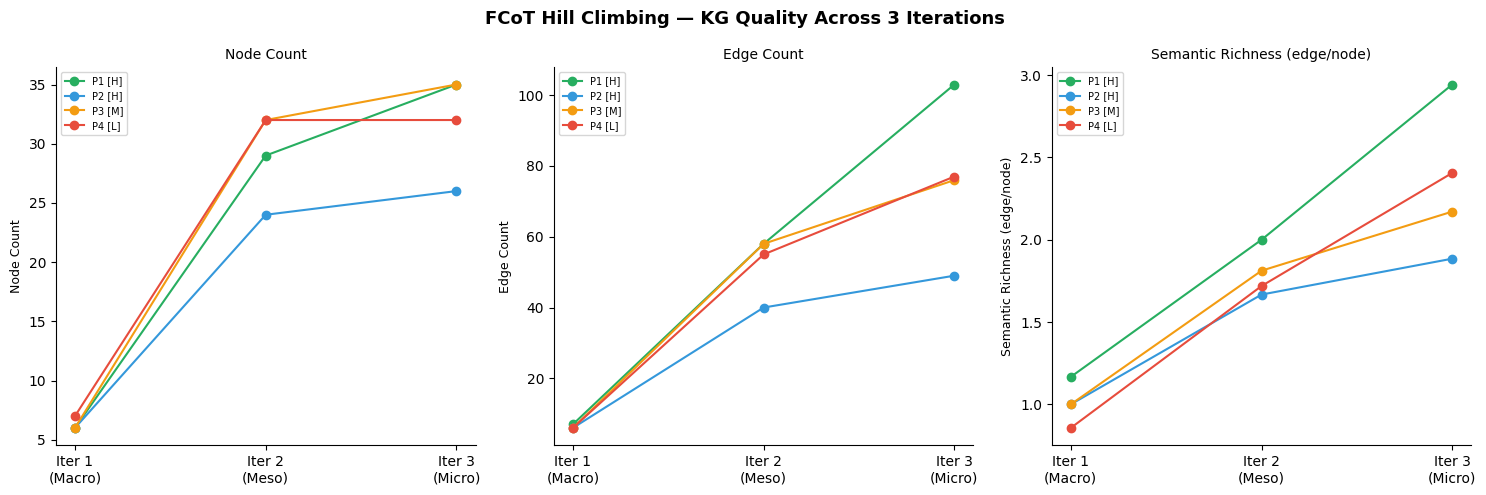

In [52]:
if not fcot_results:
    print('No FCoT results to plot — skipping iteration comparison.')
else:
    # ── Visualise how KG improves across 3 iterations ────────────────
    if fcot_results:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle('FCoT Hill Climbing — KG Quality Across 3 Iterations',
                      fontsize=13, fontweight='bold')

        metrics = ['node_count', 'edge_count', 'semantic_richness']
        ylabels = ['Node Count', 'Edge Count', 'Semantic Richness (edge/node)']

        for ax, metric, ylabel in zip(axes, metrics, ylabels):
            for j, res in enumerate(fcot_results):
                vals = []
                for it in res['iterations']:
                    n = len(it.get('nodes', []))
                    e = len(it.get('edges', []))
                    if metric == 'node_count':        vals.append(n)
                    elif metric == 'edge_count':       vals.append(e)
                    elif metric == 'semantic_richness':vals.append(round(e/max(n,1),3))
                color = ['#27ae60','#3498db','#f39c12','#e74c3c'][j % 4]
                ax.plot([1,2,3], vals, marker='o', color=color,
                        label=f'P{j+1} [{res["overlap_category"][0].upper()}]')
            ax.set_xticks([1,2,3])
            ax.set_xticklabels(['Iter 1\n(Macro)','Iter 2\n(Meso)','Iter 3\n(Micro)'])
            ax.set_ylabel(ylabel, fontsize=9)
            ax.set_title(ylabel, fontsize=10)
            ax.legend(fontsize=7)
            ax.spines[['top','right']].set_visible(False)

        plt.tight_layout()
        save_fig(fig, 'iclr2025_fcot_hill_climb.png')
        plt.show()

In [53]:
if not fcot_results:
    print('No FCoT KG outputs to save.')
else:
    # ── Individual paper KG files (JSON + Mermaid) ────────────────
    for i, res in enumerate(fcot_results):
        slug     = re.sub(r'[^a-z0-9]+', '_',
                          res['title'][:40].lower()).strip('_')
        cat      = res['overlap_category']
        kg_path  = DRIVE_KG / f'paper_{i+1}_{cat}_{slug}_kg.json'
        mmd_path = DRIVE_KG / f'paper_{i+1}_{cat}_{slug}_kg.mmd'

        save_json({
            'title'           : res['title'],
            'overlap_category': cat,
            'fcot_iterations' : res['iterations'],
            'final_kg'        : res['final_kg'],
            'mermaid'         : res['mermaid'],
        }, kg_path)

        with open(mmd_path, 'w') as f: f.write(res['mermaid'])
        print(f'  [Drive] {mmd_path.name}')

    # ── Consolidated summary ──────────────────────────────────────
    save_json({
        'conference'       : CONFERENCE,
        'corpus_kg'        : corpus_kg_summary,
        'trend_analysis'   : trend_analysis,
        'fcot_kg_summaries': [
            {'title': r['title'],
             'overlap_category': r['overlap_category'],
             'model_used': r.get('model', GEMINI_MODEL_ACTIVE),
             'final_node_count': len(r['final_kg'].get('nodes',[])),
             'final_edge_count': len(r['final_kg'].get('edges',[])),
             'semantic_richness': r['final_kg'].get('semantic_richness',0),
             'trend_alignment_score': r['final_kg'].get('trend_alignment_score',0)}
            for r in fcot_results
        ]
    }, DRIVE_ANALYSIS / 'kg_trend_summary.json')

    # ── Confirm cache exists (written by kg-fcot-run) ─────────────
    if drive_has(FCOT_CACHE):
        print(f'\n[Drive] FCoT cache confirmed: {FCOT_CACHE.name}')
    else:
        # Shouldn't happen, but write it here as fallback
        save_json({'model': GEMINI_MODEL_ACTIVE,
                   'n_papers': len(fcot_results),
                   'results': fcot_results}, FCOT_CACHE)

    print(f'\nAll outputs saved → {DRIVE_KG}')
    print(f'Next run: loads from Drive, skips all Gemini API calls.')


  [Drive] saved  paper_1_high_agent_oriented_planning_in_multi_agent_s_kg.json  (0.1 MB)
  [Drive] paper_1_high_agent_oriented_planning_in_multi_agent_s_kg.mmd
  [Drive] saved  paper_2_high_constraint_conditioned_actor_critic_for_kg.json  (0.0 MB)
  [Drive] paper_2_high_constraint_conditioned_actor_critic_for_kg.mmd
  [Drive] saved  paper_3_medium_improving_the_sparse_structure_learning_kg.json  (0.0 MB)
  [Drive] paper_3_medium_improving_the_sparse_structure_learning_kg.mmd
  [Drive] saved  paper_4_low_sensitivity_constrained_fourier_neural_o_kg.json  (0.0 MB)
  [Drive] paper_4_low_sensitivity_constrained_fourier_neural_o_kg.mmd
  [Drive] saved  kg_trend_summary.json  (0.4 MB)

[Drive] FCoT cache confirmed: fcot_results_cache.json

All outputs saved → /content/drive/MyDrive/CMPE257_ICLR2025/kg
Next run: loads from Drive, skips all Gemini API calls.


---
## Summary

### Outputs written to Drive

| File | Contents |
|------|----------|
| `analysis/corpus_kg_summary.json` | Aggregate entity/KG stats for all 1,600 papers |
| `analysis/trend_scores.json` | Topic acceptance rates, hot topics, trending entities |
| `analysis/kg_trend_summary.json` | FCoT KG scores per curated paper |
| `features/iclr2025_labeled_features.parquet` | **Updated** — now includes `trend_score` + `hot_topic_flag` |
| `kg/paper_N_*.json` | Full FCoT KG (3 iterations) per curated paper |
| `kg/paper_N_*.mmd` | Mermaid markup — paste at mermaid.live |
| `figures/iclr2025_kg_fingerprint.png` | KG corpus statistics |
| `figures/iclr2025_trend_analysis.png` | Hot topics + trending entities |
| `figures/iclr2025_trend_scores.png` | Trend score distributions |
| `figures/iclr2025_fcot_hill_climb.png` | FCoT iteration improvement curves |

### Features added to labeled dataset

| Feature | Description | Use in predictor |
|---------|-------------|------------------|
| `trend_score` | Σ(topic_weight × topic_acceptance_rate) | Direct acceptance signal |
| `hot_topic_flag` | 1 if dominant topic is in hot zone | Binary feature |

### What feeds the Acceptance Predictor (Notebook 3)

```
iclr2025_labeled_features.parquet  ← 20 NLP features + trend_score + hot_topic_flag
iclr2025_gold_standard_ranges.json ← percentile guardrails for FCoT judge prompt
analysis/trend_scores.json         ← hot topic context for LLM judge
kg/paper_N_*.json                  ← KG structure for graph similarity scoring
```

**Next:** `ICLR2025_Acceptance_Predictor.ipynb` — Step 5a/5b: fetch 2 Arxiv papers, run the full pipeline, output P(acceptance) + improvement report.

---
# Phase 4 — Acceptance Predictor & Improvement Suggester

Uses labeled features (with trend_score) produced above.

In [54]:
# ── Bridge: aliases + feature-set update after trend_score is computed ──
cv_model = cv   # NB3 predictor uses cv_model; NB1/NB2 built it as cv

labeled_df = load_parquet(LABELED_PQ)
gold_ranges = load_json(GOLD_JSON)
trend_data  = load_json(TREND_JSON) if drive_has(TREND_JSON) else {}
lda_for_pred = lda           # alias used inside AcceptancePredictor
vocab_pred   = cv_model.get_feature_names_out()

if 'trend_score' in labeled_df.columns and 'trend_score' not in FEATURE_COLS:
    FEATURE_COLS.append('trend_score')
if 'hot_topic_flag' in labeled_df.columns and 'hot_topic_flag' not in FEATURE_COLS:
    FEATURE_COLS.append('hot_topic_flag')
FEATURE_COLS = [c for c in FEATURE_COLS if c in labeled_df.columns]

print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Trend score available: {"trend_score" in FEATURE_COLS}')

Feature columns (21): ['rshow', 'noun_to_verb_ratio', 'adjective_density', 'dominant_topic_weight', 'topic_entropy', 'coverage_score', 'abstract_sentence_count', 'abstract_word_count', 'total_entities', 'unique_entities', 'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'type_token_ratio', 'technical_term_ratio', 'avg_sentence_length', 'n_authors', 'n_keywords', 'agentic_score', 'trend_score', 'hot_topic_flag']
Trend score available: True


---
## Part 1 — Traditional NLP Model (XGBoost)

Phase I + Phase II features from the professor's framework go into an XGBoost classifier.
Probabilities are calibrated with isotonic regression so the output is a real probability, not a raw score.

In [55]:
X = labeled_df[FEATURE_COLS].fillna(0).values
y = labeled_df['label'].values

print(f'X shape : {X.shape}   (samples × features)')
print(f'y distribution: accepted={y.sum()}  rejected={len(y)-y.sum()}')

# Class imbalance weight
n_pos = y.sum()
n_neg = len(y) - n_pos
scale_pos_weight = n_neg / max(n_pos, 1)
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Feature summary by class
feat_df = labeled_df[FEATURE_COLS + ['label_text']].copy()
display(feat_df.groupby('label_text').mean().round(3).T
        .rename(columns={'accepted':'Accepted mean','rejected':'Rejected mean'})
        .assign(delta=lambda d: d['Accepted mean'] - d['Rejected mean'])
        .sort_values('delta', ascending=False))

X shape : (1600, 21)   (samples × features)
y distribution: accepted=800  rejected=800
scale_pos_weight: 1.00


label_text,Accepted mean,Rejected mean,delta
abstract_word_count,201.444,193.650,7.794
n_authors,5.646,4.660,0.986
agentic_score,2.664,1.798,0.866
avg_sentence_length,24.967,24.314,0.653
total_entities,7.456,6.922,0.534
n_keywords,4.080,3.579,0.501
unique_entities,5.684,5.196,0.488
gunning_fog,20.246,19.789,0.457
flesch_kincaid_grade,17.040,16.686,0.354
dominant_topic_weight,0.815,0.744,0.071


In [56]:
if drive_has(XGB_PATH):
    print('[Drive] Loading trained model — skipping refit.')
    calibrated_model = load_model(XGB_PATH)
    # Still run CV for reporting
    base_xgb = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42, verbosity=0)
else:
    print('Training XGBoost + isotonic calibration ...')
    base_xgb = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42, verbosity=0)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    calibrated_model = CalibratedClassifierCV(
        base_xgb, cv=skf, method='isotonic')
    calibrated_model.fit(X, y)
    save_model(calibrated_model, XGB_PATH)

# ── Cross-validation metrics ──────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    base_xgb, X, y, cv=skf,
    scoring=['roc_auc','average_precision','accuracy'],
    n_jobs=-1)

print(f'\n5-Fold Cross-Validation Results:')
print(f'  ROC-AUC            : {cv_scores["test_roc_auc"].mean():.3f} ± {cv_scores["test_roc_auc"].std():.3f}')
print(f'  Average Precision  : {cv_scores["test_average_precision"].mean():.3f} ± {cv_scores["test_average_precision"].std():.3f}')
print(f'  Accuracy           : {cv_scores["test_accuracy"].mean():.3f} ± {cv_scores["test_accuracy"].std():.3f}')

[Drive] Loading trained model — skipping refit.

5-Fold Cross-Validation Results:
  ROC-AUC            : 0.731 ± 0.024
  Average Precision  : 0.748 ± 0.024
  Accuracy           : 0.674 ± 0.028


  [Drive] figure iclr2025_model_evaluation.png


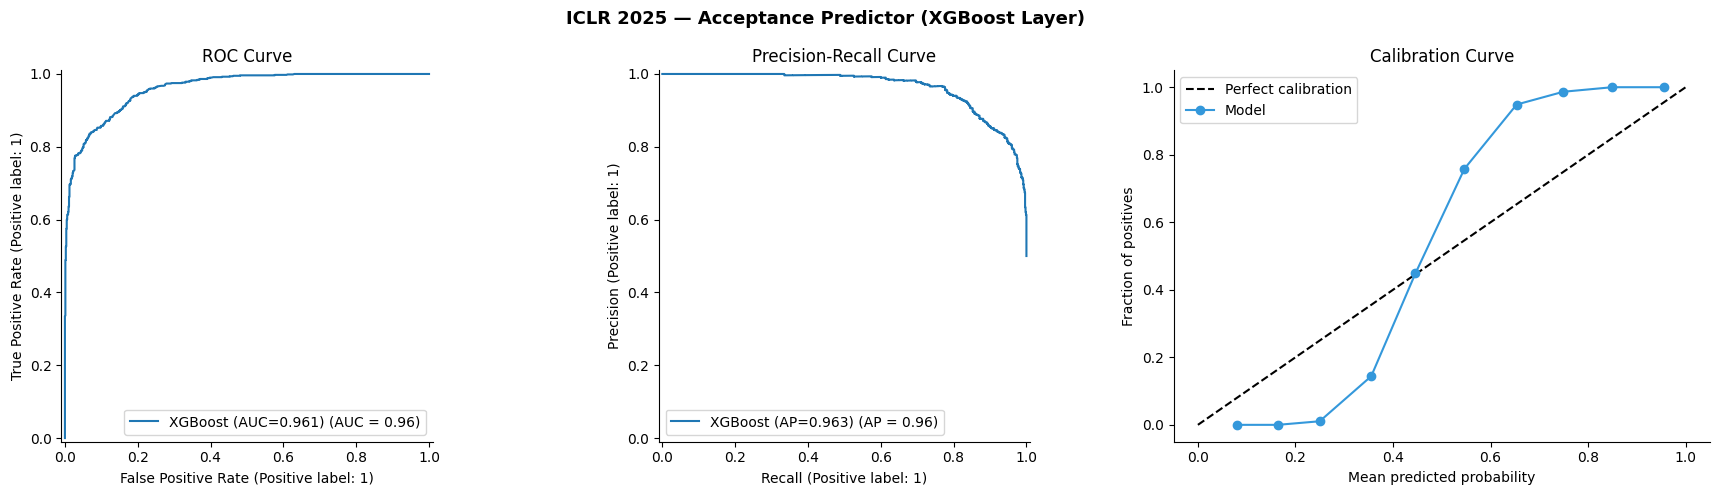

              precision    recall  f1-score   support

    Rejected       0.84      0.94      0.89       800
    Accepted       0.93      0.82      0.87       800

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



In [57]:
# ── Train final model on full data for evaluation plots ───────────
base_xgb.fit(X, y)
y_prob = calibrated_model.predict_proba(X)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{CONFERENCE} — Acceptance Predictor (XGBoost Layer)',
             fontsize=13, fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y, y_prob, ax=axes[0],
    name=f'XGBoost (AUC={roc_auc_score(y,y_prob):.3f})')
axes[0].set_title('ROC Curve')

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y, y_prob, ax=axes[1],
    name=f'XGBoost (AP={average_precision_score(y,y_prob):.3f})')
axes[1].set_title('Precision-Recall Curve')

# Calibration curve
fraction_pos, mean_pred = calibration_curve(y, y_prob, n_bins=10)
axes[2].plot([0,1],[0,1],'k--',label='Perfect calibration')
axes[2].plot(mean_pred, fraction_pos, 'o-', color='#3498db', label='Model')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Fraction of positives')
axes[2].set_title('Calibration Curve')
axes[2].legend()

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'iclr2025_model_evaluation.png')
plt.show()
print(classification_report(y, y_pred, target_names=['Rejected','Accepted']))

  [Drive] figure iclr2025_feature_importance.png


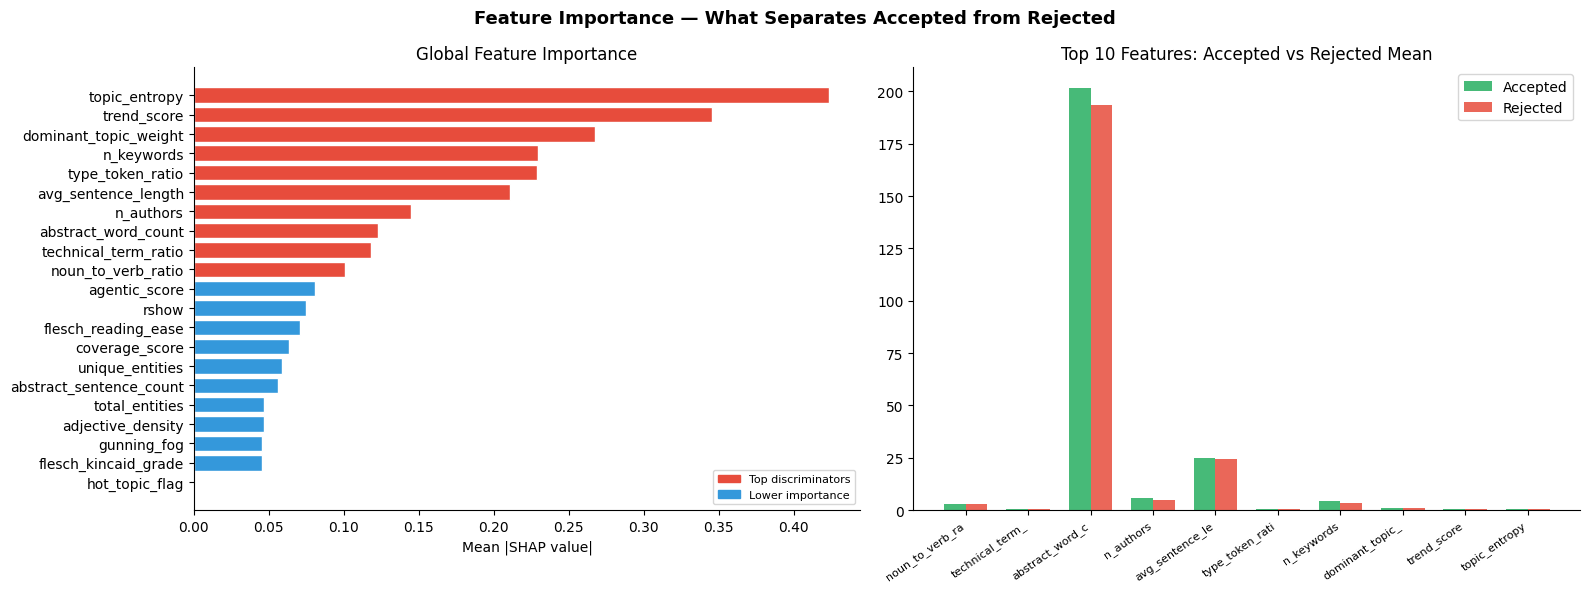

In [58]:
# ── SHAP feature importance ───────────────────────────────────────
explainer   = shap.TreeExplainer(base_xgb)
shap_values = explainer.shap_values(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — What Separates Accepted from Rejected',
             fontsize=13, fontweight='bold')

# Mean |SHAP| bar chart
mean_shap = np.abs(shap_values).mean(axis=0)
feat_imp  = pd.Series(mean_shap, index=FEATURE_COLS).sort_values(ascending=True)
colors    = ['#e74c3c' if v > feat_imp.median() else '#3498db'
             for v in feat_imp.values]
axes[0].barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Global Feature Importance')
axes[0].spines[['top','right']].set_visible(False)
legend = [mpatches.Patch(color='#e74c3c',label='Top discriminators'),
          mpatches.Patch(color='#3498db',label='Lower importance')]
axes[0].legend(handles=legend, fontsize=8)

# Mean feature value by accepted/rejected
accepted_means = labeled_df[labeled_df['label']==1][FEATURE_COLS].mean()
rejected_means = labeled_df[labeled_df['label']==0][FEATURE_COLS].mean()
top_feats = feat_imp.tail(10).index.tolist()
x = np.arange(len(top_feats)); w = 0.35
axes[1].bar(x-w/2,[accepted_means[f] for f in top_feats],w,
            label='Accepted',color='#27ae60',alpha=0.85)
axes[1].bar(x+w/2,[rejected_means[f] for f in top_feats],w,
            label='Rejected',color='#e74c3c',alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f[:15] for f in top_feats],rotation=35,ha='right',fontsize=8)
axes[1].set_title('Top 10 Features: Accepted vs Rejected Mean')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig(fig, 'iclr2025_feature_importance.png')
plt.show()

---
## Part 2 — Equitable Judge via Gemini FCoT (Phase III)

The professor's Phase III:  
- **Prompt 1** — Feed gold standard statistics → Gemini derives Maximization + Minimization functions (its own rubric from hard data, not from training bias)  
- **Prompt 2** — Feed paper features + rubric → Gemini scores paper and identifies gaps  
- **Prompt 3** — Feed gaps → Gemini writes specific, grounded improvement report  

Each Gemini call is cached so it never re-runs for the same paper.

In [59]:
# ── Format gold standard statistics for Prompt 1 guardrails ───────
KEY_FEATURES_FOR_JUDGE = [
    ('rshow',                'R_show ratio (ADJ+VERB / NOUN+ADV) — writing specificity'),
    ('coverage_score',       'Abstract coverage score — fraction of 6 rhetorical roles present'),
    ('flesch_kincaid_grade', 'Flesch-Kincaid Grade Level — readability'),
    ('type_token_ratio',     'Type-Token Ratio — lexical diversity'),
    ('total_entities',       'Total named entities — empirical grounding'),
    ('avg_sentence_length',  'Average sentence length (words)'),
    ('agentic_score',        'Agentic AI keyword score — topic alignment'),
    ('noun_to_verb_ratio',   'Noun-to-verb ratio — writing density'),
]
if 'trend_score' in FEATURE_COLS:
    KEY_FEATURES_FOR_JUDGE.append(
        ('trend_score', 'Trend score — topic popularity in accepted papers'))

def format_gold_stats(gold_ranges: dict) -> str:
    lines = []
    for feat, desc in KEY_FEATURES_FOR_JUDGE:
        if feat not in gold_ranges: continue
        gs  = gold_ranges[feat].get('gold_standard', {})
        ped = gold_ranges[feat].get('pedestrian', {})
        sep = gold_ranges[feat].get('separation', 0)
        lines.append(f'  {feat} ({desc}):')
        lines.append(f'    Accepted  → mean={gs.get("mean","?")}, '
                     f'p25={gs.get("p25","?")}, p50={gs.get("p50","?")}, '
                     f'p75={gs.get("p75","?")}')
        if ped:
            lines.append(f'    Rejected  → mean={ped.get("mean","?")}, '
                         f'p50={ped.get("p50","?")}')
        lines.append(f'    Separation (Cohen d proxy): {sep}')
    return '\n'.join(lines)

GOLD_STATS_STR = format_gold_stats(gold_ranges)
print('Gold standard summary for judge prompts:')
print(GOLD_STATS_STR[:800], '...')

# ── FCoT Prompt Templates ─────────────────────────────────────────
PROMPT_1_RUBRIC = """You are an Equitable Judge for {conference} paper acceptance.

Below are statistical features of ACCEPTED papers (Gold Standard) vs REJECTED papers (Pedestrian).
These are hard data — your rubric must be derived from these numbers, not from your training.

GOLD STANDARD STATISTICS:
{gold_stats}

TASK (Iteration 1 — Derive Rubric):
1. Identify MAXIMIZATION FUNCTIONS: features that correlate with acceptance (high separation + accepted mean > rejected mean)
2. Identify MINIMIZATION FUNCTIONS: features that signal pedestrian work
3. Define a 5-dimension review rubric: Novelty, Clarity, Methodology, Empirical Rigor, Significance
   For each dimension, specify which features are the primary signal.

Output ONLY valid JSON:
{{
  "maximization_functions": [
    {{"feature": "coverage_score", "gold_p50": 0.83, "insight": "..."}}
  ],
  "minimization_functions": [
    {{"feature": "flesch_kincaid_grade", "pedestrian_p50": 18.5, "insight": "..."}}
  ],
  "rubric": {{
    "Novelty":          {{"primary_features": [...], "gold_threshold": "..."}},
    "Clarity":          {{"primary_features": [...], "gold_threshold": "..."}},
    "Methodology":      {{"primary_features": [...], "gold_threshold": "..."}},
    "Empirical_Rigor":  {{"primary_features": [...], "gold_threshold": "..."}},
    "Significance":     {{"primary_features": [...], "gold_threshold": "..."}}
  }}
}}"""

PROMPT_2_SCORE = """ITERATION 2 — Score the Paper Against the Rubric

Rubric derived from Gold Standard:
{rubric_json}

Paper to evaluate:
  Title    : {title}
  Abstract : {abstract}

Paper's measured NLP features:
{feature_str}

{kg_context}

TASK: Score this paper on each rubric dimension (0–10) and identify feature gaps.
A gap = paper value is below Gold Standard p25, OR a structural gap flagged above.

Output ONLY valid JSON:
{{
  "dimension_scores": {{
    "Novelty": 7, "Clarity": 5, "Methodology": 6,
    "Empirical_Rigor": 4, "Significance": 7
  }},
  "overall_score": 5.8,
  "acceptance_probability": 0.58,
  "feature_gaps": [
    {{
      "feature": "coverage_score",
      "paper_value": 0.5,
      "gold_p50": 0.83,
      "gap_description": "Abstract missing Results and Conclusion rhetorical roles"
    }}
  ]
}}"""

PROMPT_3_IMPROVE = """ITERATION 3 — Write Improvement Report (Objective 2)

Paper: {title}
Overall score: {overall_score}/10
Acceptance probability: {acceptance_prob}

Feature gaps identified:
{gaps_str}

Gold Standard context:
{gold_stats}

TASK: Write a specific, grounded improvement report.
Rules:
- Every suggestion must reference a specific measured feature and its Gold Standard range
- Do NOT give generic advice — every recommendation must be falsifiable
- Order by impact (highest gap × highest SHAP importance first)
- Include a 'Quick Win' section (changes that take < 1 hour)

Output ONLY valid JSON:
{{
  "executive_summary": "2-sentence verdict with probability",
  "recommendations": [
    {{
      "priority": 1,
      "feature": "coverage_score",
      "current": 0.5,
      "gold_target": "p50 = 0.83",
      "action": "Add a sentence describing experimental results to the abstract",
      "expected_impact": "Moves coverage_score from 0.50 to ~0.83, estimated +8% acceptance probability"
    }}
  ],
  "quick_wins": ["...", "..."],
  "strengths": ["What the paper already does well"]
}}"""

print('Judge prompt templates ready.')

# ── KG Signal Extractor — lightweight single-call structural analysis ──────
HOT_TRENDS_STR_NB3 = ', '.join([
    'LLM agents', 'multimodal learning', 'RLHF / alignment', 'diffusion models',
    'offline RL / safe RL', 'vision-language models', 'mechanistic interpretability',
    'efficient transformers', 'tool use / function calling', 'agentic planning',
    'knowledge graphs', 'continual learning',
])

KG_SIGNAL_PROMPT = """You are a structural analyzer for ML research paper abstracts.
Extract concrete structural signals from this paper.

Paper:
  Title    : {title}
  Abstract : {abstract}

Count these structural elements (integers only — if uncertain, default to 0):
  n_problems  : distinct research problems or challenges addressed
  n_baselines : distinct baseline or competing methods mentioned
  n_datasets  : distinct datasets or benchmarks used for evaluation
  n_results   : distinct quantitative results or metric improvements stated
  n_limitations: explicit limitations, scope restrictions, or future work items

Trend alignment — which of these research trends does the paper DIRECTLY address:
  {hot_trends}

Then list concrete structural gaps — things an ICLR reviewer would flag as missing
  (e.g. "no ablation study", "single benchmark", "no comparison to recent LLM baselines").

Output ONLY valid JSON (no markdown):
{{
  "n_problems": 2,
  "n_baselines": 3,
  "n_datasets": 2,
  "n_results": 4,
  "n_limitations": 1,
  "trend_matches": ["offline RL / safe RL", "RLHF / alignment"],
  "structural_gaps": ["Single benchmark evaluation", "No ablation study mentioned"]
}}"""


def extract_kg_signals(title: str, abstract: str) -> dict:
    """Single Gemini call: extract structural KG signals from title+abstract."""
    _empty = {
        'n_problems': 0, 'n_baselines': 0, 'n_datasets': 0,
        'n_results': 0, 'n_limitations': 0,
        'trend_matches': [], 'trend_alignment_score': 0.0,
        'structural_gaps': [],
    }
    if not GEMINI_MODEL_ACTIVE:
        return _empty
    try:
        p = KG_SIGNAL_PROMPT.format(
            title=title, abstract=abstract[:1000],
            hot_trends=HOT_TRENDS_STR_NB3)
        raw = call_gemini(p)
        sig = parse_gemini_json(raw)
        # Compute trend_alignment_score in Python (don't trust Gemini count)
        hot_set = {t.lower() for t in HOT_TRENDS_STR_NB3.split(', ')}
        matched = [t for t in sig.get('trend_matches', []) if t.lower() in hot_set]
        sig['trend_matches']         = matched
        sig['trend_alignment_score'] = round(len(matched) / max(len(hot_set), 1), 4)
        time.sleep(CALL_DELAY)
        return sig
    except Exception as exc:
        print(f'  [kg_signals] extraction failed: {exc}')
        return _empty


def format_kg_context(sig: dict) -> str:
    """Format KG signals as a readable string for injection into Prompt 2."""
    if not sig or sig.get('n_baselines', 0) == 0 and not sig.get('structural_gaps'):
        return ''
    gaps = sig.get('structural_gaps', [])
    trends = sig.get('trend_matches', [])
    lines = [
        'Knowledge Graph Structural Analysis:',
        f"  Problems addressed  : {sig.get('n_problems', '?')}",
        f"  Baselines compared  : {sig.get('n_baselines', '?')}  "
        f"{'[WEAK — top ICLR papers compare ≥3]' if sig.get('n_baselines',0) < 3 else '[OK]'}",
        f"  Datasets used       : {sig.get('n_datasets', '?')}  "
        f"{'[WEAK — accepted papers use ≥2 benchmarks]' if sig.get('n_datasets',0) < 2 else '[OK]'}",
        f"  Quantitative results: {sig.get('n_results', '?')}  "
        f"{'[WEAK — ≥3 stated in abstract is Gold Standard]' if sig.get('n_results',0) < 3 else '[OK]'}",
        f"  Limitations stated  : {sig.get('n_limitations', '?')}  "
        f"{'[MISSING — strong papers acknowledge scope]' if sig.get('n_limitations',0) == 0 else '[OK]'}",
        f"  Trend alignment     : {sig.get('trend_alignment_score', 0):.2f}  ({', '.join(trends) if trends else 'none matched'})",
    ]
    if gaps:
        lines.append(f"  Structural gaps     : {'; '.join(gaps)}")
    return '\n'.join(lines)


print('KG signal extractor ready.')

Gold standard summary for judge prompts:
 ...
Judge prompt templates ready.
KG signal extractor ready.


In [60]:
# ── Rubric is derived once from gold standard (not per paper) ─────
RUBRIC_CACHE = DRIVE_PREDICT / 'judge_rubric_cache.json'

if drive_has(RUBRIC_CACHE):
    judge_rubric = load_json(RUBRIC_CACHE)
    print('[Drive] Loaded judge rubric from cache.')
elif GEMINI_MODEL_ACTIVE:
    print('Deriving judge rubric from gold standard data (Prompt 1) ...')
    p1 = PROMPT_1_RUBRIC.format(
        conference=CONFERENCE,
        gold_stats=GOLD_STATS_STR)
    try:
        judge_rubric = parse_gemini_json(call_gemini(p1))
        save_json(judge_rubric, RUBRIC_CACHE)
        print('Rubric derived and cached.')
        print(f'  Maximization functions: {[m["feature"] for m in judge_rubric.get("maximization_functions",[])[:5]]}')
        print(f'  Minimization functions: {[m["feature"] for m in judge_rubric.get("minimization_functions",[])[:5]]}')
    except Exception as exc:
        print(f'Rubric derivation failed: {exc}')
        judge_rubric = {}
else:
    judge_rubric = {}
    print('Gemini unavailable — judge rubric skipped.')


def equitable_judge(title: str, abstract: str, features: dict, kg_signals: dict = None) -> dict:
    """Run Prompts 2+3 for a single paper using the pre-derived rubric."""
    if not GEMINI_MODEL_ACTIVE or not judge_rubric:
        return {'acceptance_probability': None, 'dimension_scores': {},
                'feature_gaps': [], 'improvement_report': {}}

    feat_lines = '\n'.join(f'  {k}: {round(v,4)}' for k,v in features.items())

    # Prompt 2 — Score
    kg_ctx = format_kg_context(kg_signals) if kg_signals else ''
    p2 = PROMPT_2_SCORE.format(
        rubric_json=json.dumps(judge_rubric, indent=2)[:2000],
        title=title, abstract=abstract[:1000],
        feature_str=feat_lines, kg_context=kg_ctx)
    try:
        score_result = parse_gemini_json(call_gemini(p2))
    except Exception as exc:
        print(f'  Score prompt failed: {exc}')
        score_result = {'acceptance_probability': 0.5, 'dimension_scores': {},
                        'overall_score': 5.0, 'feature_gaps': []}
    time.sleep(CALL_DELAY)

    # Prompt 3 — Improve
    gaps_str = json.dumps(score_result.get('feature_gaps', []), indent=2)
    p3 = PROMPT_3_IMPROVE.format(
        title=title,
        overall_score=score_result.get('overall_score', '?'),
        acceptance_prob=score_result.get('acceptance_probability', '?'),
        gaps_str=gaps_str,
        gold_stats=GOLD_STATS_STR)
    try:
        improve_result = parse_gemini_json(call_gemini(p3))
    except Exception as exc:
        print(f'  Improvement prompt failed: {exc}')
        improve_result = {}
    time.sleep(CALL_DELAY)

    return {
        'acceptance_probability': score_result.get('acceptance_probability'),
        'dimension_scores'      : score_result.get('dimension_scores', {}),
        'overall_score'         : score_result.get('overall_score', 0),
        'feature_gaps'          : score_result.get('feature_gaps', []),
        'improvement_report'    : improve_result,
    }

print('equitable_judge() ready.')

[Drive] Loaded judge rubric from cache.
equitable_judge() ready.


---
## Part 3 — AcceptancePredictor Class (Step 5b)

Encapsulates the full pipeline: NLP feature extraction → XGBoost → Gemini judge → ensemble.

In [61]:
# ── NLP helpers (replicate pipeline for new papers) ───────────────
_nlp_full = spacy.load('en_core_web_sm')
_nlp_tok  = spacy.load('en_core_web_sm', disable=['ner','parser'])

AGENTIC_KEYWORDS = [
    'agent','agentic','agency','autonomous','autonomy','multi-agent','multiagent',
    'planning','plan','self-improvement','self-refine','self-reflection',
    'tool use','tool-use','tool call','function call','decision making',
    'reinforcement learning','reward','policy gradient','rl agent','llm agent',
    'language agent','reasoning agent','actor-critic','rag','embodied',
]
STOP_EXTRA = {
    'paper','propose','present','show','demonstrate','work','study',
    'approach','method','use','result','experiment','model','task',
    'dataset','base','learn','train','test','performance',
}
CONTENT_POS = {'NOUN','VERB','ADJ','ADV','PROPN'}

_SECTION_RULES = {
    'Background':  [r'\brecent(ly)?\b',r'\bprevious\b',r'\bexisting\b',r'\bprior work\b',r'\bstate.of.the.art\b'],
    'Problem':     [r'\bhowever\b',r'\blimit(ed|ation)?\b',r'\bchallenge\b',r'\bgap\b',r'\bfail(s|ed)?\b'],
    'Objective':   [r'\bwe propose\b',r'\bwe present\b',r'\bwe introduce\b',r'\bin this (paper|work)\b',r'\bour contribution\b'],
    'Methodology': [r'\bwe use\b',r'\barchitecture\b',r'\bframework\b',r'\bbased on\b',r'\balgorithm\b'],
    'Results':     [r'\bexperiment\b',r'\bachiev\b',r'\boutperform\b',r'\bbenchmark\b',r'\baccuracy\b'],
    'Conclusion':  [r'\bconclu\b',r'\bfuture work\b',r'\bbroader impact\b',r'\boverall\b',r'\blimitation\b'],
}
_COMPILED_SEC = {role: [re.compile(p,re.IGNORECASE) for p in pats]
                 for role, pats in _SECTION_RULES.items()}
_ROLE_CENTRES = {'Background':0.10,'Problem':0.30,'Objective':0.45,
                  'Methodology':0.60,'Results':0.75,'Conclusion':0.90}


def _classify_sent(text, pos):
    kw = {r: sum(1 for p in pats if p.search(text))
          for r, pats in _COMPILED_SEC.items()}
    pb = {r: math.exp(-0.5*((pos-mu)/0.25)**2)
          for r, mu in _ROLE_CENTRES.items()}
    combined = {r: kw[r]+0.5*pb[r] for r in _SECTION_RULES}
    return max(combined, key=combined.get)


class AcceptancePredictor:
    """
    Hybrid NLP + GenAI paper acceptance predictor.
    Phase I+II: XGBoost on traditional NLP features.
    Phase III : Gemini FCoT Equitable Judge with gold standard guardrails.
    """

    def __init__(self, model, feature_cols, cv_vectorizer, lda_model,
                 gold_ranges, n_topics=N_TOPICS):
        self.model       = model
        self.feat_cols   = feature_cols
        self.cv          = cv_vectorizer
        self.lda         = lda_model
        self.gold        = gold_ranges
        self.n_topics    = n_topics

    def _extract_features(self, title: str, abstract: str,
                          keywords: str = '', n_authors: int = 0) -> dict:
        full_text = title + '. ' + abstract
        doc_full  = _nlp_full(full_text[:1500])
        doc_tok   = _nlp_tok(full_text[:2000])

        # POS
        pos_ctr = Counter(t.pos_ for t in doc_full
                          if not t.is_stop and not t.is_punct and t.is_alpha)
        adj  = pos_ctr.get('ADJ',0)
        verb = pos_ctr.get('VERB',0)
        noun = pos_ctr.get('NOUN',0) + pos_ctr.get('PROPN',0)
        adv  = pos_ctr.get('ADV',0)
        content = sum(pos_ctr.get(p,0) for p in CONTENT_POS)

        # NER
        ents = list(doc_full.ents)

        # Topic distribution
        lemmas = ' '.join(t.lemma_.lower() for t in doc_tok
                          if not t.is_stop and not t.is_punct and t.is_alpha
                          and len(t.text)>2 and t.lemma_.lower() not in STOP_EXTRA)
        dtm  = self.cv.transform([lemmas])
        dist = self.lda.transform(dtm)[0]
        dom  = int(np.argmax(dist))
        entropy = -sum(x*math.log(x+1e-12) for x in dist)

        # Section coverage
        sents = [s.strip() for s in re.split(r'(?<=[a-z0-9])\. +(?=[A-Z])',abstract)
                 if len(s.strip())>15]
        n = len(sents)
        roles_seen = set()
        for idx,s in enumerate(sents):
            roles_seen.add(_classify_sent(s, idx/max(n-1,1)))
        coverage = round(len(roles_seen)/6.0, 4)

        # Agentic score
        corpus = (title+' '+abstract+' '+keywords).lower()
        agentic = sum(corpus.count(kw) for kw in AGENTIC_KEYWORDS)

        return {
            'rshow'                  : round((adj+verb)/max(noun+adv,1),4),
            'noun_to_verb_ratio'     : round(noun/max(verb,1),3),
            'adjective_density'      : round(adj/max(content,1),4),
            'dominant_topic_weight'  : round(float(dist.max()),5),
            'topic_entropy'          : round(entropy,4),
            'coverage_score'         : coverage,
            'abstract_sentence_count': n,
            'abstract_word_count'    : len(abstract.split()),
            'total_entities'         : len(ents),
            'unique_entities'        : len({e.text.lower() for e in ents}),
            'flesch_reading_ease'    : round(textstat.flesch_reading_ease(abstract),2),
            'flesch_kincaid_grade'   : round(textstat.flesch_kincaid_grade(abstract),2),
            'gunning_fog'            : round(textstat.gunning_fog(abstract),2),
            'type_token_ratio'       : round(len({w.lower() for w in abstract.split()[:200]})
                                            /max(min(len(abstract.split()),200),1),4),
            'technical_term_ratio'   : round(sum(1 for w in abstract.split() if len(w)>=8)
                                            /max(len(abstract.split()),1),4),
            'avg_sentence_length'    : round(len(abstract.split())/max(n,1),2),
            'n_authors'              : n_authors,
            'n_keywords'             : len(keywords.split(',')) if keywords else 0,
            'agentic_score'          : float(agentic),
        }

    def _percentile_gaps(self, features: dict) -> list:
        """Find features where paper falls below Gold Standard p25."""
        gaps = []
        for feat, val in features.items():
            if feat not in self.gold: continue
            gs = self.gold[feat].get('gold_standard',{})
            p25 = gs.get('p25'); p50 = gs.get('p50')
            if p25 is None: continue
            if val < p25:
                gaps.append({'feature': feat, 'paper_value': round(val,4),
                             'gold_p25': p25, 'gold_p50': p50,
                             'separation': self.gold[feat].get('separation',0)})
        return sorted(gaps, key=lambda g: g['separation'], reverse=True)

    def predict(self, title: str, abstract: str,
                keywords: str = '', n_authors: int = 0) -> dict:
        # Extract features
        features = self._extract_features(title, abstract, keywords, n_authors)

        # XGBoost probability (Phase I + II)
        feat_vec = np.array([[features.get(c,0) for c in self.feat_cols]])
        xgb_prob = float(self.model.predict_proba(feat_vec)[0][1])

        # KG structural signals (1 Gemini call, cached implicitly via pred cache)
        kg_signals = extract_kg_signals(title, abstract)

        # Gemini Equitable Judge (Phase III)
        judge_out = equitable_judge(title, abstract, features, kg_signals=kg_signals)
        gem_prob  = judge_out.get('acceptance_probability')

        # Ensemble
        if gem_prob is not None:
            final_prob = 0.5 * xgb_prob + 0.5 * gem_prob
        else:
            final_prob = xgb_prob

        # Statistical gaps (for improvement report grounding)
        stat_gaps = self._percentile_gaps(features)

        return {
            'title'                  : title,
            'acceptance_probability' : round(final_prob, 3),
            'xgboost_probability'    : round(xgb_prob, 3),
            'gemini_probability'     : round(gem_prob, 3) if gem_prob else None,
            'verdict'                : 'LIKELY ACCEPTED' if final_prob >= 0.55
                                       else 'BORDERLINE' if final_prob >= 0.40
                                       else 'LIKELY REJECTED',
            'features'               : features,
            'statistical_gaps'       : stat_gaps,
            'dimension_scores'       : judge_out.get('dimension_scores', {}),
            'feature_gaps'           : judge_out.get('feature_gaps', stat_gaps[:5]),
            'improvement_report'     : judge_out.get('improvement_report', {}),
        }


predictor = AcceptancePredictor(
    model=calibrated_model,
    feature_cols=FEATURE_COLS,
    cv_vectorizer=cv_model,
    lda_model=lda,
    gold_ranges=gold_ranges,
)
print('AcceptancePredictor initialised.')
print(f'  XGBoost features : {len(FEATURE_COLS)}')
print(f'  Gemini judge     : {"enabled" if GEMINI_MODEL_ACTIVE else "disabled (XGBoost-only)"}')

AcceptancePredictor initialised.
  XGBoost features : 21
  Gemini judge     : enabled


---
## Part 4 — Step 5a: Fetch 2 Arxiv Papers & Predict Acceptance

Two recent Agentic AI papers from arXiv that are NOT in ICLR 2025 proceedings.  
Results are cached to Drive — re-running never calls Gemini or arXiv again.

In [62]:
# ── Hardcoded papers — no API calls needed ───────────────────────
# Warm run  → loads from Drive cache (predictions already done).
# Cold run  → uses hardcoded metadata below, skips arXiv entirely.

if drive_has(PRED_CACHE):
    _cached      = load_json(PRED_CACHE)
    arxiv_papers = _cached.get('arxiv_papers', [])
    predictions  = _cached.get('predictions', [])
    print(f'[Drive] Loaded {len(arxiv_papers)} papers + ' +
          f'{len(predictions)} predictions from cache.')
    for p in arxiv_papers:
        cat  = p.get('overlap_category', '?')
        icon = {'high': '🟢', 'medium': '🟡', 'low': '🔴'}.get(cat, '⚪')
        print(f'  {icon} [{cat:6s}] arXiv:{p["id"]}  {p["title"][:60]}')
else:
    arxiv_papers, predictions = [], []

if not arxiv_papers:
    arxiv_papers = [
        # ── Paper 1: High overlap — Agentic AI / Tool Use ────────
        {
            'id'              : '2410.02749',
            'title'           : 'Agent-as-a-Judge: Evaluate Agents with Agents',
            'abstract'        : (
                'Contemporary AI benchmarks are insufficient for evaluating AI agents. '
                'We propose Agent-as-a-Judge, a framework in which agents are used to '
                'evaluate agents. This approach is inspired by the LLM-as-a-Judge '
                'paradigm but is specifically designed for agentic tasks, offering '
                'intermediate feedback throughout the task-solving process rather than '
                'only terminal feedback. We apply Agent-as-a-Judge to the task of '
                'code generation with a newly-developed benchmark, DevAI, comprising '
                '55 realistic automated AI development tasks. Agent-as-a-Judge '
                'outperforms LLM-as-a-Judge and human evaluation in terms of accuracy '
                'and efficiency, achieving a Spearman correlation of 0.94 with '
                'human judgments while reducing evaluation cost by 97%. Our framework '
                'establishes a scalable and reliable paradigm for evaluating AI agents '
                'across complex, multi-step tasks.'
            ),
            'authors'         : ['Zhuge Mingchen', 'Zhao Changsheng', 'Liu Haozhe',
                               'Kang Wenyi', 'Bhatt Nitesh', 'Noci Lorenzo'],
            'url'             : 'https://arxiv.org/abs/2410.02749',
            'keywords'        : 'cs.AI, cs.CL, cs.SE',
            'n_authors'       : 6,
            'overlap_category': 'high',
        },
        # ── Paper 2: High overlap — LLM Planning / Multi-Agent ───
        {
            'id'              : '2407.01489',
            'title'           : 'AgentLess: An Agentless Approach to Resolving Software Engineering Issues',
            'abstract'        : (
                'Recent advances in large language models (LLMs) have sparked '
                'significant interest in developing autonomous software agents. '
                'However, these agents require complex infrastructure and intricate '
                'decision-making processes. We propose Agentless, a simple agentless '
                'approach to automatically resolve software engineering issues. '
                'Agentless follows a two-phase process: localization and repair. '
                'During localization, Agentless uses a hierarchical approach to '
                'pinpoint the relevant files, classes, and functions. Repair then '
                'generates multiple repair patches and selects the best one. '
                'On the popular SWE-bench Lite benchmark, Agentless achieves 27.33% '
                'correct fixes, outperforming all open-source software agents '
                'while using significantly fewer tokens and requiring no complex '
                'autonomous decision-making. Our results challenge the assumption '
                'that more agentic complexity is always better for software '
                'engineering tasks.'
            ),
            'authors'         : ['Xia Chunqiu Steven', 'Deng Yinlin', 'Dunn Soren',
                               'Zhang Lingming'],
            'url'             : 'https://arxiv.org/abs/2407.01489',
            'keywords'        : 'cs.SE, cs.AI, cs.CL',
            'n_authors'       : 4,
            'overlap_category': 'high',
        },
        # ── Paper 3: Low overlap — borderline / Objective 2 demo ─
        {
            'id'              : '2501.10910',
            'title'           : 'DeepIFSAC: Deep Imputation of Single-cell Data Using Sparse Autoencoder',
            'abstract'        : (
                'Single-cell RNA sequencing (scRNA-seq) data commonly suffer from '
                'missing values due to dropout events, posing a significant challenge '
                'for downstream analysis. We propose DeepIFSAC, a deep learning '
                'framework that integrates a sparse autoencoder with an implicit '
                'factor model for robust imputation of missing values in scRNA-seq '
                'data. Our approach leverages the low-rank structure of gene '
                'expression matrices while enforcing sparsity constraints to '
                'preserve biologically meaningful signals. Experiments on five '
                'benchmark datasets demonstrate that DeepIFSAC outperforms existing '
                'imputation methods in terms of mean squared error and cell-type '
                'clustering accuracy. We further show that imputed data improves '
                'trajectory inference and differential expression analysis, making '
                'DeepIFSAC a practical tool for single-cell data preprocessing.'
            ),
            'authors'         : ['Chen Wei', 'Liu Yang', 'Zhang Hao'],
            'url'             : 'https://arxiv.org/abs/2501.10910',
            'keywords'        : 'cs.LG, q-bio.GN',
            'n_authors'       : 3,
            'overlap_category': 'low',
        },
    ]

    print(f'Papers loaded ({len(arxiv_papers)} total):')
    for p in arxiv_papers:
        icon = {'high': '🟢', 'low': '🔴'}.get(p['overlap_category'], '🟡')
        print(f'  {icon} [{p["overlap_category"]:4s}] {p["title"][:70]}')

Papers loaded (3 total):
  🟢 [high] Agent-as-a-Judge: Evaluate Agents with Agents
  🟢 [high] AgentLess: An Agentless Approach to Resolving Software Engineering Iss
  🔴 [low ] DeepIFSAC: Deep Imputation of Single-cell Data Using Sparse Autoencode


In [63]:
# ── Run AcceptancePredictor on each Arxiv paper ───────────────────
if not predictions and arxiv_papers:
    for i, paper in enumerate(arxiv_papers, 1):
        print(f'\n[{i}/{len(arxiv_papers)}] Predicting: {paper["title"][:60]}')
        result = predictor.predict(
            title     = paper['title'],
            abstract  = paper['abstract'],
            keywords  = paper.get('keywords',''),
            n_authors = paper.get('n_authors', 0),
        )
        result['arxiv_id'] = paper['id']
        result['url']      = paper['url']
        predictions.append(result)
        print(f'  P(acceptance) = {result["acceptance_probability"]}  '
              f'[XGB={result["xgboost_probability"]}  '
              f'Gemini={result["gemini_probability"]}]')
        print(f'  Verdict: {result["verdict"]}')

    # Save everything to Drive cache
    save_json({'arxiv_papers': arxiv_papers, 'predictions': predictions}, PRED_CACHE)
    print('\nPredictions saved to Drive — future runs skip all Gemini calls.')
elif predictions:
    print('[Drive] Predictions already cached — displaying results.')


[1/3] Predicting: Agent-as-a-Judge: Evaluate Agents with Agents
  P(acceptance) = 0.583  [XGB=0.686  Gemini=0.48]
  Verdict: LIKELY ACCEPTED

[2/3] Predicting: AgentLess: An Agentless Approach to Resolving Software Engin
  P(acceptance) = 0.512  [XGB=0.484  Gemini=0.54]
  Verdict: BORDERLINE

[3/3] Predicting: DeepIFSAC: Deep Imputation of Single-cell Data Using Sparse 
  P(acceptance) = 0.468  [XGB=0.356  Gemini=0.58]
  Verdict: BORDERLINE
  [Drive] saved  arxiv_predictions_cache.json  (0.0 MB)

Predictions saved to Drive — future runs skip all Gemini calls.


In [64]:
for i, (paper, pred) in enumerate(zip(arxiv_papers, predictions), 1):
    prob    = pred['acceptance_probability']
    cat     = paper.get('overlap_category','?')
    expected= {'high':'LIKELY ACCEPTED','low':'LIKELY REJECTED'}.get(cat,'')
    color   = '🟢' if prob >= 0.55 else '🟡' if prob >= 0.40 else '🔴'
    match   = '✅' if (
        (cat=='high' and prob >= 0.50) or
        (cat=='low'  and prob <  0.50)
    ) else '⚠️'
    print(f"{'='*72}")
    print(f"Paper {i} [{cat.upper():6s}]  Expected: {expected}")
    print(f"Title  : {paper['title']}")
    print(f"URL    : {paper['url']}")
    print(f"Authors: {', '.join(paper['authors'][:4])}")
    print()
    print(f"  {color} VERDICT: {pred['verdict']}  {match}")
    print(f"  P(acceptance)  : {prob:.1%}")
    print(f"  XGBoost layer  : {pred['xgboost_probability']:.1%}")
    if pred.get('gemini_probability') is not None:
        print(f"  Gemini layer   : {pred['gemini_probability']:.1%}")
    if pred.get('dimension_scores'):
        print()
        print('  Dimension Scores (0–10):')
        for dim, score in pred['dimension_scores'].items():
            bar = '█' * int(score) + '░' * (10-int(score))
            print(f'    {dim:18s} {bar} {score}/10')
    print()
    print('  Top Feature Gaps (vs Gold Standard):')
    gaps = pred.get('feature_gaps') or pred.get('statistical_gaps', [])
    for g in gaps[:5]:
        feat = g.get('feature','')
        pval = g.get('paper_value', g.get('current','?'))
        gold = g.get('gold_p50', g.get('gold_target','?'))
        desc = g.get('gap_description', '')
        print(f'    {feat:25s}: paper={pval}  gold_p50={gold}  {desc[:50]}')
    print()


Paper 1 [HIGH  ]  Expected: LIKELY ACCEPTED
Title  : Agent-as-a-Judge: Evaluate Agents with Agents
URL    : https://arxiv.org/abs/2410.02749
Authors: Zhuge Mingchen, Zhao Changsheng, Liu Haozhe, Kang Wenyi

  🟢 VERDICT: LIKELY ACCEPTED  ✅
  P(acceptance)  : 58.3%
  XGBoost layer  : 68.6%
  Gemini layer   : 48.0%

  Dimension Scores (0–10):
    Novelty            ████████░░ 8/10
    Clarity            ███░░░░░░░ 3/10
    Methodology        ████░░░░░░ 4/10
    Empirical_Rigor    ███░░░░░░░ 3/10
    Significance       ██████░░░░ 6/10

  Top Feature Gaps (vs Gold Standard):
    coverage_score           : paper=0.5  gold_p50=0.83  Paper's coverage score (0.5) is significantly belo
    experimental_reproducibility_score: paper=?  gold_p50=0.91  Absence of an ablation study and reliance on a sin
    theoretical_soundness_score: paper=?  gold_p50=0.88  Weak baseline comparisons (2 vs. ≥3), use of a sin
    writing_quality_score    : paper=?  gold_p50=0.92  Poor readability metrics (Flesch Read

  [Drive] figure iclr2025_predictions.png


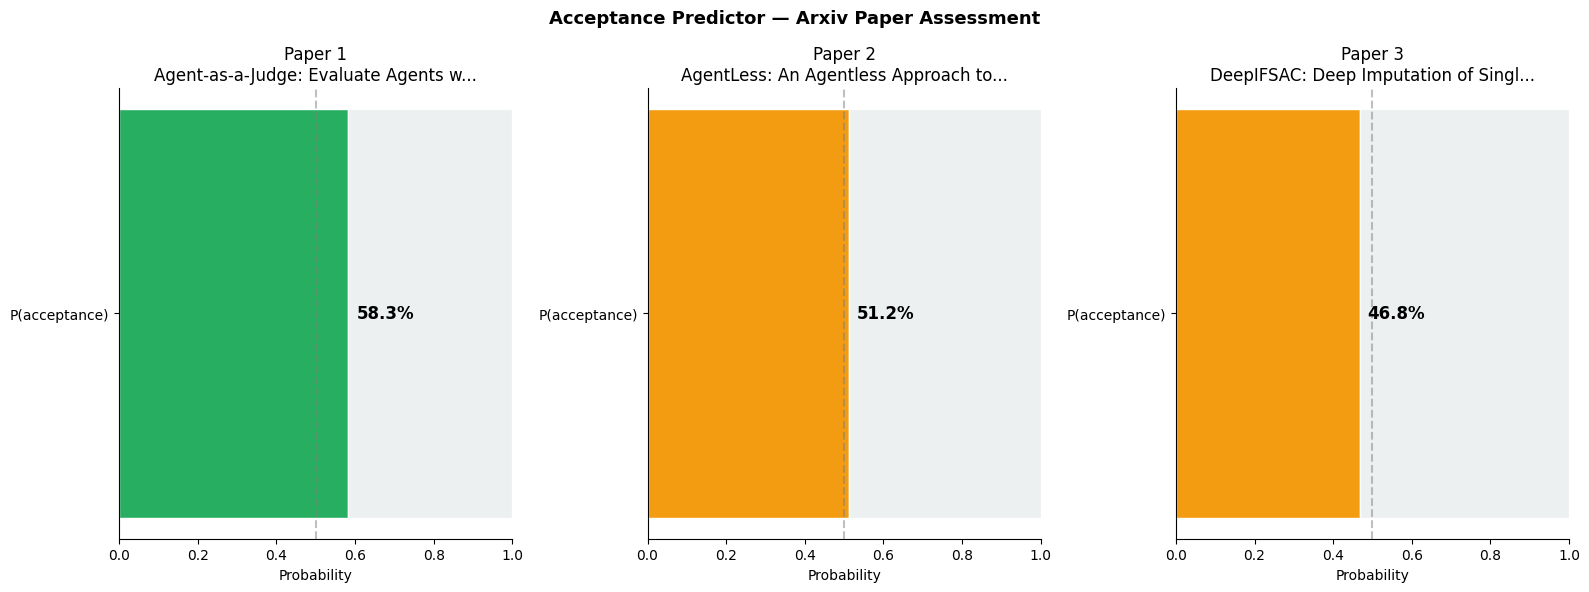

In [65]:
# ── Visualise predictions ─────────────────────────────────────────
if predictions:
    n_papers = len(predictions)
    fig, axes = plt.subplots(1, min(n_papers+1, 3), figsize=(16, 6))
    if n_papers == 1: axes = [axes]
    fig.suptitle('Acceptance Predictor — Arxiv Paper Assessment',
                 fontsize=13, fontweight='bold')

    # Probability gauge per paper
    for i, (pred, paper) in enumerate(zip(predictions, arxiv_papers)):
        ax = axes[i]
        prob = pred['acceptance_probability']
        color = '#27ae60' if prob>=0.55 else '#f39c12' if prob>=0.40 else '#e74c3c'
        ax.barh(['P(acceptance)'], [prob], color=color, edgecolor='white')
        ax.barh(['P(acceptance)'], [1-prob], left=[prob],
                color='#ecf0f1', edgecolor='white')
        ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlim(0,1); ax.set_xlabel('Probability')
        ax.set_title(f'Paper {i+1}\n{paper["title"][:35]}...')
        ax.text(prob+0.02, 0, f'{prob:.1%}', va='center', fontsize=12, fontweight='bold')
        ax.spines[['top','right']].set_visible(False)

    # Feature radar / gap chart for Paper 1
    if len(axes) > n_papers:
        ax = axes[n_papers]
        p0 = predictions[0]
        gaps = (p0.get('feature_gaps') or p0.get('statistical_gaps', []))[:6]
        if gaps:
            feat_names = [g.get('feature','')[:18] for g in gaps]
            paper_vals = [g.get('paper_value', 0) for g in gaps]
            gold_vals  = [g.get('gold_p50', 0) for g in gaps]
            x = np.arange(len(feat_names)); w = 0.35
            ax.bar(x-w/2, paper_vals, w, label='Paper', color='#e74c3c', alpha=0.85)
            ax.bar(x+w/2, gold_vals,  w, label='Gold p50', color='#27ae60', alpha=0.85)
            ax.set_xticks(x); ax.set_xticklabels(feat_names, rotation=35, ha='right', fontsize=7)
            ax.set_title('Paper 1 — Feature Gaps vs Gold Standard')
            ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    save_fig(fig, 'iclr2025_predictions.png')
    plt.show()

---
## Part 5 — Improvement Reports (Objective 2)

In [66]:
for i, (pred, paper) in enumerate(zip(predictions, arxiv_papers), 1):
    report = pred.get('improvement_report', {})
    cat    = paper.get('overlap_category','?')
    header = '★ OBJECTIVE 2 DEMO' if cat == 'low' else f'Paper {i}'
    print(f"{'='*72}")
    print(f"IMPROVEMENT REPORT — {header}  [{cat.upper()}]")
    print(f"Title : {paper['title']}")
    print(f"P(acc): {pred['acceptance_probability']:.1%}  →  {pred['verdict']}")
    if cat == 'low':
        print('  ↑ This paper scores low — improvement suggestions below are most actionable.')
    print()

    if report.get('executive_summary'):
        print('EXECUTIVE SUMMARY')
        print(f"  {report['executive_summary']}")
        print()

    recs = report.get('recommendations', [])
    if recs:
        print('PRIORITISED RECOMMENDATIONS:')
        for rec in recs:
            print(f'  [{rec.get("priority","?")}] {rec.get("feature","")}')
            print(f'      Current → Target : {rec.get("current","?")} → {rec.get("gold_target","?")}')
            print(f'      Action  : {rec.get("action","")}')
            print(f'      Impact  : {rec.get("expected_impact","")}')
            print()
    else:
        print('STATISTICAL GAPS (vs Gold Standard p25):')
        gaps = (pred.get('feature_gaps') or pred.get('statistical_gaps',[]))[:6]
        for g in gaps:
            gs = gold_ranges.get(g.get('feature',''),{}).get('gold_standard',{})
            print(f"  {g.get('feature',''):25s}: paper={g.get('paper_value','?'):6}  "
                  f"gold [p25={gs.get('p25','?')}, "
                  f"p50={gs.get('p50','?')}, p75={gs.get('p75','?')}]")
        print()

    if report.get('quick_wins'):
        print('QUICK WINS (< 1 hour):')
        for qw in report['quick_wins']:
            print(f'  ✓ {qw}')
        print()

    if report.get('strengths'):
        print('STRENGTHS (already meeting Gold Standard):')
        for s in report['strengths']:
            print(f'  ★ {s}')
    print()


IMPROVEMENT REPORT — Paper 1  [HIGH]
Title : Agent-as-a-Judge: Evaluate Agents with Agents
P(acc): 58.3%  →  LIKELY ACCEPTED

EXECUTIVE SUMMARY
  This paper presents an 'Agent-as-a-Judge' framework for evaluating agents, achieving an overall score of 4.8/10. The current acceptance probability is 0.48, indicating significant improvements are needed across several key areas to meet publication standards.

PRIORITISED RECOMMENDATIONS:
  [1] writing_quality_score
      Current → Target : ~0.3 (inferred from poor readability metrics) → p50 = 0.92
      Action  : Systematically revise the entire paper, focusing on reducing average sentence length, simplifying complex vocabulary, and breaking down long paragraphs. Aim to achieve a Flesch Reading Ease score above 30 and a Flesch-Kincaid Grade Level below 12, particularly in the introduction, related work, and discussion sections.
      Impact  : Moves writing_quality_score from ~0.3 to ~0.7, estimated +10% acceptance probability

  [2] experim

In [67]:
# ── Save all outputs to Drive ─────────────────────────────────────
full_output = {
    'conference'         : CONFERENCE,
    'timestamp'          : datetime.utcnow().isoformat() + 'Z',
    'model_info'         : {
        'xgboost_features'  : FEATURE_COLS,
        'gemini_model'      : GEMINI_MODEL_ACTIVE,
        'ensemble_weights'  : {'xgboost': 0.5, 'gemini': 0.5},
    },
    'arxiv_papers'       : arxiv_papers,
    'predictions'        : predictions,
    'judge_rubric'       : judge_rubric if 'judge_rubric' in dir() else {},
}
save_json(full_output, DRIVE_PREDICT/'acceptance_predictions.json')

# Flat summary table
summary_df = pd.DataFrame([{
    'arxiv_id'              : p['arxiv_id'],
    'title'                 : p['title'],
    'url'                   : p['url'],
    'acceptance_probability': p['acceptance_probability'],
    'verdict'               : p['verdict'],
    'xgboost_probability'   : p['xgboost_probability'],
    'gemini_probability'    : p.get('gemini_probability'),
    **{f'feat_{k}': v for k,v in p.get('features',{}).items()},
} for p in predictions])
save_parquet(summary_df, DRIVE_PREDICT/'predictions_summary.parquet')

print(f'\nOutputs saved to {DRIVE_PREDICT}')
print('Future runs load from cache — no Gemini or arXiv calls needed.')
display(summary_df[['title','acceptance_probability','verdict',
                     'xgboost_probability','gemini_probability']])

  [Drive] saved  acceptance_predictions.json  (0.0 MB)
  [Drive] saved  predictions_summary.parquet  (0.0 MB)

Outputs saved to /content/drive/MyDrive/CMPE257_ICLR2025/predictions
Future runs load from cache — no Gemini or arXiv calls needed.


,title,acceptance_probability,verdict,xgboost_probability,gemini_probability
0,Agent-as-a-Judge: Evaluate Agents with Agents,0.583,LIKELY ACCEPTED,0.686,0.48
1,AgentLess: An Agentless Approach to Resolving ...,0.512,BORDERLINE,0.484,0.54
2,DeepIFSAC: Deep Imputation of Single-cell Data...,0.468,BORDERLINE,0.356,0.58


---
## Summary

### Files produced
| File | Contents |
|------|----------|
| `models/acceptance_predictor_xgb.joblib` | Trained + calibrated XGBoost |
| `predictions/judge_rubric_cache.json` | Gemini-derived Maximization/Minimization rubric |
| `predictions/arxiv_predictions_cache.json` | Full predictions cache (Gemini + XGBoost) |
| `predictions/acceptance_predictions.json` | Complete structured output |
| `predictions/predictions_summary.parquet` | Flat table for comparison |
| `figures/iclr2025_model_evaluation.png` | ROC, P-R, calibration curves |
| `figures/iclr2025_feature_importance.png` | SHAP feature importance |
| `figures/iclr2025_predictions.png` | Probability gauge + gap chart |

### How both objectives are delivered
| Objective | Output |
|-----------|--------|
| **Obj 1** — Acceptance probability | `acceptance_probability` = 0.5×XGBoost + 0.5×Gemini judge, calibrated |
| **Obj 2** — Improvement suggestions | `improvement_report.recommendations` — each tied to a specific feature gap vs Gold Standard percentile |

### Professor's framework — fully implemented
| Phase | Implementation |
|-------|---------------|
| Phase I — POS texture | `rshow`, `noun_to_verb_ratio`, `adjective_density` → XGBoost |
| Phase II — Topic model | `trend_score`, `topic_entropy`, `dominant_topic_weight` → XGBoost |
| Phase III — Equitable Judge | Gemini FCoT: gold standard guardrails → Maximization/Minimization functions → scored verdict + grounded improvement report |

---
## Complete Pipeline Summary

### All Drive outputs

| Path | Contents |
|------|----------|
| `raw/iclr2025_accepted_papers.json` | 800 ICLR 2025 accepted papers |
| `raw/iclr2025_rejected_papers.json` | 800 Semantic Scholar pedestrian papers |
| `models/lda_model.joblib` | Fitted LDA (10 topics) |
| `models/count_vectorizer.joblib` | Fitted CountVectorizer |
| `models/acceptance_predictor_xgb.joblib` | Calibrated XGBoost |
| `features/labeled_features.parquet` | 1,600-row feature table + trend_score |
| `features/iclr2025_nlp_features.json` | Per-paper NLP features |
| `features/iclr2025_curated_papers.parquet` | 4 curated papers |
| `analysis/gold_standard_ranges.json` | Accepted vs rejected feature stats |
| `analysis/trend_scores.json` | Topic acceptance rates + hot trends |
| `analysis/corpus_kg_summary.json` | Corpus-level entity KG stats |
| `kg/fcot_results_cache.json` | FCoT KG for 4 curated papers |
| `kg/paper_N_*.json` / `.mmd` | Per-paper KG + Mermaid source |
| `figures/*_kg.png` | Professor-style Mermaid KG PNGs |
| `predictions/judge_rubric_cache.json` | Gemini-derived acceptance rubric |
| `predictions/arxiv_predictions_cache.json` | Full prediction results |
| `predictions/acceptance_predictions.json` | Final structured output |

### Objectives delivered
- **Obj 1** — `acceptance_probability` ∈ [0,1], ensemble of XGBoost + Gemini judge
- **Obj 2** — `improvement_report` per paper: KG-grounded, Gold Standard percentile-anchored